<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: center; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; letter-spacing: 1px;">TECHNO-ECONOMIC PARAMETERS DATA PROCESSING</span><br>
        <span style="font-weight: bold; font-size: 28px; font-style: italic; display: block; margin: 5px 0;">VPP POWER PLANTS</span>
        <span style="font-weight: bold; font-size: 18px;">Main Formatting Notebook</span>
    </div>
    <table style="margin: 20px auto; color: #87CEEB; border-collapse: collapse; text-align: center; border: none;">
        <tr>
            <td style="font-size: 14px; padding: 0 40px; border: none; opacity: 0.8;">FROM</td>
            <td style="font-size: 14px; padding: 0 40px; border: none; opacity: 0.8;">TO</td>
        </tr>
        <tr style="font-size: 22px; font-style: italic; font-weight: bold;">
            <td style="padding: 5px 40px; border: none;">PYPSA | négaWatt</td>
            <td style="padding: 5px 40px; border: none;">DISPA-SET | Unleash</td>
        </tr>
    </table>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        This script processes raw data from <b>PyPSA</b> simulation results, specifically targeting power plant units for the <b>Dispa-SET Unleash</b> project. 
        Refer to the step-by-step guide below for the workflow and result derivation.
    </div>
    <br>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; letter-spacing: 1px;">1. Notebook Setup</span>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        Importing required libraries and environmental configurations.
    </div>
</div>

In [1]:
                              import os
                              import csv
from datetime                 import datetime
                              import requests
                              import pandas                      as pd
from shutil                   import move
                              import numpy                       as np
                              import shutil
from bs4                      import BeautifulSoup
                              import re
                              import io
                              import plotly.graph_objects        as go
from typing                   import List, Dict, Tuple
                              import re
from IPython.display          import HTML
from difflib                  import get_close_matches
from pathlib                  import Path
                              import json
                              import difflib
from rapidfuzz                import process, fuzz

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Auxiliary Code</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.4;">
        This cell facilitates the creation of project directories corresponding to <br>
        <b>ENTSO-E member countries</b>. 
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">Note: Uncomment the code below only if a fresh directory structure is required.</span>
    </div>
</div>

In [2]:
"""
# List of countries with their acronyms in parentheses
countries = [
    "Albania       (AL)", "Armenia        (AM)", "Austria          (AT)", "Azerbaijan (AZ)",
    "Belarus       (BY)", "Belgium        (BE)", "Bosnia and Herz. (BA)", "Bulgaria   (BG)",
    "Croatia       (HR)", "Cyprus         (CY)", "Czech Republic   (CZ)", "Denmark    (DK)",
    "Estonia       (EE)", "Finland        (FI)", "France           (FR)", "Georgia    (GE)",
    "Germany       (DE)", "Greece         (EL)", "Hungary          (HU)", "Iceland    (IS)",
    "Ireland       (IE)", "Italy          (IT)", "Kosovo           (XK)", "Latvia     (LV)",
    "Lithuania     (LT)", "Luxembourg     (LU)", "Malta            (MT)", "Moldova    (MD)",
    "Montenegro    (ME)", "Netherlands    (NL)", "North Macedonia  (MK)", "Norway     (NO)",
    "Poland        (PL)", "Portugal       (PT)", "Romania          (RO)", "Russia     (RU)",
    "Russia Legacy (RU)", "Serbia         (RS)", "Slovakia         (SK)", "Slovenia   (SI)",
    "Spain         (ES)", "Sweden         (SE)", "Switzerland      (CH)", "Turkey     (TR)",
    "Ukraine       (UA)", "United Kingdom (UK)"
]

# Set the path where you want to create the folders
base_path = '/home/ray/Dispa-SET_Unleash/Database_PyPSA/Suficiency_Scenario/PowerPlants'

# Ensure the base path exists
os.makedirs(base_path, exist_ok=True)

# Loop through the list of countries
for country_string in countries:
    # Use a regular expression to find the acronym inside the parentheses
    match = re.search(r'\((.*?)\)', country_string)

    # If a match is found, extract the acronym
    if match:
        acronym = match.group(1).strip()  # Use strip() to remove any extra whitespace
        folder_path = os.path.join(base_path, acronym)

        # Check if the folder already exists to avoid errors
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
            print(f"Created folder: {folder_path}")
        else:
            print(f"Folder already exists: {folder_path}")
    else:
        print(f"Could not extract acronym from: {country_string}")

print("\nAll folders created successfully!")
"""

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_887451/535168893.py:1: SyntaxWarning: invalid escape sequence '\('
  """


'\n# List of countries with their acronyms in parentheses\ncountries = [\n    "Albania       (AL)", "Armenia        (AM)", "Austria          (AT)", "Azerbaijan (AZ)",\n    "Belarus       (BY)", "Belgium        (BE)", "Bosnia and Herz. (BA)", "Bulgaria   (BG)",\n    "Croatia       (HR)", "Cyprus         (CY)", "Czech Republic   (CZ)", "Denmark    (DK)",\n    "Estonia       (EE)", "Finland        (FI)", "France           (FR)", "Georgia    (GE)",\n    "Germany       (DE)", "Greece         (EL)", "Hungary          (HU)", "Iceland    (IS)",\n    "Ireland       (IE)", "Italy          (IT)", "Kosovo           (XK)", "Latvia     (LV)",\n    "Lithuania     (LT)", "Luxembourg     (LU)", "Malta            (MT)", "Moldova    (MD)",\n    "Montenegro    (ME)", "Netherlands    (NL)", "North Macedonia  (MK)", "Norway     (NO)",\n    "Poland        (PL)", "Portugal       (PT)", "Romania          (RO)", "Russia     (RU)",\n    "Russia Legacy (RU)", "Serbia         (RS)", "Slovakia         (SK)", "Slove

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; letter-spacing: 1px;">2. Dispa-SET Unleash Folder Path</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        This step dynamically determines the <b>zone_folder_path</b> by locating the <i>"Dispa-SET_Unleash"</i> directory relative to your current workspace. 
        <br><br>
        <div style="background-color: rgba(135, 206, 235, 0.1); padding: 10px; border-left: 4px solid #87CEEB; border-radius: 4px;">
            <b>Portability Note:</b> If the project is moved to a different machine or directory, the path variables will <b>automatically adjust</b>, ensuring the script remains functional without manual reconfiguration.
        </div>
    </div>
</div>

In [3]:
### Get the directory two levels up from the current working directory
dispaSET_unleash_folder_path = Path.cwd().parent.parent

### Get the folder name of that directory
dispaSET_unleash_folder_name = dispaSET_unleash_folder_path.name

print("dispaSET_unleash_folder_name:", dispaSET_unleash_folder_name)
print("dispaSET_unleash_folder_path:", dispaSET_unleash_folder_path)

dispaSET_unleash_folder_name: Dispa-SET_Unleash
dispaSET_unleash_folder_path: /home/ray/Dispa-SET_Unleash


<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">2.1. PyPSA Source Scenario</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        There are two primary scenarios available as sources for the PyPSA raw data:
    </div>
    <div style="margin: 15px 0 15px 30px; color: #87CEEB; font-family: 'Courier New', Courier, monospace;">
        <div style="margin-bottom: 5px;">
            <span style="color: #87CEEB; margin-right: 10px;">●</span> <b>Reference_Scenario</b>
        </div>
        <div>
            <span style="color: #87CEEB; margin-right: 10px;">●</span> <b>Sufficiency_Scenario</b>
        </div>
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <b>Requirement:</b> The <code>scenario</code> variable must be correctly defined before proceeding to the subsequent data processing steps.
    </div>
</div>

In [4]:
### Set the configuration
pypsa_scenario = "Reference_Scenario"
# pypsa_scenario = "Sufficiency_Scenario"

vpp_enabled = False  # Using True/False is cleaner than "Y"/"N"

### Set VPP Features
if vpp_enabled:
    pypsa_scenario_1 = pypsa_scenario
    pypsa_scenario += "________VPP"
else:
    pypsa_scenario_1 = pypsa_scenario + "________VPP"

print(f"PyPSA Chosen Scenario                 : {pypsa_scenario}")
print(f"PyPSA Chosen Scenario Auxiliar        : {pypsa_scenario_1}")

PyPSA Chosen Scenario                 : Reference_Scenario
PyPSA Chosen Scenario Auxiliar        : Reference_Scenario________VPP


<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">2.2. Secondary Folders Path</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The internal architecture of the <i>Dispa-SET Unleash</i> directory contains several subfolders that must be mapped to specific path variables for accurate data retrieval.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Scenario Dependency:</span><br>
        Please note that these paths are <b>dynamically generated</b> based on the scenario selected in the previous step (Reference vs. Sufficiency).
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        Defining these locations ensures that the processing logic correctly targets the raw data, metadata, and temporary storage directories.
    </div>
</div>

In [5]:
### Convert the string path into a Path object
dispaSET_unleash_folder_path = Path(dispaSET_unleash_folder_path)

### Base Power Plants Data
power_plants_base_data_folder_path = (dispaSET_unleash_folder_path / "Database" / "PowerPlants")
power_plants_base_data_folder_name = power_plants_base_data_folder_path.name

print(f"power_plants_base_data_folder_name: {power_plants_base_data_folder_name}")
print(f"power_plants_base_data_folder_path: {power_plants_base_data_folder_path}")
print("*" * 140)

### PyPSA Raw Data (Uses the boolean flag: picks pypsa_scenario_1 if True, else pypsa_scenario)
chosen_scenario = pypsa_scenario_1 if vpp_enabled else pypsa_scenario

power_plants_pypsa_raw_data_folder_path = (dispaSET_unleash_folder_path / "RawData_PyPSA" / chosen_scenario / "PowerPlants")
power_plants_pypsa_raw_data_folder_name = (power_plants_pypsa_raw_data_folder_path.name)

print(f"power_plants_pypsa_raw_data_folder_name: {power_plants_pypsa_raw_data_folder_name}")
print(f"power_plants_pypsa_raw_data_folder_path: {power_plants_pypsa_raw_data_folder_path}")
print("*" * 140)

### PyPSA Formatted Data
power_plants_pypsa_formated_data_folder_path = (dispaSET_unleash_folder_path / "Database_PyPSA" / pypsa_scenario / "PowerPlants")
power_plants_pypsa_formated_data_folder_path_7 = (dispaSET_unleash_folder_path / "Database_PyPSA" / pypsa_scenario_1 / "PowerPlants")

power_plants_pypsa_formated_data_folder_name = (power_plants_pypsa_formated_data_folder_path.name)
power_plants_pypsa_formated_data_folder_name_7 = (power_plants_pypsa_formated_data_folder_path_7.name)

print(f"power_plants_pypsa_formated_data_folder_name: {power_plants_pypsa_formated_data_folder_name}")
print(f"power_plants_pypsa_formated_data_folder_path: {power_plants_pypsa_formated_data_folder_path}")
print(f"VPP_power_plants_pypsa_formated_data_folder_name: {power_plants_pypsa_formated_data_folder_name_7}")
print(f"Vpp_power_plants_pypsa_formated_data_folder_path: {power_plants_pypsa_formated_data_folder_path_7}")
print("*" * 140)

### Base VPP Power Plants Data File
vpp_power_plants_base_data_folder_path = (dispaSET_unleash_folder_path
    / "Database"
    / "PowerPlants"
    / "BE"
    / "2023_VPP.csv"
)

print(f"vpp_power_plants_base_data_folder_path: {vpp_power_plants_base_data_folder_path}")

power_plants_base_data_folder_name: PowerPlants
power_plants_base_data_folder_path: /home/ray/Dispa-SET_Unleash/Database/PowerPlants
********************************************************************************************************************************************
power_plants_pypsa_raw_data_folder_name: PowerPlants
power_plants_pypsa_raw_data_folder_path: /home/ray/Dispa-SET_Unleash/RawData_PyPSA/Reference_Scenario/PowerPlants
********************************************************************************************************************************************
power_plants_pypsa_formated_data_folder_name: PowerPlants
power_plants_pypsa_formated_data_folder_path: /home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/PowerPlants
VPP_power_plants_pypsa_formated_data_folder_name: PowerPlants
Vpp_power_plants_pypsa_formated_data_folder_path: /home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario________VPP/PowerPlants
*******************************************

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; margin-left: 10px;">3. Zone(s) Configuration</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        Define the target geographical zone(s) for data processing. This selection determines which regional datasets will be accessed and where the resulting formatted files will be stored.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Naming Convention:</span><br>
        Use <b>ISO 3166-1 alpha-2</b> standard codes for European countries (e.g., <i>AT, BE, BG, CH, DE, FR</i>). 
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <b>Action:</b> In the following Python cell, maintain the list of active zones. Comment out any countries that are not available in the source data or are not required for the current simulation.
    </div>
</div>

In [6]:
### Define the Master List of all potential zones
all_zones = [
    "AL", "AM", "AT", "AZ", "BY", "BE", "BA", "BG", "HR", "CY", "CZ", "DK",
    "EE", "FI", "FR", "GE", "DE", "EL", "HU", "IS", "IE", "IT", "XK", "LV",
    "LT", "LU", "MT", "MD", "ME", "NL", "MK", "NO", "PL", "PT", "RO", "RU",
    "RS", "SK", "SI", "ES", "SE", "CH", "TR", "UA", "UK"
]

### Define which zones are active based on the boolean flag
if vpp_enabled:
    active_selection = {"BE"}
else:
    active_selection = {"BE", "FR", "DE", "NL", "UK"}

### Filter the master list (maintains the original sorting order of all_zones)
zone_names = [z for z in all_zones if z in active_selection]

print("Selected Zones:", zone_names)

Selected Zones: ['BE', 'FR', 'DE', 'NL', 'UK']


<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">International Nomenclature</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            The following dictionary maps <b>standardized country codes</b> to their various synonyms, aliases, or alternative naming conventions used across international databases (e.g., ENTSO-E, Eurostat, or ISO variants).
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <b>Purpose:</b> This ensures the script can correctly identify and link data even when source files use inconsistent regional identifiers (e.g., <i>UK</i> vs. <i>GB</i> or <i>EL</i> vs. <i>GR</i>).
    </div>
</div>

In [7]:
### Define a clean base dictionary (no messy padding or unnecessary lists)
raw_countries = {
    "AL": ("Albania",            ""),  "AM": ("Armenia",          ""),  "AT": ("Austria",          ""),
    "AZ": ("Azerbaijan",         ""),  "BY": ("Belarus",          ""),  "BE": ("Belgium",          ""),
    "BA": ("Bosnia and Herz.",   ""),  "BG": ("Bulgaria",         ""),  "HR": ("Croatia",          ""),
    "CY": ("Cyprus",             ""),  "CZ": ("Czech Republic",   ""),  "DK": ("Denmark",          ""),
    "EE": ("Estonia",            ""),  "FI": ("Finland",          ""),  "FR": ("France",           ""),
    "GE": ("Georgia",            ""),  "DE": ("Germany",          ""),  "EL": ("Greece",         "GR"),
    "HU": ("Hungary",            ""),  "IS": ("Iceland",          ""),  "IE": ("Ireland",          ""),
    "IT": ("Italy",              ""),  "XK": ("Kosovo",           ""),  "LV": ("Latvia",           ""),
    "LT": ("Lithuania",          ""),  "LU": ("Luxembourg",       ""),  "MT": ("Malta",            ""),
    "MD": ("Moldova",            ""),  "ME": ("Montenegro",       ""),  "NL": ("Netherlands",      ""),
    "MK": ("North Macedonia",    ""),  "NO": ("Norway",           ""),  "PL": ("Poland",           ""),
    "PT": ("Portugal",           ""),  "RO": ("Romania",          ""),  "RU": ("Russia",           ""),
    "RS": ("Serbia",             ""),  "SK": ("Slovakia",         ""),  "SI": ("Slovenia",         ""),
    "ES": ("Spain",              ""),  "SE": ("Sweden",           ""),  "CH": ("Switzerland",      ""),
    "TR": ("Turkey",             ""),  "UA": ("Ukraine",          ""),  "UK": ("United Kingdom", "GB")
}

### Constructing dicctionary
zone_names_equivalences_dict = {
    code: {"Acronym": [acronym if acronym else " "], "name": [name]}
    for code, (name, acronym) in raw_countries.items()
}

### Filter the dictionary using only the keys present in zone_names
selected_zone_names_equivalences_dict = {
    k: zone_names_equivalences_dict[k] 
    for k in zone_names 
    if k in zone_names_equivalences_dict
}

### Print only the zones that have a valid alternative acronym
for key, value in selected_zone_names_equivalences_dict.items():
    acronym = value["Acronym"][0].strip()
    if acronym:  # Evaluates to True only if the acronym is not empty or spaces
        print(f"Key: {key};    Acronym: {value['Acronym']};    Name: {value['name']}\n")

Key: UK;    Acronym: ['GB'];    Name: ['United Kingdom']



<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; margin-left: 10px;">4. Data Reference Year</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            Define the <b>target temporal scope</b> for the processing workflow. This variable determines which yearly dataset will be filtered, formatted, and exported.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Operational Impact:</span><br>
        The value assigned here (e.g., 2030, 2040, 2050) acts as a primary filter for directory paths and DataFrame column selection across all subsequent modules.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <b>Action:</b> Update the <code>data_target_year</code> variable in the following cell to match your simulation scenario.
    </div>
</div>

In [8]:
### Year to which data is formatting to
data_target_year = "2030"

print(f"Selected Year: {data_target_year}")

Selected Year: 2030


<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; margin-left: 10px;">5. Power Plant Data Frame Initialization</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            This module initializes the primary <b>Pandas DataFrame</b> structure. It establishes the mandatory schema required for compatibility with the Dispa-SET simulation environment.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Nomenclature Alignment:</span><br>
        All column headers are mapped to the <b>Dispa-SET technical documentation</b> (e.g., <i>PowerCapacity, Technology, Fuel, Efficiency</i>), ensuring seamless integration during the model execution phase.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <b>Objective:</b> Convert raw inputs into a structured tabular format that serves as the "source of truth" for all subsequent power plant parameterizations.
    </div>
</div>

In [9]:
### Convert data year to integer
data_target_year = int(data_target_year)

### Dictionary to store created DataFrames
power_plants_dfs_dict = {}

### Ensure path is a Path object (safe safeguard)
base_path = Path(power_plants_base_data_folder_path)

for zone in zone_names:
    zone_folder = base_path / zone
    if not zone_folder.is_dir():
        continue  # skip if zone folder doesn't exist

    ### ### Find all CSV files with digital names and parse the year
    available_years = []
    for csv_file in zone_folder.glob("*.csv"):
        if csv_file.stem.isdigit():  # .stem gets filename without '.csv'
            available_years.append(int(csv_file.stem))

    if not available_years:
        continue  # skip if no year-based CSVs exist

    ### ### Find closest year to target
    closest_year = min(available_years, key=lambda y: abs(y - data_target_year))

    ### ### Path to the chosen file
    chosen_file = zone_folder / f"{closest_year}.csv"

    ### ### Read header and create empty DataFrame with correct column names
    headers = pd.read_csv(chosen_file, nrows=0).columns.tolist()
    df_name = f"{zone}_{data_target_year}"
    
    power_plants_dfs_dict[df_name] = pd.DataFrame(columns=headers)

    print(f"Zone {zone}: picked {closest_year}.csv for target {data_target_year}")

print("\nPower Plant DataFrames:", list(power_plants_dfs_dict.keys()))

Zone BE: picked 2024.csv for target 2030
Zone FR: picked 2024.csv for target 2030
Zone DE: picked 2024.csv for target 2030
Zone NL: picked 2024.csv for target 2030
Zone UK: picked 2024.csv for target 2030

Power Plant DataFrames: ['BE_2030', 'FR_2030', 'DE_2030', 'NL_2030', 'UK_2030']


<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [12]:
### Create a list of tuples containing (Label, Value)
outputs = [
    ("Name of the DispaSET Unleash folder:", dispaSET_unleash_folder_name),
    ("Path to the DispaSET Unleash folder:", dispaSET_unleash_folder_path),
    ("Name of the Power Plants Base data folder:", power_plants_base_data_folder_name),
    ("Path to the Power Plants Base data folder:", power_plants_base_data_folder_path),
    ("Name of Power Plants_Pypsa Raw data folder:", power_plants_pypsa_raw_data_folder_name),
    ("Path to the Power Plants_Pypsa Raw data folder:", power_plants_pypsa_raw_data_folder_path),
    ("Name of the Power Plants_Pypsa Formated data folder:", power_plants_pypsa_formated_data_folder_name),
    ("Path to the Power Plants_Pypsa Formated data folder:", power_plants_pypsa_formated_data_folder_path),
    ("Name of the zones:", zone_names),
    ("Name of the zone_names_equivalences_dictionary:", [v["Acronym"] for v in selected_zone_names_equivalences_dict.values()]),
    ("Target year:", data_target_year),
    ("Name of the Power Plant DataFrames (dictionary):", list(power_plants_dfs_dict.keys()))
]

### Print them with automatic 55-character left alignment
for label, value in outputs:
    ### ### Add a newline after everything except the zones and dataframes
    #end_char = "\n\n" if "dictionary" not in label and "zones" not in label else "\n"
    print(f"{label:<55} {value}", end=end_char)

Name of the DispaSET Unleash folder:                    Dispa-SET_Unleash
Path to the DispaSET Unleash folder:                    /home/ray/Dispa-SET_Unleash
Name of the Power Plants Base data folder:              PowerPlants
Path to the Power Plants Base data folder:              /home/ray/Dispa-SET_Unleash/Database/PowerPlants
Name of Power Plants_Pypsa Raw data folder:             PowerPlants
Path to the Power Plants_Pypsa Raw data folder:         /home/ray/Dispa-SET_Unleash/RawData_PyPSA/Reference_Scenario/PowerPlants
Name of the Power Plants_Pypsa Formated data folder:    PowerPlants
Path to the Power Plants_Pypsa Formated data folder:    /home/ray/Dispa-SET_Unleash/Database_PyPSA/Reference_Scenario/PowerPlants
Name of the zones:                                      ['BE', 'FR', 'DE', 'NL', 'UK']
Name of the zone_names_equivalences_dictionary:         [[' '], [' '], [' '], [' '], ['GB']]
Target year:                                            2030
Name of the Power Plant DataFrame

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; margin-left: 10px;">6. Technology Nomenclature Mapping</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            This section defines the <b>equivalence table</b> between PyPSA and Dispa-SET technology identifiers. Accurate cross-model mapping is essential to ensure that generation assets are assigned the correct techno-economic parameters.
    </div>
    <br>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">6.1. Dispa-SET Technical Standards</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <b>Source Reference:</b> The Dispa-SET technology identifiers are synchronized with the 
        <a href="https://github.com/energy-modelling-toolkit/Dispa-SET/blob/master/dispaset/common.py" style="color:#87CEEB; text-decoration: underline; font-weight: bold;">
            official toolkit repository
        </a>.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: Ensure the dictionary values match the standardized nomenclature to avoid Dispa-SET simulation errors during the data import phase.</i>
    </div>
</div>

In [14]:
### Define all the Dispa-SET technology lists from the common.py script of Dispa-SET core scripts 
tech_master_list        =  []

tech_renewables         =  ['HROR' , 'PHOT' , 'WAVE' , 'WTOF' , 'WTON' , 'SOTH']

tech_conventional       =  ['HDAM' , 'COMC' , 'GTUR' , 'STUR' , 'BATS' , 'ICEN']

tech_batteries          =  ['BATS']

tech_storage            =  ['BATS' , 'HDAM' , 'HPHS' , 'BEVS' , 'CAES' , 'SCSP' , 'H2ST' , 'HPHSC', 'THMS']

tech_p2bs               =  ['P2GS' , 'ALKE' , 'PEME' , 'SOXE' , 'P2BS' , 'PEFC' , 'DMFC' , 'ALFC' , 'PAFC' , 'MCFC' , 'SOFC' ,
                            'REFC' , 'HDAMC', 'HRORC', 'HDLZ' , 'COMCX', 'GTURX', 'ICENX', 'STURX', 'P2HT' , 'ASHP' , 'GSHP' , 
                            'HYHP' , 'WSHP' , 'REHE']

tech_bs2p               =  ['BSPG']

tech_boundary_sector    =  ['BSPG' , 'GETH' , 'HOBO' , 'SOTH' , 'ABHP' , 'HOBOX', 'P2BS' , 'HBBS' , 'WHEN']

### Combine unique values using set union and sort them directly into a list
all_technologies_list = sorted(
    set(tech_master_list) | 
    set(tech_renewables) | 
    set(tech_conventional) | 
    set(tech_batteries) | 
    set(tech_storage) | 
    set(tech_p2bs) | 
    set(tech_bs2p) | 
    set(tech_boundary_sector)
)

### Create the DataFrame
dispaSET_tech_list = pd.DataFrame(all_technologies_list, columns=["Dispa-SET Technologies"])

print(dispaSET_tech_list.columns)
dispaSET_tech_list

Index(['Dispa-SET Technologies'], dtype='object')


,Dispa-SET Technologies
0,ABHP
1,ALFC
2,ALKE
3,ASHP
4,BATS
5,BEVS
6,BSPG
7,CAES
8,COMC
9,COMCX


<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">6.2. Dispa-SET Fuel Nomenclature</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            Similar to the technology mapping, the <b>fuel nomenclature</b> must be strictly aligned with the Dispa-SET standards to ensure correct calculation of emissions and fuel costs.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <b>Source Reference:</b> Fuel identifiers are derived from the 
        <a href="https://github.com/energy-modelling-toolkit/Dispa-SET/blob/master/dispaset/common.py" style="color:#87CEEB; text-decoration: underline; font-weight: bold;">
            common.py configuration file
        </a> within the official repository.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Requirement: All fuel types (e.g., Natural Gas, Biomass, Lignite) must be translated from the PyPSA input names to the corresponding Dispa-SET strings.</i>
    </div>
</div>

In [18]:
### Define all the Dispa-SET fuel lists
fuels_list = [
    "AIR", "AMO", "BIO", "GAS", "HRD", "LIG", "NUC", "OIL", "PEA", "SUN", 
    "WAT", "WIN", "WST", "OTH", "GEO", "HYD", "WHT", "ELE", "THE", "UNK"
]

### Create a DataFrame with a separate, distinct name
dispaSET_fuel_df = pd.DataFrame(fuels_list, columns=["Dispa-SET Fuels"])

print(list(dispaSET_fuel_df.columns))
dispaSET_fuel_df

['Dispa-SET Fuels']


,Dispa-SET Fuels
0,AIR
1,AMO
2,BIO
3,GAS
4,HRD
5,LIG
6,NUC
7,OIL
8,PEA
9,SUN


<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">6.2. PyPSA vs. Dispa-SET Nomenclature</span>
    </div>   
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To ensure model interoperability, technologies from PyPSA must be mapped to their functional equivalents within Dispa-SET. This process identifies compatible assets and filters out elements that cannot be represented due to structural differences.
    </div>
    <br>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; margin-left: 10px;">6.2.1. PyPSA Energy System Flow Diagram</span>
    </div> 
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <p style="font-size: 14px; color: #87CEEB; opacity: 0.9;">The following chart illustrates the internal structure of the PyPSA Energy sector, serving as the baseline for the conversion logic.</p>
        <div style="text-align: center; margin: 15px 0;">
            <img src="Images/PyPSA_multisector_figure_1.png" alt="PyPSA Multisector Flow Diagram" style="max-width:35%; height: auto;">
            <div style="margin-top: 8px; font-size: 11px; color: #87CEEB;">Source: <a href="https://pypsa-eur.readthedocs.io/" target="_blank" style="color: #87CEEB;">PyPSA-Eur Documentation</a></div>
        </div>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; color: #87CEEB;">6.2.2. Equivalent Dispa-SET Flow Logic</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <p style="font-size: 14px; color: #87CEEB; opacity: 0.9;">A correlation is established to map PyPSA parameters into the Dispa-SET environment.</p>
        <div style="text-align: center; margin: 15px 0;">
            <img src="Images/PyPSA_sectors_as_Dispaset_Flow_work.svg" alt="Equivalent Dispa-SET Diagram" style="width: 100%; height: auto; margin-bottom: 10px;">
            <div style="margin-top: 8px; font-size: 11px; color: #87CEEB;">Source: Adapted for Dispa-SET_Unleash</div>
            <br>
 <p style="font-size: 14px; color: #87CEEB; opacity: 0.9;">Due to framework limitations, only compatible technologies are retained.</p>
            <img src="Images/PyPSA_sectors_as_Dispaset_Flow_work_Filtered_1.svg" alt="Filtered Dispa-SET Diagram" style="width: 100%; height: auto;">
            <div style="margin-top: 8px; font-size: 11px; color: #87CEEB;">Source: Adapted for Dispa-SET_Unleash</div>
        </div>
    <div style="text-align: left; color: #87CEEB;">
    <span style="font-weight: bold; font-size: 16px; color: #87CEEB;">6.2.3. Technology & Demand Correlation Table</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        The PyPSA technologies and demands nomenclature and their correlation with Dispa-SET are described below:
    </div>
    <!-- Table -->
    <div style="overflow-x: auto; margin: 15px 10px;">
        <table style="width: 100%; border-collapse: collapse; font-family: 'Times New Roman', serif; font-size: 12px; color: #87CEEB;">
            <colgroup>
                <col style="width: 8%;">
                <col style="width: 14%;">
                <col style="width: 8%;">
                <col style="width: 28%;">
                <col style="width: 8%;">
                <col style="width: 20%;">
                <col style="width: 6%;">
                <col style="width: 8%;">
            </colgroup>
            <thead>
                <tr style="background-color: #111;">
                    <th colspan="4" style="text-align: center; padding: 8px; border: 1px solid rgba(135, 206, 235, 0.3);">PyPSA</th>
                    <th style="width: 5%;"></th>
                    <th colspan="3" style="text-align: center; padding: 8px; border: 1px solid rgba(135, 206, 235, 0.3);">Dispa-SET</th>
                </tr>
                <tr style="background-color: #111;">
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">PyPSA Element</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Technology</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Sector Classification</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Description</th>
                    <th style="padding: 8px; text-align: center; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Sector Relation</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Dispa-SET Element</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">Element Type</th>
                    <th style="padding: 8px; text-align: left; border-bottom: 1px solid rgba(135, 206, 235, 0.3);">May Modeled?</th>
                </tr>
            </thead>
            <tbody>
                <!-- Table rows remain the same as in your original code -->
                <tr style="background-color: #4D4D4D;">
                    <td style="padding: 8px;">link</td>
                    <td style="padding: 8px;">DC</td>
                    <td style="padding: 8px;">Sector Power</td>
                    <td style="padding: 8px;">Represents the DC (HVDC) transmission network for electricity</td>
                    <td style="padding: 8px; border-right: 1px dashed #87CEEB; border-left: 1px dashed #87CEEB;">P<br>P / P</td>
                    <td style="padding: 8px;">NTC / NTC</td>
                    <td style="padding: 8px;">input / input</td>
                    <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">OCGT</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Open-Cycle Gas Turbine producing electricity from gas.</td>
                  <td style="padding: 8px;border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P\&X) <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">CCGT</td>
                  <td style="padding: 8px;">Power Sector</td>
                  <td style="padding: 8px;">Combined-Cycle Gas Turbine</td>
                  <td style="padding: 8px;border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P\&X) <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">EV charger</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Interface between the grid and electric vehicles</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2S <br> P&S / P&S</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity STOMaxChargingPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">V2G</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Vehicle-to-Grid—allows EVs to discharge electricity</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P&S / P&S</td>
                  <td style="padding: 8px;">STOMaxChargingPower PowerCapacity, STOCapacity / - id. -</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">battery charger</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Converts electricity to stored energy in batteries (charging link)</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2S <br> P&S / P&S</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity STOMaxChargingPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">BioSNG</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Synthetic Nat. Gas. (bio-methane)-fuel synthesis process</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">DAC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Direct Air Capture—captures CO<sub>2</sub> for storage or utilization</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(HT&P)2X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">Fischer-Tropsch</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts H<sub>2</sub> + CO<sub>2</sub> to liquid hydrocarbons; fuel synthesis</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(X&X)2X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">H<sub>2</sub> Electrolysis</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electricity into hydrogen cross-sector conversion</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2X <br> P2X / P2X</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">H<sub>2</sub> Fuel Cell</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts hydrogen back to electricity</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2P <br> X2P / X2P</td>
                  <td style="padding: 8px;">STOMaxPower, <br> PowerCapacity, STOCapacity / - id. -</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">H<sub>2</sub> pipeline</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Transports hydrogen between regions or sectors</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">BS_NTC / BS_NTC</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">H<sub>2</sub> pipeline retrofitted</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Existing pipelines adapted for H<sub>2</sub> transport</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">BS_NTC / BS_NTC</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">H<sub>2</sub> turbine</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Generates electricity or heat from hydrogen—boundary technology</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2P <br> X2P / X2P</td>
                  <td style="padding: 8px;">STOMaxPower, <br> PowerCapacity, STOCapacity / - id. -</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">Haber-Bosch</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts H<sub>2</sub> + N<sub>2</sub> into ammonia—chemical / fertilizer Ind.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X)2X <br> P2X / P2X</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">SMR</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Steam Methane Reforming—gas to hydrogen conversion</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">SMR CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">SMR with Carbon Capture</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">Sabatier</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">H<sub>2</sub> + CO<sub>2</sub> → CH<sub>4</sub>—synthetic methane production</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(X&X)2X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">agriculture machinery oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Oil used in agricultural machinery—transport/fuel</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">ammonia cracker</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts ammonia back into hydrogen</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X)2X <br> P2X / P2X</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">battery discharger</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Discharges stored electricity from batteries</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P&S / P&S</td>
                  <td style="padding: 8px;">STOMaxChargingPower PowerCapacity, STOCapacity / - id. -</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">electricity distribution grid</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Represents distribution-level power flow—low voltage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">coal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Represents coal-based electricity generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P&X) <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">lignite</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Represents coal-based electricity generation or conversion node</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2(P&X) <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">nuclear</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Nuclear-to-electricity conversion within the power system.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">S2P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Oil-fired electricity generation or conversion node</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(P&X) <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">biogas to gas</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Upgrades raw biogas into pipeline-quality methane</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">biogas to gas CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Biogas upgrading with carbon capture—industrial fuel conversion</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">biomass to liquid</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts biomass into liquid fuels—synthetic fuel process.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2(X&X) <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">CO<sub>2</sub> sequestered</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Represents captured Tons of CO<sub>2</sub> / hour transported or stored</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">gas for industry CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Industrial gas use with carbon capture</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">gas pipeline</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Transports natural gas—energy carrier infrastructure</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">BS_NTC</td>
                  <td style="padding: 8px;">input</td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">gas pipeline new</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Expansion of natural gas transport capacity</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">BS_NTC</td>
                  <td style="padding: 8px;">input</td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">methanolisation</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Synthesizes methanol (CO<sub>2</sub> + H<sub>2</sub> → CH<sub>3</sub>OH)</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">(P&X&X)2X <br> P2X / P2X</td>
                  <td style="padding: 8px;">PowerCapacity, STOCapacity, STOMaxPower / --- id. ---</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">process emissions</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Industrial process CO<sub>2</sub> emissions. Tons of CO<sub>2</sub> / hour</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
                  <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">process emissions CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Industrial CO<sub>2</sub> emissions with capture — Tons of CO<sub>2</sub> / hour</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
                  <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural air heat pump</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Converts electricity to heat for rural homes</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural ground heat pump</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Electric heat using stable ground temperature</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural biomass boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts biomass to heat—residential fuel use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Burns gas for heating—non-electric final energy use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural oil boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Burns oil for household heating—outside power generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural resistive heater</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Uses electricity directly for heating—part of demand side</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential rural water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges stored heat — part of residential heating loop</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral air heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Decentralized air-source heat pump for urban buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral biomass boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Biomass-to-heat conversion for urban residential areas</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral oil boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Decentralized oil boilers for urban homes</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral resistive heater</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electric heating devices—boundary heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral water tanks charger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Transfers electric energy to thermal storage (heat)</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges heat from thermal storage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural air heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Service sector rural building heat pump</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural biomass boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Provides space or process heat for service buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Burns gas for heating—final energy use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural ground heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electricity-to-heat for service buildings—heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural oil boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Oil heating in rural service buildings.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural resistive heater</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electric heating for service buildings—final energy use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural water tanks charger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts electricity to heat for service‐sector thermal storage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges stored heat to buildings—part of the heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Urban gas boilers—distributed thermal devices</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">residential urban decentral water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges heat from thermal storage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural air heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Service sector rural building heat pump</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural biomass boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Provides space or process heat for service buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Burns gas for heating—final energy use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural ground heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electricity-to-heat for service buildings—heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural oil boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Oil heating in rural service buildings.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural resistive heater</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electric heating for service buildings—final energy use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural water tanks charger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts electricity to heat for service‐sector thermal storage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">services rural water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges stored heat to buildings—part of the heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">solid biomass for industry CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Same as above but with carbon capture</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">solid biomass transport</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Represents biomass logistics between regions/sectors</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central air heat pump</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Centralized district heat pump—heat sector interfac.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central gas CHP</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Combined heat + power supplying district heating</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
                  <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central gas CHP CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Gas CHP with carbon capture—district heating system</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
                  <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central gas boiler</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Centralized gas heating for urban networks</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central resistive heater</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Electric boiler for district heating—end-use conversion</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P2HT <br> P2HT / P2X</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity, STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central solid biomass CHP</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Biomass combined heat + power—heat boundary process</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
                  <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central solid biomass CHP CC</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Same with carbon capture—boundary sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X2CHP <br> CHP / CHP</td>
                  <td style="padding: 8px;">PowerCapacity, CHPType, CHPMaxHeat / -- id. --</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central water tanks charger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Converts electricity to heat in district storage</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">link</td>
                  <td style="padding: 8px;">urban central water tanks discharger</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Discharges stored heat to the district network</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">coal</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Fossil fuel-based electricity generation</td>
                  <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">OutputPower / OutputPower</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">gas</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Natural gas–fired power generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">OutputPower / OutputPower</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">lignite</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Coal variant used for power generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">OutputPower / OutputPower</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">oil</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Oil-fired electricity generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;">OutputPower / OutputPower</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">onwind</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Onshore wind turbine generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">offwind</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Offshore wind turbine generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">offwind-ac</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Offshore wind with AC connection</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">offwind-dc</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Offshore wind with DC connection</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">solar</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Utility-scale photovoltaic generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">solar rooftop</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Distributed PV connected to power grid</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">ror</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Run-of-river hydro power plant</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">uranium</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Nuclear fuel input for electricity generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> ---- / ----</td>
                  <td style="padding: 8px;">OutputPower / OutputPower</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">residential rural solar thermal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Produces heat for households (not electricity)</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">residential urban decentral solar thermal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Decentralized solar heating for buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">services rural solar thermal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Solar thermal for service-sector heat demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">services urban decentral solar thermal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Urban service-sector solar heating</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">urban central solar thermal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Centralized solar thermal for district heating</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / P2X</td>
                  <td style="padding: 8px;">------------------- / OutputSectorXStorageInput</td>
                  <td style="padding: 8px;">---- / output</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">generator</td>
                  <td style="padding: 8px;">load</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Represents total shredding energy</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">Load Shedding</td>
                  <td style="padding: 8px;">output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
                  <td style="padding: 8px;">storage_units</td>
                  <td style="padding: 8px;">PHS</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Pumped Hydro Storage, a grid-scale electricity storage technology</td>
                  <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">storage_units</td>
                  <td style="padding: 8px;">hydro</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Conventional hydro reservoir</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
                  <td style="padding: 8px;">PowerCapacity / PowerCapacity</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D; border-top: 1px solid skyblue;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">battery</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Electrical energy storage — directly coupled with the grid.</td>
                  <td style="padding: 8px; border-top: 1px solid #4D4D4D; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> P&S / P&S</td>
                  <td style="padding: 8px;">STOCapacity, STOMaxChargingPower / -- id --</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">uranium</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Nuclear fuel stock for electricity generation</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">H<sub>2</sub></td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Hydrogen storage—chemical energy carrier</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
                  <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">NH<sub>3</sub></td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Ammonia chemical/fertilizer storage or fuel vector.</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
                  <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">biogas</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Biomethane stock for heating or industry</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">CO<sub>2</sub></td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Captured CO<sub>2</sub> pool—used in synthesis or stored</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> P / P</td>
                  <td style="padding: 8px;">OutputEmissions / OutputEmissions</td>
                  <td style="padding: 8px;">output / output</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">CO<sub>2</sub> sequestered</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Permanent CO<sub>2</sub> storage—Tons of CO<sub>2</sub></td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">CO<sub>2</sub> stored</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Intermediate or final CO<sub>2</sub> reservoir—Tons of CO<sub>2</sub></td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">coal</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Coal stock for industrial/fuel processes</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">gas</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Natural gas (CH<sub>4</sub>) stock — cross-sector energy carrier</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">lignite</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Fuel storage for thermal use — outside grid operations</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">methanol</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Liquid fuel stock — used in transport or synthesis chains</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> X&S / X&S</td>
                  <td style="padding: 8px;">STOCapacity, STOMaxPower / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Oil (synthetic hydrocarbons) stock for transport/industrial fuels</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">solid biomass</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Biomass stock for heating/industrial use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X&S <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">residential rural water tanks</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Thermal storage for rural households — heat sector</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
                  <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">residential urban decentral water tanks</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Distributed heat storage in urban residences</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
                  <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">services rural water tanks</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Heat storage for rural service buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
                  <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">services urban decentral water tanks</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Thermal storage for urban service buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
                  <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">stores</td>
                  <td style="padding: 8px;">urban central water tanks</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">District heating storage — boundary heat network</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT&S <br> ---- / X&S</td>
                  <td style="padding: 8px;">------------------- / STOCapacity, STOMaxPower</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333; border-top: 1px solid skyblue;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">agriculture electricity</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Agro-activities consumption; i.e. irrigation, lighting, ventilation, etc.</td>
                  <td style="padding: 8px; border-top: 1px solid #333333; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">Demand / Demand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">agriculture heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Crop drying, greenhouse heating, others processes thermal demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> ---- / X</td>
                  <td style="padding: 8px;">------------------- / SectorXDemand</td>
                  <td style="padding: 8px;">---- / input</td>
                  <td style="padding: 8px;">N / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">agriculture machinery oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Agro-machinery and vehicles diesel and lubricants consumption</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">Electricity demand residential and tertiary</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Residential and service sector appliance and lighting load</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">Demand / Demand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">industry electricity</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Electrified industrial processes and production demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">Demand / Demand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">gas for industry</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Heat and feedstock industrial natural and synthetic gas demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">land transport EV</td>
                  <td style="padding: 8px;">Sector Power</td>
                  <td style="padding: 8px;">Battery electric vehicles in road transport consumption</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">P <br> P / P</td>
                  <td style="padding: 8px;">Demand / Demand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">land transport oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Gasoline and diesel vehicles conventional land transport demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">residential rural heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Decentralized space/water heating rural residential buildings demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">services rural heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Rural service-sector buildings space/water heating demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">residential urban decentral heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Urban residential buildings decentralized space/water demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">services urban decentral heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Decentralized heat demand in urban service-sector buildings</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">urban central heat</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Urban district heating residential and service demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">solid biomass for industry</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Industrial solid biomass heat and material Use</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">H<sub>2</sub> for industry</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Steel making, refining, and chemicals hydrogen demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">H<sub>2</sub> for shipping</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Fuel-cell and combustion maritime hydrogen demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">shipping methanol</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Methanol demand as a maritime fuel for shipping applications</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">shipping oil</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Maritime transport conventional marine oil fuel demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">naphtha for industry</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Industrial naphtha non-energy feedstock</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">kerosene for aviation</td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Jet fuel (kerosene) demand for aviation transport</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;"></td>
                  <td style="padding: 8px;">N / N</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">low-temperature heat for industry</td>
                  <td style="padding: 8px;">Sector Heat</td>
                  <td style="padding: 8px;">Boilers, heat pumps, and waste heat low-temp industrial heat demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">HT <br> HT / X</td>
                  <td style="padding: 8px;">HeatDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #4D4D4D;">
                  <td style="padding: 8px;">loads</td>
                  <td style="padding: 8px;">NH<sub>3</sub></td>
                  <td style="padding: 8px;">Sector X</td>
                  <td style="padding: 8px;">Fertilizers and industrial/energy use Ammonia demand</td>
                  <td style="padding: 8px; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> X / X</td>
                  <td style="padding: 8px;">SectorXDemand / SectorXDemand</td>
                  <td style="padding: 8px;">input / input</td>
                  <td style="padding: 8px;">Y / Y</td>
                </tr>
                <tr style="background-color: #333333;">
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;">loads</td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;">coal for industry</td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;">Sector X</td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;">Industrial heat, power generation, or metallurgical processes demand</td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue; border-right: 1px dashed skyblue; border-left: 1px dashed skyblue;">X <br> ---- / ----</td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;"></td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;"></td>
                  <td style="padding: 8px; border-bottom: 2px solid skyblue;">N / N</td>
                </tr>
             </tbody>
        </table>
    </div>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; color: #87CEEB;">6.3. Equivalences Dictionary</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 13px; margin-top: 10px;">
            <b>Important Notes:</b>
            <ul style="margin: 5px 0 0 20px; padding: 0;">
                <li>Keep dictionary keys identical to the <code>dispaSET_tech_list</code>.</li>
                <li>If the Dispa-SET <code>common.py</code> is updated, these mappings must be resynchronized.</li>
            </ul>
        </div>
    </div>
</div>

In [21]:
### Dictionary mapping Dispa-SET acronyms to PyPSA tech names 
tech_equivalences_dict = {
# -----------------------
# Renewable Power Units
# -----------------------
"generators offwind"                                       :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ]}  ,
"generators offwind-ac"                                    :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ]}  ,
"generators offwind-dc"                                    :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ]}  ,
    
"generators onwind"                                        :  {"tech": ["WTON"                                                    ] ,   "fuel": ["WIN"                                                     ]}  ,

"generators solar"                                         :  {"tech": ["PHOT"                                                    ] ,   "fuel": ["SUN"                                                     ]}  ,
"generators solar rooftop"                                 :  {"tech": ["PHOT"                                                    ] ,   "fuel": ["SUN"                                                     ]}  ,

"generators ror"                                           :  {"tech": ["HROR"                                                    ] ,   "fuel": ["WAT"                                                     ]}  ,
# -----------------------
# Conventional Power Units
# -----------------------
"links Lignite"                                            :  {"tech": ["STUR"                                                    ] ,   "fuel": ["LIG"                                                     ]}  ,
    
"links nuclear"                                            :  {"tech": ["STUR"                                                    ] ,   "fuel": ["NUC"                                                     ]}  ,

"links CCGT"                                               :  {"tech": ["COMC"                                                    ] ,   "fuel": ["GAS"  , "HYD"  , "BIO"                                   ]}  ,
    
"links OCGT"                                               :  {"tech": ["GTUR"                                                    ] ,   "fuel": ["GAS"  , "HYD"  , "OIL"  , "AMO" , "BIO" , "WST" , "OTH"  ]}  ,

"links oil"                                                :  {"tech": ["GTUR"  , "ICEN"  , "STUR"                                ] ,   "fuel": ["OIL"                                                     ]}  ,

"links coal"                                               :  {"tech": ["STUR"  , "COMC"  , "GTUR"                                ] ,   "fuel": ["HRD"  , "PEA"                                            ]}  ,
# -----------------------
# Storage Units
# -----------------------
#"links V2G"                                                :  {"tech": ["BEVS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
    
#"links battery discharger"                                 :  {"tech": ["BATS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
    
"storage_units hydro"                                      :  {"tech": ["HDAM"                                                    ] ,   "fuel": ["WAT"                                                     ]}  ,
    
"storage_units PHS"                                        :  {"tech": ["HPHS"                                                    ] ,   "fuel": ["WAT"                                                     ]}  ,
# -----------------------
# Combined Heat and Power Units
# -----------------------
"links urban central gas CHP"                              :  {"tech": ["COMC"  , "GTUR"  , "STUR"  , "ICEN"                      ] ,   "fuel": ["GAS"                                                     ]}  ,
"links urban central gas CHP CC"                           :  {"tech": ["COMC"                                                    ] ,   "fuel": ["GAS"                                                     ]}  ,

"links urban central solid biomass CHP"                    :  {"tech": ["STUR"  , "ICEN"                                          ] ,   "fuel": ["BIO"                                                     ]}  ,
"links urban central solid biomass CHP CC"                 :  {"tech": ["STUR"  , "ICEN"                                          ] ,   "fuel": ["BIO"                                                     ]}  ,
# -----------------------
# Sector X Units
# -----------------------
#"links H2 Electrolysis"                                    :  {"tech": ["PEME"  , "ALKE"  , "SOXE"                                ] ,   "fuel": ["ELE"                                                     ]}  ,
        
#"links H2 Fuel Cell"                                       :  {"tech": ["PEFC"  , "SOFC"  , "MCFC"  , "PAFC"  , "ALFC"  , "REFC"  ] ,   "fuel": ["HYD"                                                     ]}  ,
#"links H2 turbine"                                         :  {"tech": ["GTUR"  , "COMC"  , "ICEN"                                ] ,   "fuel": ["HYD"                                                     ]}  ,
    
#"links Haber-Bosch"                                        :  {"tech": ["HBBS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        
#"links ammonia cracker"                                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
    
#"links methanolisation"                                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,

}

### Add Sector Heat Units / VPP units conditionally
if vpp_enabled:
    vpp_updates = {
        # -----------------------
        # Sector Heat Units
        # -----------------------
        "links residential rural air heat pump"                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services rural air heat pump"                       :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links residential urban decentral air heat pump"          :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services urban decentral air heat pump"             :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links urban central air heat pump"                        :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        
 #       "links residential rural ground heat pump"                 :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
 #       "links services rural ground heat pump"                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
            
        "links residential rural resistive heater"                 :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services rural resistive heater"                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links residential urban decentral resistive heater"       :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services urban decentral resistive heater"          :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links urban central resistive heater"                     :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        # -----------------------
        # VPP units - Unleash Scenarios
        # -----------------------
        "links residential rural biomass boiler"                   :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services rural biomass boiler"                      :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links residential urban decentral biomass boiler"         :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services urban decentral biomass boiler"            :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        
        "links residential rural gas boiler"                       :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links residential urban decentral gas boiler"             :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services urban decentral gas boiler"                :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links urban central gas boiler"                           :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        
        "links residential rural oil boiler"                       :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services rural oil boiler"                          :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links residential urban decentral oil boiler"             :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "links services urban decentral oil boiler"                :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        
        "generators residential rural solar thermal"               :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "generators services rural solar thermal"                  :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "generators residential urban decentral solar thermal"     :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "generators services urban decentral solar thermal"        :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,
        "generators urban central solar thermal"                   :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["ELE"                                                     ]}  ,

    }
    tech_equivalences_dict.update(vpp_updates)        

print(json.dumps(tech_equivalences_dict, indent=4))

{
    "generators offwind": {
        "tech": [
            "WTOF"
        ],
        "fuel": [
            "WIN"
        ]
    },
    "generators offwind-ac": {
        "tech": [
            "WTOF"
        ],
        "fuel": [
            "WIN"
        ]
    },
    "generators offwind-dc": {
        "tech": [
            "WTOF"
        ],
        "fuel": [
            "WIN"
        ]
    },
    "generators onwind": {
        "tech": [
            "WTON"
        ],
        "fuel": [
            "WIN"
        ]
    },
    "generators solar": {
        "tech": [
            "PHOT"
        ],
        "fuel": [
            "SUN"
        ]
    },
    "generators solar rooftop": {
        "tech": [
            "PHOT"
        ],
        "fuel": [
            "SUN"
        ]
    },
    "generators ror": {
        "tech": [
            "HROR"
        ],
        "fuel": [
            "WAT"
        ]
    },
    "links Lignite": {
        "tech": [
            "STUR"
        ],
        "fuel": [
 

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">6.4. Dispa-SET Technology - Fuel Matching</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        In the Dispa-SET framework, every power unit is defined by a <b>(Technology, Fuel)</b> tuple. The following matrix provides an updated <b>Fuel-Type Proportion Table</b>, mapping the fractional contribution (0.0000 to 1.0000) of each resource to its respective technology.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;">
        <b>Data Synthesis:</b> These mappings are derived from the <code>commons.py</code> core scripts and further refined using the 2024-2025 statistical Compendium.
    </div>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">Data Sources & Literature Review</span>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="max-height: 600px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
        <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">I. Frameworks, Policy & Primary Databases</p>
        <ol>
            <li>Dispa-SET Data Documentation: <a href="https://www.dispaset.eu/en/latest/data.html" style="color: skyblue;">Link</a></li>
            <li>JRC European Energy Storage Inventory (2025): <a href="https://joint-research-centre.ec.europa.eu/jrc-news-and-updates/new-tool-maps-europes-real-time-sustainable-energy-storage-data-2025-03-20_en" style="color: skyblue;">Link</a></li>
            <li>IEA Energy Statistics Data Browser: <a href="https://www.iea.org/data-and-statistics/data-tools/energy-statistics-data-browser" style="color: skyblue;">Link</a></li>
            <li>EU Energy Statistical Pocketbook: <a href="https://energy.ec.europa.eu/data-and-analysis/eu-energy-statistical-pocketbook-and-country-datasheets_en" style="color: skyblue;">Link</a></li>
            <li>Ember European Electricity Review (2025): <a href="https://www.ember-climate.org/publications/european-electricity-review-2025/" style="color: skyblue;">Link</a></li>
            <li>ETSAP-TIMES Model Generator: <a href="https://iea-etsap.org/index.php/etsap-tools/model-generator/times" style="color: skyblue;">Link</a></li>
            <li>Dispa-SET Technical Documentation: <a href="https://www.dispaset.eu/en/latest/" style="color: skyblue;">Link</a></li>
            <li>IEA Hydrogen Roadmap (2023): <a href="https://www.iea.org/reports/technology-roadmap-hydrogen-and-fuel-cells" style="color: skyblue;">Link</a></li>
            <li>IRENA Electrolyzers (2023): <a href="https://www.irena.org/publications" style="color: skyblue;">Link</a></li>
            <li>US DOE Electrolysis: <a href="https://www.energy.gov/eere/fuelcells/hydrogen-production-electrolysis" style="color: skyblue;">Link</a></li>
            <li>EC Hydrogen System: <a href="https://energy.ec.europa.eu/topics/eus-energy-system/hydrogen_en" style="color: skyblue;">Link</a></li>
            <li>US DOE Air-Source Heat Pumps (2024): <a href="https://www.energy.gov/energysaver/air-source-heat-pumps" style="color: skyblue;">Link</a></li>
            <li>Minnesota ASHP Report (2011): <a href="https://www.leg.mn.gov/docs/2014/other/141021.pdf" style="color: skyblue;">Link</a></li>
            <li>North NJ HVAC Thermal Energy: <a href="https://northnjhvac.com/common-sources-thermal-energy-heat-pumps-explained/" style="color: skyblue;">Link</a></li>
            <li>US DOE Battery Storage (2024): <a href="https://www.energy.gov/sites/default/files/2025-01/BESSIE_supply-chain-battery-report_111124_OPENRELEASE_SJ_1.pdf" style="color: skyblue;">Link</a></li>
            <li>EIA Battery Storage (2024): <a href="https://www.eia.gov/todayinenergy/detail.php?id=63025" style="color: skyblue;">Link</a></li>
            <li>IEA Batteries & Transitions (2024): <a href="https://www.iea.org/reports/batteries-and-secure-energy-transitions/executive-summary" style="color: skyblue;">Link</a></li>
            <li>Vehicle-to-Grid (2025): <a href="https://www.mdpi.com/2032-6653/16/3/142" style="color: skyblue;">Link</a></li>
            <li>EIA Transportation Energy (2024): <a href="https://www.eia.gov/energyexplained/use-of-energy/transportation-in-depth.php" style="color: skyblue;">Link</a></li>
            <li>Solar PV Systems (2023): <a href="https://www.frontiersin.org/articles/10.3389/fenrg.2023.1164494/full" style="color: skyblue;">Link</a></li>
        </ol>
        <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">II. Specialized Conversion & Industrial Systems</p>
        <ol start="21">
            <li>US DOE Solar Building Integration (2024): <a href="https://www.energy.gov/eere/solar/articles/expanding-solar-energy-opportunities-rooftops-building-integration" style="color: skyblue;">Link</a></li>
            <li>US DOE Compressed Air Storage (2023): <a href="https://www.energy.gov/sites/default/files/2023-07/Technology%20Strategy%20Assessment%20-%20Compressed%20Air%20Energy%20Storage_0.pdf" style="color: skyblue;">Link</a></li>
            <li>Urbanao CAES Overview (2025): <a href="https://urbanao.com/post/compressed-air-energy-storage-caes-a-comprehensive-2025-overview" style="color: skyblue;">Link</a></li>
            <li>EPA CHP Emissions Methodology (2021): <a href="https://www.epa.gov/sites/production/files/2015-07/documents/fuel_and_carbon_dioxide_emissions_savings_calculation_methodology_for_combined_heat_and_power_systems.pdf" style="color: skyblue;">Link</a></li>
            <li>US DOE CHP Guide (2015): <a href="https://www.energy.gov/sites/default/files/2019/01/f58/CHPGuide2015.pdf" style="color: skyblue;">Link</a></li>
            <li>EIA CHP Technical Details: <a href="https://www.eia.gov/todayinenergy/detail.php?id=8250" style="color: skyblue;">Link</a></li>
            <li>Direct Methanol Fuel Cells (Zelenay): <a href="https://www1.eere.energy.gov/hydrogenandfuelcells//pdfs/ive16_zelenay.pdf" style="color: skyblue;">Link</a></li>
            <li>DMFC Review (Springer 2015): <a href="https://link.springer.com/article/10.1557/mre.2015.4" style="color: skyblue;">Link</a></li>
            <li>Methanol Fuel (IntechOpen 2023): <a href="https://www.intechopen.com/chapters/1157844" style="color: skyblue;">Link</a></li>
            <li>World Bank Geothermal Direct Use (2022): <a href="https://www.esmap.org/sites/default/files/esmap-files/16103-WB_ESMAP%20Direct%20Use-WEB.pdf" style="color: skyblue;">Link</a></li>
            <li>UMich Geothermal Factsheet (2023): <a href="https://css.umich.edu/publications/factsheets/energy/geothermal-energy-factsheet" style="color: skyblue;">Link</a></li>
            <li>ORNL Geothermal Heat Pumps Study (2024): <a href="https://www.ornl.gov/news/ornl-study-projects-geothermal-heat-pumps-impact-carbon-emissions-and-electrical-grid-2050" style="color: skyblue;">Link</a></li>
            <li>US DOE Geothermal Guide (2023): <a href="https://www.energy.gov/sites/prod/files/guide_to_geothermal_heat_pumps.pdf" style="color: skyblue;">Link</a></li>
            <li>EnergySage Geothermal Pros/Cons (2023): <a href="https://www.energysage.com/heat-pumps/pros-cons-geothermal-heat-pumps/" style="color: skyblue;">Link</a></li>
            <li>Wikipedia Ground Source Heat Pump: <a href="https://en.wikipedia.org/wiki/Ground_source_heat_pump" style="color: skyblue;">Link</a></li>
            <li>Hydrogen in Gas Turbines (Oxford 2022): <a href="https://doi.org/10.1093/ijlct/ctac025" style="color: skyblue;">Link</a></li>
            <li>Fuel Composition Impact (ASME 2019): <a href="https://doi.org/10.1115/1.4044238" style="color: skyblue;">Link</a></li>
            <li>US DOE Hydrogen Turbine Review (2022): <a href="https://www.netl.doe.gov/sites/default/files/publication/A-Literature-Review-of-Hydrogen-and-Natural-Gas-Turbines-081222.pdf" style="color: skyblue;">Link</a></li>
            <li>Modernizing Gas District Heating (2024): <a href="https://doi.org/10.3390/su16041401" style="color: skyblue;">Link</a></li>
            <li>Hydrogen Storage Review (WJET 2023): <a href="https://doi.org/10.4236/wjet.2023.113033" style="color: skyblue;">Link</a></li>
        </ol>
        <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">III. Renewables, Storage & Thermodynamics</p>
        <ol start="41">
            <li>Sandia Hydrogen Storage (2022): <a href="https://www.sandia.gov/app/uploads/sites/163/2022/03/ESHB_Ch11_Hydrogen_Headley.pdf" style="color: skyblue;">Link</a></li>
            <li>US Billion-Ton Biomass Report (2024): <a href="https://www.energy.gov/sites/default/files/2024-03/beto-2023-billion-ton-report_2-current_0.pdf" style="color: skyblue;">Link</a></li>
            <li>JRC Residential Biomass (2018): <a href="https://publications.jrc.ec.europa.eu/repository/bitstream/JRC113417/kjna29542enn.pdf" style="color: skyblue;">Link</a></li>
            <li>EIA Hydropower Index (2023): <a href="https://www.eia.gov/energyexplained/hydropower/index.php" style="color: skyblue;">Link</a></li>
            <li>Britannica Hydroelectric Science (2025): <a href="https://www.britannica.com/science/hydroelectric-power" style="color: skyblue;">Link</a></li>
            <li>Sandia Pumped Hydro (2024): <a href="https://www.sandia.gov/app/uploads/sites/163/2024/08/ESHB_Ch9_PHS_Bera.pdf" style="color: skyblue;">Link</a></li>
            <li>EPA Fuel Oil Combustion (2020): <a href="https://www.epa.gov/sites/production/files/2020-09/documents/1.3_fuel_oil_combustion.pdf" style="color: skyblue;">Link</a></li>
            <li>World Bank Pumped Storage (2022): <a href="https://www.esmap.org/sites/default/files/ESP/WB_PSH_16Jun22.pdf" style="color: skyblue;">Link</a></li>
            <li>Engineering Toolbox Combustion Efficiency: <a href="https://www.engineeringtoolbox.com/boiler-combustion-efficiency-d_271.html" style="color: skyblue;">Link</a></li>
            <li>EIA Hydropower Generation Geography: <a href="https://www.eia.gov/energyexplained/hydropower/where-hydropower-is-generated.php" style="color: skyblue;">Link</a></li>
            <li>Run-of-River Design (Elsevier 2019): <a href="https://doi.org/10.1016/j.envsoft.2018.08.018" style="color: skyblue;">Link</a></li>
            <li>Columbia Hybrid Heat Pump System (2020): <a href="https://qsel.columbia.edu/assets/uploads/blog/2020/publications/cost-optimal-sizing-and-operation-of-a-hybrid-heat-pump-system-using-numerical-simulation.pdf" style="color: skyblue;">Link</a></li>
            <li>EPA Biomass CHP Tech Catalog (2007): <a href="https://www.epa.gov/sites/production/files/2015-07/documents/biomass_combined_heat_and_power_catalog_of_technologies_v.1.1.pdf" style="color: skyblue;">Link</a></li>
            <li>WEF Internal Combustion Engine CHP (2017): <a href="https://www.wef.org/globalassets/assets-wef/direct-download-library/public/03---resources/wsec-2017-tr-002-rbc-internal-combustion-engines---9.2017.pdf" style="color: skyblue;">Link</a></li>
            <li>Molten Carbonate Fuel Cell Analysis: <a href="https://www.hydrogen.energy.gov/docs/hydrogenprogramlibraries/pdfs/progress15/ix_4_ahmed_2015.pdf" style="color: skyblue;">Link</a></li>
            <li>Electrolyzer-Methanation (Applied Energy): <a href="https://doi.org/10.1016/j.apenergy.2022.120268" style="color: skyblue;">Link</a></li>
            <li>US DOE Electric Resistance Heating: <a href="https://www.energy.gov/energysaver/electric-resistance-heating" style="color: skyblue;">Link</a></li>
            <li>NASA Regenerative Fuel Cell TM (2020): <a href="https://ntrs.nasa.gov/api/citations/20205000357/downloads/TM-20205000357.pdf" style="color: skyblue;">Link</a></li>
            <li>Reversible Fuel Cells (JPEE 2025): <a href="https://doi.org/10.4236/jpee.2025.136001" style="color: skyblue;">Link</a></li>
            <li>UMich Solar PV Factsheet (2024): <a href="https://css.umich.edu/publications/factsheets/energy/solar-pv-energy-factsheet" style="color: skyblue;">Link</a></li>
        </ol>
        <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">IV. Emerging Tech & Advanced Thermal</p>
        <ol start="61">
            <li>US DOE PEM Electrolysis Targets: <a href="https://www.energy.gov/eere/fuelcells/technical-targets-proton-exchange-membrane-electrolysis" style="color: skyblue;">Link</a></li>
            <li>Phosphoric Acid Fuel Cells (FuelCellZ): <a href="https://fuelcellz.com/phosphoric-acid-fuel-cells-pafc/" style="color: skyblue;">Link</a></li>
            <li>PEM Fuel Cell Review (RSC 2022): <a href="https://pubs.rsc.org/en/content/articlelanding/2022/ee/d2ee00790h" style="color: skyblue;">Link</a></li>
            <li>US DOE High-Temp Electrolysis: <a href="https://www.energy.gov/eere/fuelcells/technical-targets-high-temperature-electrolysis" style="color: skyblue;">Link</a></li>
            <li>Solar Thermal Urban (Frontiers 2025): <a href="https://doi.org/10.3389/frsc.2025.1583316" style="color: skyblue;">Link</a></li>
            <li>Solid Oxide Fuel Cells (MDPI 2025): <a href="https://doi.org/10.3390/pr13041145" style="color: skyblue;">Link</a></li>
            <li>EnergySage Solar Thermal Guide (2023): <a href="https://www.energysage.com/about-clean-energy/solar/solar-thermal-what-you-need-to-know/" style="color: skyblue;">Link</a></li>
            <li>MIT Solar Heating for Industry (2015): <a href="https://energy.mit.edu/wp-content/uploads/2015/04/MITEI-WP-2015-04.pdf" style="color: skyblue;">Link</a></li>
            <li>Biomass Steam Power (Oxford 2023): <a href="https://doi.org/10.1093/ce/zkad049" style="color: skyblue;">Link</a></li>
            <li>EPA Waste Heat to Power (2015): <a href="https://www.epa.gov/sites/default/files/2015-07/documents/waste_heat_to_power_systems.pdf" style="color: skyblue;">Link</a></li>
            <li>Thermal Hot Water Storage (2025): <a href="https://www.energystoragenl.nl/wp-content/uploads/2025/01/Thermische-HotWater.pdf" style="color: skyblue;">Link</a></li>
            <li>EIA Wave Power Explained (2024): <a href="https://www.eia.gov/energyexplained/hydropower/wave-power.php" style="color: skyblue;">Link</a></li>
            <li>Trane Water-Source Heat Pumps: <a href="https://www.trane.com/content/dam/Trane/Commercial/global/products-systems/education-training/engineers-newsletters/energy-environment/admapn024en_0507.pdf" style="color: skyblue;">Link</a></li>
            <li>DOE Offshore Wind Market (2023): <a href="https://www.energy.gov/sites/default/files/2023-09/doe-offshore-wind-market-report-2023-edition.pdf" style="color: skyblue;">Link</a></li>
            <li>IEA Wind Tracking (2024): <a href="https://www.iea.org/energy-system/renewables/wind" style="color: skyblue;">Link</a></li>
            <li>NREL Building Thermal Decarbonization (2024): <a href="https://www.nrel.gov/docs/fy24osti/87812.pdf" style="color: skyblue;">Link</a></li>
        </ol>
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            <span style="font-size: 11px; color: skyblue; opacity: 0.7;">Full bibliographic URLs are maintained in the project metadata for automated citation indexing.</span>
    </div>
<div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-top: 20px;">
        <b>Operational Logic:</b> The resulting matrix ensures that "Sector X" technologies (like H2 Fuel Cells) are not only correctly named but also linked to the appropriate energy carriers within the Dispa-SET environment.
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
overal_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0.00201207243460765, 0, 0, 0, 0, 0.00343642611683849, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0.00687285223367698, 0, 0, 1, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0.136986301369863, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0668924640135478, 0.15, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 0, 1, 1, 1, 0, 0, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0.75, 0.9, 0, 1, 0, 0, 0.95, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.975855130784708, 0.75, 0, 0, 0, 0.646048109965636, 0.98, 0, 0, 0, 0, 0, 0.60, 0.9, 0, 0, 0, 0, 0, 0.383561643835616, 0.7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0821337849280271, 0.7, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00846740050804403, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.00804828973843059, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.329381879762913, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.00343642611683849, 0.02, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0.25, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0.000846740050804403, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.210838272650296, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.116850127011008, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.0140845070422535, 0.1, 0, 0, 0, 0.323024054982818, 0, 0, 0, 0, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0.36986301369863, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.123624047417443, 0.15, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00687285223367698, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0136986301369863, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.000846740050804403, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0143945808636749, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0.00592718035563082, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.000846740050804403, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0103092783505155, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0958904109589041, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0389500423370025, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame 
overal_fuel_technologies_match_df = pd.DataFrame(overal_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(overal_fuel_technologies_match_df.columns))
overal_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.1. Dispa-SET Technology - Fuel Matching (Albania Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Albanian Energy System (AES)</b>. This ensures that the model reflects Albania's unique hydro-centric generation profile and its specific grid characteristics.
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Albanian matrix was constructed and refined using the following localized and regional sources:
    </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Albania-Specific Data Sources</p>
            <ol>
                <li>KESH (Albanian Power Corporation) Annual Operations: <a href="https://www.kesh.al/en/energy-production-data/" style="color: skyblue;">Link</a></li>
                <li>ERE (Energy Regulatory Authority) Yearly Reports: <a href="https://www.ere.gov.al/publications" style="color: skyblue;">Link</a></li>
                <li>OST (Transmission System Operator) Grid Statistics: <a href="https://www.ost.al/en/" style="color: skyblue;">Link</a></li>
                <li>INSTAT (Albanian Institute of Statistics) Energy Balance: <a href="http://www.instat.gov.al/en/themes/industry-trade-and-services/energy/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Infrastructure and Energy - National Strategy: <a href="https://www.infrastruktura.gov.al/" style="color: skyblue;">Link</a></li>
                <li>TAP (Trans Adriatic Pipeline) Regional Flow Data: <a href="https://www.tap-ag.com/about-us/our-pipeline" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Albania Profile: <a href="https://www.energy-community.org/implementation/Albania.html" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
AL_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
AL_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(AL_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(AL_fuel_technologies_match_df.columns))
AL_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.2. Dispa-SET Technology - Fuel Matching (Armenia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Armenian Energy System (ARM)</b>. This ensures the model reflects Armenia's unique generation mix, characterized by its nuclear baseload, significant hydropower, and expanding solar capacity.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Armenian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Armenia-Specific Data Sources</p>
            <ol>
                <li>Ministry of Territorial Administration and Infrastructure: <a href="http://www.mtad.am/en/" style="color: skyblue;">Link</a></li>
                <li>Public Services Regulatory Commission of Armenia (PSRC): <a href="http://www.psrc.am/en/" style="color: skyblue;">Link</a></li>
                <li>Settlement Centre of Armenia - Power System Balance: <a href="https://www.sc.am/en/" style="color: skyblue;">Link</a></li>
                <li>Armenian Nuclear Power Plant (ANPP) Operations: <a href="http://www.armeniannpp.am/" style="color: skyblue;">Link</a></li>
                <li>Armenian Renewable Energy and Energy Efficiency Fund (R2E2): <a href="https://r2e2.am/en/" style="color: skyblue;">Link</a></li>
                <li>Statistical Committee of the Republic of Armenia (Armstat): <a href="https://www.armstat.am/en/?id=14" style="color: skyblue;">Link</a></li>
                <li>Energy Community - Armenia Monitoring: <a href="https://www.energy-community.org/implementation/Armenia.html" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
AM_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
AM_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(AM_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(AM_fuel_technologies_match_df.columns))
AM_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.3. Dispa-SET Technology - Fuel Matching (Azerbaijan Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Azerbaijan Energy System (AZE)</b>. This ensures that the model reflects Azerbaijan's vast natural gas resources, its strategic thermal power plants, and the integration of large-scale renewable projects.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Azerbaijani matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Azerbaijan-Specific Data Sources</p>
            <ol>
                <li>Ministry of Energy of the Republic of Azerbaijan: <a href="https://minenergy.gov.az/en/" style="color: skyblue;">Link</a></li>
                <li>Azerenerji JSC (Main Power Producer) Statistics: <a href="https://azerenerji.gov.az/" style="color: skyblue;">Link</a></li>
                <li>State Statistical Committee of Azerbaijan - Energy Balances: <a href="https://www.stat.gov.az/" style="color: skyblue;">Link</a></li>
                <li>AREA (Azerbaijan Renewable Energy Agency): <a href="https://area.gov.az/en/" style="color: skyblue;">Link</a></li>
                <li>SOCAR (State Oil Company) Gas Supply Data: <a href="https://socar.az/en/" style="color: skyblue;">Link</a></li>
                <li>EIA Azerbaijan Country Analysis: <a href="https://www.eia.gov/international/analysis/country/AZE" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) Azerbaijan Profile: <a href="https://www.iea.org/countries/azerbaijan" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
AZ_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
AZ_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(AZ_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(AZ_fuel_technologies_match_df.columns))
AZ_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.4. Dispa-SET Technology - Fuel Matching (Belarus Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Belarusian Energy System (BLR)</b>. This ensures that the model accurately represents the dominant role of natural gas, the integration of the Belarusian Nuclear Power Plant, and the country's extensive district heating networks.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Belarusian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Belarus-Specific Data Sources</p>
            <ol>
                <li>Ministry of Energy of the Republic of Belarus: <a href="https://minenergo.gov.at/en/" style="color: skyblue;">Link</a></li>
                <li>Belenergo State Production Association (GPA): <a href="http://www.belenergo.by/" style="color: skyblue;">Link</a></li>
                <li>National Statistical Committee of the Republic of Belarus (Belstat): <a href="https://www.belstat.gov.by/en/" style="color: skyblue;">Link</a></li>
                <li>Belarusian Nuclear Power Plant (Ostrovets) Technical Data: <a href="https://belaes.by/en/" style="color: skyblue;">Link</a></li>
                <li>IEA Belarus Energy Profile & Statistics: <a href="https://www.iea.org/countries/belarus" style="color: skyblue;">Link</a></li>
                <li>UNECE Belarus Sustainable Energy Data: <a href="https://unece.org/sustainable-energy/belarus" style="color: skyblue;">Link</a></li>
                <li>Department for Energy Efficiency of the State Committee for Standardization: <a href="https://energoeffekt.gov.by/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
BY_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
BY_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(BY_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(BY_fuel_technologies_match_df.columns))
BY_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.5. Dispa-SET Technology - Fuel Matching (Belgium Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Belgian Energy System (BEL)</b>. This ensures that the model reflects the high penetration of offshore wind, the critical role of nuclear baseload, and the gas-fired plants that provide necessary flexibility within the Benelux region.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Belgian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Belgium-Specific Data Sources</p>
            <ol>
                <li>ELIA Group - Transparency Platform: <a href="https://www.elia.be/en/grid-data" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Belgium: <a href="https://www.iea.org/countries/belgium" style="color: skyblue;">Link</a></li>
                <li>FPS Economy - Energy Themes: <a href="https://economie.fgov.be/en/themes/energy" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Balances for Belgium: <a href="https://ec.europa.eu/eurostat/web/energy/data" style="color: skyblue;">Link</a></li>
                <li>FEBEG (Federation of Belgian Energy Companies): <a href="https://www.febeg.be/en/statistics" style="color: skyblue;">Link</a></li>
                <li>CREG (Commission for Electricity and Gas Regulation): <a href="https://www.creg.be/en" style="color: skyblue;">Link</a></li>
                <li>Synergrid - Belgian Grid Technical Data: <a href="https://www.synergrid.be/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
BE_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.15, 0, 0, 0, 0.05, 0.1, 0, 1, 0, 0, 0, 0.10, 0.2, 0, 0, 0, 0, 0.1, 0.05, 0.1, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.95, 0.95, 0, 0, 0.9, 0, 0, 0, 0, 1, 1, 1, 0.1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0.8, 0, 0, 0, 0.9, 0.85, 0, 0, 0, 0, 0, 0.75, 0.65, 0, 0, 0, 0, 0, 0.6, 0.65, 0.85, 0.85, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.2, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.8, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0.15, 0.05, 0, 0, 0, 0, 0, 0.35, 0.25, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0.05, 0.05, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
BE_fuel_technologies_match_df = pd.DataFrame(BE_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(BE_fuel_technologies_match_df.columns))
BE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.6. Dispa-SET Technology - Fuel Matching (Bosnia and Herzegovina Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Bosnia and Herzegovina Energy System (BIH)</b>. This ensures the model correctly reflects the country's reliance on lignite-fired thermal plants and its extensive hydroelectric infrastructure.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Bosnian and Herzegovinian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Bosnia and Herzegovina-Specific Data Sources</p>
            <ol>
                <li>NOSBiH (Independent System Operator) Operational Data: <a href="https://www.nosbih.ba/en/" style="color: skyblue;">Link</a></li>
                <li>DERK (State Electricity Regulatory Commission): <a href="https://www.derk.ba/en/" style="color: skyblue;">Link</a></li>
                <li>Elektroprivreda BiH (EPBiH) Generation Statistics: <a href="https://www.epbih.ba/en" style="color: skyblue;">Link</a></li>
                <li>Agency for Statistics of Bosnia and Herzegovina (BHAS): <a href="https://bhas.gov.ba/?lang=en" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Bosnia and Herzegovina Profile: <a href="https://www.energy-community.org/implementation/Bosnia_Herzegovina.html" style="color: skyblue;">Link</a></li>
                <li>Elektroprivreda HZHB (Hydropower Operations): <a href="https://www.ephzhb.ba/" style="color: skyblue;">Link</a></li>
                <li>USAID Energy Policy Activity (EPA) in BiH Reports: <a href="https://usaidepa.ba/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
BA_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
BA_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(BA_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(BA_fuel_technologies_match_df.columns))
BA_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.7. Dispa-SET Technology - Fuel Matching (Bulgaria Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Bulgarian Energy System (BGR)</b>. This ensures that the model reflects Bulgaria's diverse mix, including its nuclear baseload, significant lignite resources, and expanding solar and wind sectors.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Bulgarian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Bulgaria-Specific Data Sources</p>
            <ol>
                <li>ESO (Electricity System Operator) Real-time Data: <a href="https://www.eso.bg/en/" style="color: skyblue;">Link</a></li>
                <li>EWRC (Energy and Water Regulatory Commission): <a href="https://www.dker.bg/en/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy of the Republic of Bulgaria: <a href="https://me.government.bg/en/" style="color: skyblue;">Link</a></li>
                <li>Kozloduy Nuclear Power Plant - Operational Stats: <a href="https://www.kznpp.org/en" style="color: skyblue;">Link</a></li>
                <li>IBEX (Independent Bulgarian Energy Exchange): <a href="https://ibex.bg/?lang=en" style="color: skyblue;">Link</a></li>
                <li>National Statistical Institute (NSI) - Energy Statistics: <a href="https://www.nsi.bg/en/content/5012/energy" style="color: skyblue;">Link</a></li>
                <li>Sustainable Energy Development Agency (SEDA): <a href="https://www.seea.government.bg/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
BG_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
BG_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(BG_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(BG_fuel_technologies_match_df.columns))
BG_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.8. Dispa-SET Technology - Fuel Matching (Croatia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Croatian Energy System (HRV)</b>. This ensures the model accurately reflects Croatia's dependence on hydroelectricity, its nuclear energy imports from the Krško plant, and its evolving natural gas infrastructure.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Croatian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Croatia-Specific Data Sources</p>
            <ol>
                <li>HOPS (Croatian Transmission System Operator) Data: <a href="https://www.hops.hr/en" style="color: skyblue;">Link</a></li>
                <li>HEP (Hrvatska elektroprivreda) Generation Portfolio: <a href="https://www.hep.hr/en" style="color: skyblue;">Link</a></li>
                <li>HERA (Croatian Energy Regulatory Agency) Reports: <a href="https://www.hera.hr/en/html/index.html" style="color: skyblue;">Link</a></li>
                <li>EIHP (Energy Institute Hrvoje Požar) - Energy in Croatia: <a href="https://www.eihp.hr/en/" style="color: skyblue;">Link</a></li>
                <li>CROPEX (Croatian Energy Exchange) Market Statistics: <a href="https://www.cropex.hr/en/" style="color: skyblue;">Link</a></li>
                <li>DZS (Croatian Bureau of Statistics) Energy Balance: <a href="https://podaci.dzs.hr/en/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Economy and Sustainable Development: <a href="https://mingor.gov.hr/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
HR_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
HR_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(HR_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(HR_fuel_technologies_match_df.columns))
HR_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.9. Dispa-SET Technology - Fuel Matching (Cyprus Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Cyprus Energy System (CYP)</b>. This ensures that the model reflects Cyprus's status as an isolated island grid, characterized by its reliance on imported petroleum products for thermal plants (Vasilikos, Dhekelia, Moni) and the absence of natural gas in the current operational mix.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Cypriot matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Cyprus-Specific Data Sources</p>
            <ol>
                <li>TSOC (Cyprus Transmission System Operator) Real-time Data: <a href="https://tsoc.org.cy/en/" style="color: skyblue;">Link</a></li>
                <li>CERA (Cyprus Energy Regulatory Authority) Annual Reports: <a href="https://www.cera.org.cy/en-gb/home" style="color: skyblue;">Link</a></li>
                <li>EAC (Electricity Authority of Cyprus) Generation Portfolio: <a href="https://www.eac.com.cy/EN/EAC/Sustainability/Pages/ElectricityProduction.aspx" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy, Commerce and Industry - NECP 2021-2030: <a href="https://meci.gov.cy/en/" style="color: skyblue;">Link</a></li>
                <li>Cyprus Statistical Service (CYSTAT) Energy Statistics: <a href="https://www.cystat.gov.cy/" style="color: skyblue;">Link</a></li>
                <li>IRENA Renewable Energy Roadmap for the Republic of Cyprus: <a href="https://www.irena.org/publications" style="color: skyblue;">Link</a></li>
                <li>Cyprus University of Technology (CUT) Energy Planning Models: <a href="https://www.cut.ac.cy/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
CY_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
CY_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(CY_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(CY_fuel_technologies_match_df.columns))
CY_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.10. Dispa-SET Technology - Fuel Matching (Czech Republic Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Czech Energy System (CZE)</b>. This ensures that the model reflects the Czech Republic's robust nuclear baseload, the planned phase-out of lignite-fired units, and the rapid expansion of solar PV capacity within the regional market.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Czech matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Czechia-Specific Data Sources</p>
            <ol>
                <li>ČEPS (Transmission System Operator) - Transparency Data Portal: <a href="https://www.ceps.cz/en/all-data" style="color: skyblue;">Link</a></li>
                <li>ERO (Energy Regulatory Office) - Yearly Operation Reports: <a href="https://eru.gov.cz/en/reports-on-operation" style="color: skyblue;">Link</a></li>
                <li>OTE, a.s. (Market Operator) - Monthly/Yearly Energy Balances: <a href="https://www.ote-cr.cz/en/statistics" style="color: skyblue;">Link</a></li>
                <li>Ministry of Industry and Trade - State Energy Policy (ASEP): <a href="https://www.mpo.cz/en/energy/" style="color: skyblue;">Link</a></li>
                <li>Czech Statistical Office (CZSO) - Energy Statistics: <a href="https://www.czso.cz/csu/czso/energy_stat" style="color: skyblue;">Link</a></li>
                <li>CEZ Group - Nuclear and Thermal Generation Portfolio: <a href="https://www.cez.cz/en/investors/results-and-reports" style="color: skyblue;">Link</a></li>
                <li>IEA - Czechia 2025 Energy Policy Review: <a href="https://www.iea.org/countries/czechia" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
CZ_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
CZ_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(CZ_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(CZ_fuel_technologies_match_df.columns))
CZ_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.11. Dispa-SET Technology - Fuel Matching (Denmark Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Danish Energy System (DNK)</b>. This ensures the model accurately captures Denmark's world-leading wind penetration, its complex Combined Heat and Power (CHP) configurations, and the rapid electrification of its heating sector.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Danish matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Denmark-Specific Data Sources</p>
            <ol>
                <li>Energinet - DataHub and Grid Transparency: <a href="https://energinet.dk/en/electricity/datahub" style="color: skyblue;">Link</a></li>
                <li>Danish Energy Agency - Annual and Monthly Statistics: <a href="https://ens.dk/en/analyses-and-statistics/annual-and-monthly-statistics" style="color: skyblue;">Link</a></li>
                <li>Statistics Denmark - Energy and Environment: <a href="https://www.dst.dk/en/Statistik/emner/energi-og-miljoe/energi" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Denmark Policy Review: <a href="https://www.iea.org/reports/denmark-2023" style="color: skyblue;">Link</a></li>
                <li>Danish District Heating Association - Statistical Data: <a href="https://www.danskfjernvarme.dk/" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Balances for Denmark: <a href="https://ec.europa.eu/eurostat/web/energy/data" style="color: skyblue;">Link</a></li>
                <li>Wind Denmark - Offshore and Onshore Capacity Stats: <a href="https://winddenmark.dk/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
DK_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0, 0, 0, 0, 0.4, 0, 1, 0, 0, 0.35, 0.85, 0.5, 0, 0, 0, 0, 0, 0.3, 0.4, 0, 0, 0.35, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0.45, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.5, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.7, 0.55, 0, 0, 0, 0.75, 0.5, 0, 0, 0, 0, 0.55, 0.05, 0.4, 0, 0, 0, 0, 0, 0.25, 0.45, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.55, 0.45, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.25, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.15, 0, 0, 0.15, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.10, 0.1, 0, 0, 0, 0, 0, 0.3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
DK_fuel_technologies_match_df = pd.DataFrame(DK_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(DK_fuel_technologies_match_df.columns))
DK_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.12. Dispa-SET Technology - Fuel Matching (Estonia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Estonian Energy System (EST)</b>. This ensures the model accurately captures the phase-out of oil shale units, the increasing role of biomass in district heating, and the high-voltage DC (HVDC) links that connect the Baltic and Nordic markets.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Estonian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Estonia-Specific Data Sources</p>
            <ol>
                <li>Elering - Estfeed Datahub (Electricity and Gas Transparency): <a href="https://datahub.elering.ee/" style="color: skyblue;">Link</a></li>
                <li>Statistics Estonia - Energy Balance and Production: <a href="https://stat.ee/en/find-statistics/statistics-theme/energy-and-transport/energy" style="color: skyblue;">Link</a></li>
                <li>Estonian Competition Authority - Annual Market Reports: <a href="https://www.konkurentsiamet.ee/en/office-news-contacts/reports-analyses-assessments/estonian-electricity-and-gas-market-reports" style="color: skyblue;">Link</a></li>
                <li>Ministry of Climate - Energy Sector Development Plan (ENMAK 2035): <a href="https://kliimaministeerium.ee/en/energy-sector-development-plan" style="color: skyblue;">Link</a></li>
                <li>IEA - Estonia Energy Profile and Policy Review: <a href="https://www.iea.org/countries/estonia" style="color: skyblue;">Link</a></li>
                <li>Eesti Energia (AS Eesti Energia) - Operational Reports: <a href="https://www.energia.ee/en/investor/reports" style="color: skyblue;">Link</a></li>
                <li>Environmental Board - Oil Shale Mining and Use Statistics: <a href="https://keskkonnaamet.ee/en" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
EE_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
EE_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(EE_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(EE_fuel_technologies_match_df.columns))
EE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.13. Dispa-SET Technology - Fuel Matching (Finland Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Finnish Energy System (FIN)</b>. This ensures the model accurately captures Finland's carbon-neutral trajectory, characterized by a dominant nuclear baseload, extensive use of bioenergy, and the integration of large-scale wind power in the Nord Pool market.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Finnish matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Finland-Specific Data Sources</p>
            <ol>
                <li>Business Finland - Hydrogen Economy Growth: <a href="https://www.businessfinland.fi/4961e3/globalassets/julkaisut/future-watch-growth-opportunities-in-the-hydrogen-economy.pdf" style="color: skyblue;">Link</a></li>
                <li>Finnish Bioenergy Association - Tietopankki: <a href="https://www.bioenergia.fi/tietopankki/" style="color: skyblue;">Link</a></li>
                <li>Finnish Energy - Electricity Generation Data: <a href="https://energia.fi/en/energy-sector-in-finland/energy-production/electricity-generation/" style="color: skyblue;">Link</a></li>
                <li>Renewables Finland - Wind and Solar Power Expansion: <a href="https://suomenuusiutuvat.fi/en/finnish-wind-power-association-expands-its-activities-to-solar-power/" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Finland Heat Pumps: <a href="https://www.iea.org/energy-system/buildings/heat-pumps" style="color: skyblue;">Link</a></li>
                <li>Statistics Finland - Production of Heat Surveys: <a href="https://stat.fi/en/surveys/ene" style="color: skyblue;">Link</a></li>
                <li>Statistics Finland - Energy Supply and Consumption: <a href="https://stat.fi/en/statistics/ehk" style="color: skyblue;">Link</a></li>
                <li>Fingrid - Electricity Market Transparency: <a href="https://www.fingrid.fi/en/electricity-market/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
FI_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0, 0, 0, 0, 0.45, 0, 1, 0, 0, 0, 0.55, 0.6, 0, 0, 0, 0, 0, 0.25, 0.4, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.5, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.45, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.6, 0.4, 0, 0, 0, 0.7, 0.45, 0, 0, 0, 0, 0, 0.03, 0.3, 0, 0, 0, 0, 0, 0.2, 0.45, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.25, 0.35, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.3, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.15, 0, 0, 0.15, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.55, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.4, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.1, 0, 0, 0, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
FI_fuel_technologies_match_df = pd.DataFrame(FI_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(FI_fuel_technologies_match_df.columns))
FI_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.14. Dispa-SET Technology - Fuel Matching (Georgia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Georgian Energy System (GEO)</b>. This ensures the model accurately reflects Georgia’s massive hydropower potential (including the Enguri HPP), its strategic reliance on natural gas for thermal backup (TPPs), and its evolving role as a regional energy hub.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Georgian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Georgia-Specific Data Sources</p>
            <ol>
                <li>GSE (Georgian State Electrosystem) - Transmission and Dispatch Data: <a href="https://www.gse.com.ge/en/" style="color: skyblue;">Link</a></li>
                <li>ESCO (Electricity System Commercial Operator) - Market Statistics: <a href="https://esco.ge/en" style="color: skyblue;">Link</a></li>
                <li>Geostat (National Statistics Office of Georgia) - Energy Balances: <a href="https://www.geostat.ge/en" style="color: skyblue;">Link</a></li>
                <li>GNERC (Georgian National Energy and Water Supply Regulatory Commission): <a href="https://gnerc.org/en/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Economy and Sustainable Development - Energy Department: <a href="http://www.economy.ge/?lang=en" style="color: skyblue;">Link</a></li>
                <li>IEA - Georgia Energy Profile and Policy Review (2025/2026): <a href="https://www.iea.org/countries/georgia" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Georgia Monitoring Reports: <a href="https://www.energy-community.org/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
GE_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
GE_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(GE_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(GE_fuel_technologies_match_df.columns))
GE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.15. Dispa-SET Technology - Fuel Matching (Germany Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>German Energy System (DEU)</b>. This ensures the model accurately captures Germany's rapid decarbonization, the phase-out of nuclear and coal, and the balancing requirements of one of the world's most wind- and solar-intensive grids.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The German matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Germany-Specific Data Sources</p>
            <ol>
                <li>BMWK - Energiedaten: Gesamtausgabe [Complete Energy Data]: <a href="https://www.bmwk.de/Redaktion/DE/Artikel/Energie/energiedaten-gesamtausgabe.html" style="color: skyblue;">Link</a></li>
                <li>Umweltbundesamt (UBA) - Erneuerbare Energien in Zahlen: <a href="https://www.umweltbundesamt.de/themen/klima-energie/erneuerbare-energien/erneuerbare-energien-in-zahlen" style="color: skyblue;">Link</a></li>
                <li>Fraunhofer ISE - Energy Charts (Real-time Generation Data): <a href="https://www.energy-charts.info/index.html?l=en&c=DE" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Germany Policy Review: <a href="https://www.iea.org/reports/germany-2025" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (European Commission): <a href="https://ec.europa.eu/eurostat/web/energy/" style="color: skyblue;">Link</a></li>
                <li>SMARD.de - Bundesnetzagentur Electricity Market Data: <a href="https://www.smard.de/home" style="color: skyblue;">Link</a></li>
                <li>AG Energiebilanzen e.V. (AGEB) - Detailed Balance Sheets: <a href="https://ag-energiebilanzen.de/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
DE_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0.2, 0, 0, 0, 0.05, 0.15, 0, 1, 0, 0, 0, 0.17, 0.25, 0, 0, 0, 0, 0.15, 0.05, 0.1, 0.15, 0.15, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0.1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.95, 0.95, 0, 0, 0.85, 0, 0, 0, 0, 0.85, 1, 1, 0.1, 1, 0, 1, 1, 0, 0.1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.85, 0.7, 0, 0, 0, 0.8, 0.7, 0, 0, 0, 0, 0, 0.55, 0.5, 0, 0, 0, 0, 0, 0.25, 0.3, 0.8, 0.8, 0, 0, 0, 0.75, 0, 0, 0, 0, 0, 0.75, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.015, 0.1, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4, 0.5, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.015, 0.05, 0, 0, 0, 0, 0, 0.05, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.45, 0.3, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.15, 0, 0, 0, 0, 0, 0.24, 0.05, 0, 0, 0, 0, 0, 0.55, 0.35, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0.05, 0.05, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
DE_fuel_technologies_match_df = pd.DataFrame(DE_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(DE_fuel_technologies_match_df.columns))
DE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.16. Dispa-SET Technology - Fuel Matching (France Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>French Energy System (FRA)</b>. This ensures the model accurately reflects France's decarbonized power sector, the dominant role of its nuclear fleet, and the balancing capacity provided by its extensive hydroelectric and cross-border interconnection assets.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The French matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">France-Specific Data Sources</p>
            <ol>
                <li>RTE - Eco2mix: Detailed Electricity Generation by Technology: <a href="https://www.rte-france.com/en/eco2mix" style="color: skyblue;">Link</a></li>
                <li>Ministère de la Transition Énergétique - Chiffres clés de l'énergie: <a href="https://www.statistiques.developpement-durable.gouv.fr/energie" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - France Country Review: <a href="https://www.iea.org/countries/france" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Balances for France (European Commission): <a href="https://ec.europa.eu/eurostat/web/energy" style="color: skyblue;">Link</a></li>
                <li>EDF - Generation Portfolio and Nuclear Availability Reports: <a href="https://www.edf.fr/en/the-edf-group/industrial-performance/nuclear-generation" style="color: skyblue;">Link</a></li>
                <li>CRE (Commission de Régulation de l'Énergie) - Market Reports: <a href="https://www.cre.fr/en" style="color: skyblue;">Link</a></li>
                <li>SDES (Service de la donnée et des études statistiques) - Energy Data Portal: <a href="https://www.statistiques.developpement-durable.gouv.fr/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
FR_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.03, 0.1, 0, 0, 0, 0.05, 0.1, 0, 1, 0, 0, 0, 0.20, 0.2, 0, 0, 0, 0, 0.1, 0.05, 0.1, 0.1, 0.1, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0.1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.95, 0.95, 0, 0, 0.9, 0, 0, 0, 0, 0.9, 1, 1, 0.1, 1, 0, 1, 1, 0, 0.1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0.4, 0.35, 0, 0, 0, 0, 0, 0.45, 0.25, 0, 0, 0, 0, 0, 0.25, 0.3, 0.7, 0.7, 0, 0, 0, 0.75, 0, 0, 0, 0, 0, 0.75, 0, 0, 0.05, 0.1, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.005, 0.05, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.1, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.005, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.1, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.65, 0, 0, 0, 0.5, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.65, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0.30, 0.45, 0, 0, 0, 0, 0, 0.6, 0.45, 0.2, 0.2, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.04, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0.05, 0.05, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
FR_fuel_technologies_match_df = pd.DataFrame(FR_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(FR_fuel_technologies_match_df.columns))
FR_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.17. Dispa-SET Technology - Fuel Matching (Greece Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Greek Energy System (GRC)</b>. This ensures the model accurately captures the dramatic lignite phase-out (scheduled for completion by 2026-2028), the high penetration of solar PV, and the balancing role of natural gas and pumped hydro storage in the Hellenic market.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Greek matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Greece-Specific Data Sources</p>
            <ol>
                <li>ADMIE (IPTO) - Independent Power Transmission Operator Monthly Energy Reports (2025): <a href="https://www.admie.gr/en/market/reports/monthly-energy-reports" style="color: skyblue;">Link</a></li>
                <li>RAAEY (Regulatory Authority for Energy, Waste and Water) - Annual Market Monitoring: <a href="https://www.rae.gr/en/" style="color: skyblue;">Link</a></li>
                <li>HEnEx (Hellenic Energy Exchange) - Day-Ahead and Intraday Market Statistics: <a href="https://www.enexgroup.gr/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Environment and Energy - Updated National Energy and Climate Plan (NECP 2025): <a href="https://ypen.gov.gr/en/" style="color: skyblue;">Link</a></li>
                <li>The Green Tank - Trends in Greek Electricity Production (ADMIE Analysis 2025): <a href="https://thegreentank.gr/en/" style="color: skyblue;">Link</a></li>
                <li>ELSTAT (Hellenic Statistical Authority) - Energy Balance Surveys: <a href="https://www.statistics.gr/en/statistics/-/publication/SRE04/-" style="color: skyblue;">Link</a></li>
                <li>DAPEEP - Renewable Energy Special Account Bulletins: <a href="https://www.dapeep.gr/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
EL_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
EL_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(EL_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(EL_fuel_technologies_match_df.columns))
EL_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.18. Dispa-SET Technology - Fuel Matching (Hungary Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Hungarian Energy System (HUN)</b>. This ensures the model accurately reflects Hungary's reliance on nuclear power for ~50% of domestic generation, the significant integration of utility-scale solar PV, and the balancing role of cross-border interconnections within the Continental Europe synchronous area.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Hungarian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Hungary-Specific Data Sources</p>
            <ol>
                <li>MAVIR (Hungarian Independent Transmission Operator Company Ltd.) - System Adequacy and Market Data: <a href="https://www.mavir.hu/en/web/mavir-en/" style="color: skyblue;">Link</a></li>
                <li>MEKH (Hungarian Energy and Public Utility Regulatory Authority) - Annual and Quarterly Reports: <a href="http://www.mekh.hu/home" style="color: skyblue;">Link</a></li>
                <li>Paks Nuclear Power Plant - Operational and Generation Statistics: <a href="https://atomeromu.mvm.hu/en" style="color: skyblue;">Link</a></li>
                <li>HUPX (Hungarian Power Exchange) - Market Price and Volume Indices: <a href="https://hupx.hu/en/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy - Updated National Energy and Climate Plan (NECP 2024-2025): <a href="https://kormany.hu/energiaugyi-miniszterium" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Hungary Energy Policy Review (2025): <a href="https://www.iea.org/countries/hungary" style="color: skyblue;">Link</a></li>
                <li>HCSO (Hungarian Central Statistical Office) - Energy Balances: <a href="https://www.ksh.hu/energy" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
HU_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
HU_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(HU_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(HU_fuel_technologies_match_df.columns))
HU_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.19. Dispa-SET Technology - Fuel Matching (Iceland Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Icelandic Energy System (ISL)</b>. This ensures the model accurately captures Iceland's unique position as a 100% renewable grid, the dispatchable nature of its geothermal base, and the significant role of energy-intensive industries (aluminium smelting) which account for nearly 80% of total electricity demand.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Icelandic matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Iceland-Specific Data Sources</p>
            <ol>
                <li>Orkustofnun (National Energy Authority) - Energy Statistics and Data Library: <a href="https://orkustofnun.is/en/information/numerical_data/electricity" style="color: skyblue;">Link</a></li>
                <li>Landsnet (Icelandic TSO) - Transmission System and Hourly Generation Data: <a href="https://www.landsnet.is/english/" style="color: skyblue;">Link</a></li>
                <li>Landsvirkjun (National Power Company) - Hydropower and Geothermal Capacity Reports: <a href="https://www.landsvirkjun.com/" style="color: skyblue;">Link</a></li>
                <li>Statistics Iceland (Hagstofa Íslands) - Physical Energy Flow Accounts (PEFA): <a href="https://statice.is/statistics/environment/energy/" style="color: skyblue;">Link</a></li>
                <li>IEA - Iceland Country Profile and Energy Balances (2025/2026): <a href="https://www.iea.org/countries/iceland" style="color: skyblue;">Link</a></li>
                <li>Environment and Energy Agency of Iceland - Energy Transition Progress Reports: <a href="https://orkustofnun.is/en" style="color: skyblue;">Link</a></li>
                <li>University of Iceland - Geothermal Power and District Heating Research: <a href="https://english.hi.is/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
IS_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
IS_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(IS_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(IS_fuel_technologies_match_df.columns))
IS_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.20. Dispa-SET Technology - Fuel Matching (Ireland Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Irish Energy System (IRL)</b>. This ensures the model accurately reflects Ireland's unique challenges as an island grid, including its world-leading wind penetration levels, the role of natural gas in system stability, and the emerging roadmap for offshore renewables and green hydrogen.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Irish matrix was constructed and refined using the following comprehensive localized sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 350px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Ireland-Specific Data Sources</p>
            <ol>
                <li>EirGrid - Smart Grid Dashboard (Live Generation Data): <a href="https://www.smartgriddashboard.com/all/generation/" style="color: skyblue;">Link</a></li>
                <li>SEAI - Energy in Ireland 2024 Report & Data: <a href="https://www.seai.ie/publications/Energy-in-Ireland-2024.pdf" style="color: skyblue;">Link</a></li>
                <li>EirGrid & SONI - Ten-Year Generation Capacity Statement: <a href="https://cms.soni.ltd.uk/sites/default/files/media/documents/SONI-Generation-Capacity-Statement-2023-2032.pdf" style="color: skyblue;">Link</a></li>
                <li>DECC - National Hydrogen Strategy (2023): <a href="https://assets.gov.ie/static/documents/national-hydrogen-strategy.pdf" style="color: skyblue;">Link</a></li>
                <li>Wind Energy Ireland - Monthly Operations Dashboard: <a href="https://windenergyireland.com/about-wind/more-resources/monthly-dashboard" style="color: skyblue;">Link</a></li>
                <li>EPA - Circular Economy and Waste Statistics: <a href="https://www.epa.ie/publications/monitoring--assessment/waste/national-waste-statistics/circular-economy-and-waste-statistics-highlights-report-2022.php" style="color: skyblue;">Link</a></li>
                <li>ESB - Generation and Trading Portfolio: <a href="https://esb.ie/what-we-do/generation-and-trading" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Ireland Country Review: <a href="https://www.iea.org/countries/ireland" style="color: skyblue;">Link</a></li>
                <li>SEAI - Tidal and Current Energy Resources: <a href="https://www.seai.ie/publications/Tidal_Current_Energy_Resources_in_Ireland_Report.pdf" style="color: skyblue;">Link</a></li>
                <li>SEAI - Geothermal Energy Technologies: <a href="https://www.seai.ie/technologies/geothermal-energy/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
IE_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0.5, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.9, 0.8, 0, 0, 0, 0.95, 0.85, 0, 0, 0, 0, 0.8, 0.4, 0.7, 0, 0, 0, 0, 0, 0.2, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0, 0, 0.45, 0.5, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.05, 0, 0, 0, 0.05, 0.15, 0, 0.1, 0, 0, 0.05, 0.40, 0.3, 0, 0, 0, 0, 0, 0.8, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.45, 0.35, 0, 0, 0, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
IE_fuel_technologies_match_df = pd.DataFrame(IE_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(IE_fuel_technologies_match_df.columns))
IE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.21. Dispa-SET Technology - Fuel Matching (Kosovo Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Kosovo Energy System (KOS)</b>. This ensures the model accurately reflects Kosovo's high dependence on lignite-fired baseload, the recent operationalization of the 400 kV interconnection with Albania, and the 2022-2031 strategy for integrating 1.6 GW of renewable energy.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Kosovo matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Kosovo-Specific Data Sources</p>
            <ol>
                <li>KOSTT (Transmission, System and Market Operator) - Transmission Development Plan 2023-2032: <a href="https://www.kostt.com" style="color: skyblue;">Link</a></li>
                <li>ERO (Energy Regulatory Office) - Annual Report on the Energy Sector (2024/2025): <a href="https://www.ero-ks.org/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Economy - Energy Strategy of the Republic of Kosovo 2022–2031: <a href="https://me.rks-gov.net/" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Kosovo* Annual Implementation Report (2025): <a href="https://www.energy-community.org/" style="color: skyblue;">Link</a></li>
                <li>ALPEX (Albanian Power Exchange) - Kosovo-Albania Market Coupling Data: <a href="https://alpex.al/" style="color: skyblue;">Link</a></li>
                <li>KEK (Kosovo Energy Corporation) - Thermal Power Plant Operational Statistics: <a href="https://kek-energy.com/" style="color: skyblue;">Link</a></li>
                <li>KAS (Kosovo Agency of Statistics) - Annual Energy Balance Bulletins: <a href="https://ask.rks-gov.net/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
XK_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
XK_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(XK_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(XK_fuel_technologies_match_df.columns))
XK_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.22. Dispa-SET Technology - Fuel Matching (Latvia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Latvian Energy System (LVA)</b>. This ensures the model accurately reflects Latvia's significant hydroelectric capacity, its reliance on efficient natural gas cogeneration (CHP), and the ongoing synchronization process with the Continental European Grid.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Latvian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Latvia-Specific Data Sources</p>
            <ol>
                <li>AST (Augstsprieguma tīkls) - Transmission System Operator Reports: <a href="https://www.ast.lv/en" style="color: skyblue;">Link</a></li>
                <li>Latvenergo - Generation Portfolio (Hydropower and Thermal): <a href="https://latvenergo.lv/en" style="color: skyblue;">Link</a></li>
                <li>Central Statistical Bureau of Latvia (CSB) - Energy Statistics: <a href="https://stat.gov.lv/en/statistics-themes/business-sectors/energy" style="color: skyblue;">Link</a></li>
                <li>Public Utilities Commission (PUC/SPRK) - Energy Market Monitoring: <a href="https://www.sprk.gov.lv/en" style="color: skyblue;">Link</a></li>
                <li>Ministry of Economics - National Energy and Climate Plan (NECP 2030): <a href="https://www.em.gov.lv/en" style="color: skyblue;">Link</a></li>
                <li>Conexus Baltic Grid - Natural Gas Storage and Transmission Data: <a href="https://www.conexus.lv/en" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Latvia Energy Profile: <a href="https://www.iea.org/countries/latvia" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
LV_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
LV_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(LV_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(LV_fuel_technologies_match_df.columns))
LV_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.23. Dispa-SET Technology - Fuel Matching (Lithuania Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Lithuanian Energy System (LTU)</b>. This ensures the model accurately reflects Lithuania's transition to a high-VRE (Variable Renewable Energy) system, the critical role of the Kruonis Pumped Storage Plant for regional stability, and the strategic independence achieved through the Klaipėda LNG terminal and the LitPol Link.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Lithuanian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Lithuania-Specific Data Sources</p>
            <ol>
                <li>Litgrid (Transmission System Operator) - Annual Power System Data and 10-Year Development Plan: <a href="https://www.litgrid.eu/index.php/power-system/power-system-information/national-electricity-demand-and-generation/3523" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy - National Energy Independence Strategy (NEIS) and Updated NECP (2024/2025): <a href="https://enmin.lrv.lt/en/" style="color: skyblue;">Link</a></li>
                <li>IEA - Lithuania 2025 Energy Policy Review (July 2025): <a href="https://www.iea.org/reports/lithuania-2025" style="color: skyblue;">Link</a></li>
                <li>Ignitis Group - Strategic Plan 2025–2028 and Green Capacities Portfolio: <a href="https://ignitisgrupe.lt/en/about-us/strategic-plan" style="color: skyblue;">Link</a></li>
                <li>State Data Agency (Lietuvos statistika) - Energy Balance and Renewable Share Reports: <a href="https://stat.gov.lt/en" style="color: skyblue;">Link</a></li>
                <li>NERC (National Energy Regulatory Council) - Market Monitoring and Capacity Mechanism Data: <a href="https://www.regula.lt/en/" style="color: skyblue;">Link</a></li>
                <li>LVEA (Lithuanian Wind Power Association) - 2025 Generation and Capacity Statistics: <a href="https://lvea.lt/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
LT_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
LT_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(LT_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(LT_fuel_technologies_match_df.columns))
LT_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.24. Dispa-SET Technology - Fuel Matching (Malta Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Maltese Energy System (MLT)</b>. This ensures the model accurately reflects Malta's high dependence on natural gas and the Sicily-Malta interconnector, the rapid growth of distributed solar PV (now ~10% of supply), and the system's sensitivity to extreme summer peak demands.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Maltese matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Malta-Specific Data Sources</p>
            <ol>
                <li>NSO (National Statistics Office) Malta - Electricity Supply 2024/2025 News Releases: <a href="https://nso.gov.mt/electricity-supply-2024/" style="color: skyblue;">Link</a></li>
                <li>REWS (Regulator for Energy and Water Services) - 2025 National Report on Electricity and Gas Markets: <a href="https://www.rews.org.mt/" style="color: skyblue;">Link</a></li>
                <li>Enemalta plc - Generation Portfolio and Interconnector Operational Data: <a href="https://www.enemalta.com.mt/" style="color: skyblue;">Link</a></li>
                <li>Energy and Water Agency (EWA) - Updated National Energy and Climate Plan (NECP 2021-2030, 2025 Update): <a href="https://energywateragency.gov.mt/" style="color: skyblue;">Link</a></li>
                <li>European Commission - Assessment of the Final Updated NECP for Malta (2025): <a href="https://commission.europa.eu/publications/malta-final-updated-necp-2021-2030-submitted-2025_en" style="color: skyblue;">Link</a></li>
                <li>Interconnect Malta (ICM) - Second Malta-Italy Interconnector (IC2) Technical Specifications: <a href="https://interconnectmalta.com.mt/" style="color: skyblue;">Link</a></li>
                <li>Odyssee-Mure - Malta Energy Profile (January 2026): <a href="https://www.odyssee-mure.eu/publications/efficiency-trends-policies-profiles/malta-country-profile-english.pdf" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
MT_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
MT_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(MT_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(MT_fuel_technologies_match_df.columns))
MT_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.25. Dispa-SET Technology - Fuel Matching (Moldova Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Moldovan Energy System (MDA)</b>. This ensures the model accurately reflects Moldova's historical dependence on natural gas-fired generation, the strategic synchronization with the ENTSO-E Continental Europe regional group via Romania, and the 2025-2030 National Energy and Climate Plan (NECP) targets for renewable integration.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Moldovan matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Moldova-Specific Data Sources</p>
            <ol>
                <li>Moldelectrica (Transmission System Operator) - Ten-Year Network Development Plan (TYNDP 2025–2034): <a href="https://moldelectrica.md/en/activity/transport_network/network_development" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy - Integrated National Energy and Climate Plan (NECP) 2025-2030: <a href="https://energie.gov.md/en" style="color: skyblue;">Link</a></li>
                <li>ANRE (National Agency for Energy Regulation) - Annual Monitoring Reports on the Electricity and Gas Markets: <a href="https://www.anre.md/en" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Moldova 2025 Annual Implementation Report: <a href="https://www.energy-community.org/implementation/Moldova.html" style="color: skyblue;">Link</a></li>
                <li>Energocom - Electricity Procurement and Market Diversification Reports (2024/2025): <a href="https://www.energocom.md/" style="color: skyblue;">Link</a></li>
                <li>IEA - Moldova Energy Profile and System Integration of Renewables Roadmap: <a href="https://www.iea.org/countries/moldova" style="color: skyblue;">Link</a></li>
                <li>National Bureau of Statistics (BNS) - Annual Energy Balances of the Republic of Moldova: <a href="https://statistica.gov.md/en/statistics-by-domains/economy/energy" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
MD_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
MD_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(MD_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(MD_fuel_technologies_match_df.columns))
MD_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.26. Dispa-SET Technology - Fuel Matching (Montenegro Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Montenegrin Energy System (MNE)</b>. This ensures the model accurately reflects Montenegro's transition away from lignite-heavy baseload, the strategic importance of the Italy-Montenegro HVDC interconnector, and the country's unique hydrological profile which dictates its seasonal role as a net exporter.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Montenegrin matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Montenegro-Specific Data Sources</p>
            <ol>
                <li>CGES (Crnogorski elektroprenosni sistem) - Transmission System Operator Annual Reports (2024/2025): <a href="http://www.cges.me/en/" style="color: skyblue;">Link</a></li>
                <li>EPCG (Elektroprivreda Crne Gore) - Generation Portfolio and Environmental Reconstruction Data: <a href="https://www.epcg.com/en" style="color: skyblue;">Link</a></li>
                <li>MONSTAT (Statistical Office of Montenegro) - Annual Energy Balances: <a href="https://www.monstat.org/eng/page.php?id=32&mid=64" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Montenegro 2025 Implementation Report: <a href="https://www.energy-community.org/implementation/Montenegro.html" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy and Mining - National Energy and Climate Plan (NECP 2025-2030): <a href="https://www.gov.me/en/mue" style="color: skyblue;">Link</a></li>
                <li>TERNA S.p.A - Monita (Italy-Montenegro) Interconnector Operational Statistics: <a href="https://www.terna.it/en" style="color: skyblue;">Link</a></li>
                <li>REGAGEN (Energy and Water Regulatory Agency) - State of the Energy Market Reports: <a href="https://regagen.me/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
ME_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
ME_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(ME_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(ME_fuel_technologies_match_df.columns))
ME_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.27. Dispa-SET Technology - Fuel Matching (Netherlands Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Dutch Energy System (NLD)</b>. This ensures the model accurately reflects the Netherlands' massive expansion in North Sea offshore wind, the integration of high-density solar PV, and the balancing role of flexible natural gas units in the absence of significant domestic hydroelectric storage.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Dutch matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Netherlands-Specific Data Sources</p>
            <ol>
                <li>CBS - Energiebalans; aanbod, omzetting en verbruik: <a href="https://www.cbs.nl/en-gb/figures/detail/83109ENG" style="color: skyblue;">Link</a></li>
                <li>RVO (Netherlands Enterprise Agency) - Energy and Climate Reports: <a href="https://english.rvo.nl/topics/energy-agreement/energy-and-climate-reports" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Netherlands Policy Review: <a href="https://www.iea.org/reports/the-netherlands-2024" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (European Commission): <a href="https://ec.europa.eu/eurostat/web/energy/" style="color: skyblue;">Link</a></li>
                <li>TenneT - Network Development Plan and Market Data: <a href="https://www.tennet.eu/energy-system/transparency" style="color: skyblue;">Link</a></li>
                <li>Energieopwek.nl - Real-time Renewable Generation Data: <a href="https://energieopwek.nl/" style="color: skyblue;">Link</a></li>
                <li>PBL (Netherlands Environmental Assessment Agency) - Climate and Energy Outlook (KEV): <a href="https://www.pbl.nl/en" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
NL_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.2, 0, 0, 0, 0.05, 0.1, 0, 1, 0, 0, 0, 0.07, 0.15, 0, 0, 0, 0, 0.1, 0.05, 0.1, 0.1, 0.1, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0.1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0.8, 1, 1, 0.05, 1, 0, 1, 1, 0, 0.05, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.85, 0.75, 0, 0, 0, 0.85, 0.75, 0, 0, 0, 0, 0, 0.875, 0.65, 0, 0, 0, 0, 0, 0.5, 0.6, 0.85, 0.85, 0, 0, 0, 0.8, 0, 0, 0, 0, 0, 0.8, 0, 0, 0.85, 0.85, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0025, 0.05, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.0025, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0.02, 0.1, 0, 0, 0, 0, 0, 0.35, 0.2, 0.05, 0.05, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
NL_fuel_technologies_match_df = pd.DataFrame(NL_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(NL_fuel_technologies_match_df.columns))
NL_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.28. Dispa-SET Technology - Fuel Matching (North Macedonia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>North Macedonian Energy System (MKD)</b>. This ensures the model accurately reflects the country's historical lignite dependence, the operational parameters of the REK Bitola and Oslomej plants, and the aggressive shift toward a 66% renewable electricity share by 2030 as mandated by the 2025 Energy Law.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The North Macedonian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">North Macedonia-Specific Data Sources</p>
            <ol>
                <li>MEPSO (Transmission System Operator) - Annual Power System Reports and 10-Year Network Development Plan: <a href="https://www.mepso.com.mk/en-us/" style="color: skyblue;">Link</a></li>
                <li>ERC (Energy Regulatory Commission) - Annual Report on the Operations of the Energy and Water Services (2024/2025): <a href="https://www.erc.org.mk/page_en.aspx?id=342" style="color: skyblue;">Link</a></li>
                <li>State Statistical Office (SSO) - Energy Balances 2024 (Preliminary Data): <a href="https://www.stat.mk/en/stat/industry-energy-and-environment/energy/energy-balances/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy, Mining and Mineral Resources - National Energy and Climate Plan (NECP) and 2025 Energy Law Amendments: <a href="https://energie.gov.mk/" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - North Macedonia 2025 Annual Implementation Report: <a href="https://www.energy-community.org/implementation/North_Macedonia.html" style="color: skyblue;">Link</a></li>
                <li>ESM (Elektrani na Severna Makedonija) - Thermal and Hydro Production Statistics: <a href="https://www.esm.com.mk/?lang=en" style="color: skyblue;">Link</a></li>
                <li>MEMO (National Electricity Market Operator) - Day-Ahead Market Trading Data: <a href="https://memo.mk/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
MK_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
MK_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(MK_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(MK_fuel_technologies_match_df.columns))
MK_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.29. Dispa-SET Technology - Fuel Matching (Norway Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Norwegian Energy System (NOR)</b>. This ensures the model accurately reflects Norway’s unique 98% renewable power mix, the massive dispatchable potential of its hydropower reservoirs, and its critical role in providing flexibility to the UK and Continental European grids through high-voltage subsea interconnectors.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Norwegian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Norway-Specific Data Sources</p>
            <ol>
                <li>Statistics Norway (SSB) - Energy Balance and Electricity Statistics: <a href="https://www.ssb.no/en/energi-og-industri/statistikker/energibalanse" style="color: skyblue;">Link</a></li>
                <li>NVE (Norwegian Water Resources and Energy Directorate) - Energy Data and Power Market Statistics: <a href="https://www.nve.no/search/?term=energy%20data%20and%20statistics/" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Norway Energy Policy Review: <a href="https://www.iea.org/reports/norway-2022" style="color: skyblue;">Link</a></li>
                <li>Norwegian Ministry of Petroleum and Energy - Long-term perspectives for the Norwegian energy sector: <a href="https://www.regjeringen.no/en/topics/energy/id437/" style="color: skyblue;">Link</a></li>
                <li>Statnett - Grid Development Plan and Nordic Market Insights: <a href="https://www.statnett.no/en/for-stakeholders-in-the-power-guide/plan-and-develop-the-grid/" style="color: skyblue;">Link</a></li>
                <li>Nord Pool - Day-Ahead and Intraday Market Data for the NO Price Areas: <a href="https://www.nordpoolgroup.com/" style="color: skyblue;">Link</a></li>
                <li>Equinor - Energy Perspectives and Offshore Wind Development Reports: <a href="https://www.equinor.com/sustainability/energy-perspectives" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
NO_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4, 0, 0, 0, 0, 0.35, 0, 1, 0, 0, 0, 0.6, 0.5, 0, 0, 0, 0, 0, 0.25, 0.35, 0, 0, 0.35, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.4, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.5, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.9, 0.5, 0, 0, 0, 0.85, 0.55, 0, 0, 0, 0, 0, 0.25, 0.4, 0, 0, 0, 0, 0, 0.2, 0.45, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.6, 0.5, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.2, 0, 0, 0.15, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
NO_fuel_technologies_match_df = pd.DataFrame(NO_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(NO_fuel_technologies_match_df.columns))
NO_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.30. Dispa-SET Technology - Fuel Matching (Portugal Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Portuguese Energy System (PRT)</b>. This ensures the model accurately reflects Portugal's post-coal reality, the technical specifications of its highly flexible hydroelectric fleet, and the 2025-2030 PNEC targets which aim for a 93% renewable share in power generation by 2026.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Portuguese matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Portugal-Specific Data Sources</p>
            <ol>
                <li>REN (Redes Energéticas Nacionais) - 2025 Annual Electricity Market Report and Transmission Data: <a href="https://www.ren.pt/en-gb/media/news/electricity-consumption-reaches-highest-ever-level-in-2025" style="color: skyblue;">Link</a></li>
                <li>DGEG (Direção-Geral de Energia e Geologia) - Energy Balance and Statistics (January 2026 Update): <a href="https://www.dgeg.gov.pt/" style="color: skyblue;">Link</a></li>
                <li>APREN (Portuguese Renewable Energy Association) - Renewable Electricity Bulletin (2025 Year in Review): <a href="https://www.apren.pt/en/knowledge/statistical-data/" style="color: skyblue;">Link</a></li>
                <li>ADENE (Agency for Energy) - National Energy Balance and Efficiency Monitoring: <a href="https://www.adene.pt/" style="color: skyblue;">Link</a></li>
                <li>IEA - Portugal 2025/2026 Energy Policy and System Integration Profile: <a href="https://www.iea.org/countries/portugal" style="color: skyblue;">Link</a></li>
                <li>ERSE (Energy Services Regulatory Authority) - 2025 Electricity Market Monitoring Report: <a href="https://www.erse.pt/en/home/" style="color: skyblue;">Link</a></li>
                <li>EDP (Energias de Portugal) - Hydroelectric and Wind Portfolio Technical Data: <a href="https://www.edp.com/en" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
PT_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
PT_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(PT_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(PT_fuel_technologies_match_df.columns))
PT_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.31. Dispa-SET Technology - Fuel Matching (Romania Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Romanian Energy System (ROU)</b>. This ensures the model accurately reflects Romania's role as a net exporter in the Balkans, the baseload contribution of the CANDU nuclear units, and the rapid 2024-2025 expansion of distributed solar PV which has significantly altered the national demand-side net profile.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Romanian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Romania-Specific Data Sources</p>
            <ol>
                <li>Transelectrica (TSO) - 2025 Annual Operational Results and 10-Year Network Development Plan: <a href="https://www.transelectrica.ro/en/web/tel/raportari-periodice" style="color: skyblue;">Link</a></li>
                <li>ANRE (National Energy Regulatory Authority) - Prosumer Statistics and 2025 Market Monitoring: <a href="https://www.anre.ro/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy - Final Updated National Energy and Climate Plan (NECP 2021-2030, 2024/2025 Version): <a href="https://energie.gov.md/en" style="color: skyblue;">Link</a></li>
                <li>Nuclearelectrica (SNN) - Cernavodă Unit 1 Refurbishment Schedule and Unit 3&4 Expansion Roadmap: <a href="https://www.nuclearelectrica.ro/en/" style="color: skyblue;">Link</a></li>
                <li>National Institute of Statistics (INS) - Energy Balance and Resource Supply (2025 Preliminary): <a href="https://insse.ro/cms/en" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Romania 2025 Implementation Review (Regional Integration Focus): <a href="https://www.energy-community.org/" style="color: skyblue;">Link</a></li>
                <li>RPIA (Romanian Photovoltaic Industry Association) - 2025 Solar Growth and CfD Auction Analysis: <a href="https://rpia.ro/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
RO_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
RO_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(RO_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(RO_fuel_technologies_match_df.columns))
RO_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.32. Dispa-SET Technology - Fuel Matching (Russia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Russian Energy System (RUS)</b>. This ensures the model accurately reflects the vast scale of the Unified Energy System (UES), the technical specifications of its massive CHPs (Combined Heat and Power), and the 2025–2026 updates to the "green square" generation profile which prioritizes low-carbon thermal, nuclear, and hydro output.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Russian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Russian Federation-Specific Data Sources</p>
            <ol>
                <li>System Operator of the Unified Energy System (SO UPS) - 2025 Annual Operational Data and 2026 Dispatch Reports: <a href="https://www.so-ups.ru/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy (Minenergo) - Energy Strategy of the Russian Federation to 2050 (2025 Plenary Update): <a href="https://minenergo.gov.ru/en" style="color: skyblue;">Link</a></li>
                <li>Rosenergoatom (Nuclear Utility) - 2025 Year-to-Date Generation and Operational Status of NPP Units: <a href="https://www.rosenergoatom.ru/en/" style="color: skyblue;">Link</a></li>
                <li>RusHydro - 2025 Annual Production Results for Hydroelectric and Thermal (Far East) Facilities: <a href="https://eng.rushydro.ru/" style="color: skyblue;">Link</a></li>
                <li>Federal State Statistics Service (Rosstat) - 2025 Energy Balance and Fuel Consumption Statistics: <a href="https://rosstat.gov.ru/en" style="color: skyblue;">Link</a></li>
                <li>Gazprom - Domestic Gas Supply and Power Sector Consumption Profiles (2025/2026): <a href="https://www.gazprom.com/projects/power-gen/" style="color: skyblue;">Link</a></li>
                <li>IEA/Enerdata - Russia Energy Profile (2025 Analysis of Production and Demand Slumps): <a href="https://www.enerdata.net/publications/daily-energy-news/russias-power-consumption-drops-08-2025-generation-falls-12.html" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
RU_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
RU_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(RU_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(RU_fuel_technologies_match_df.columns))
RU_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.33. Dispa-SET Technology - Fuel Matching (Serbia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Serbian Energy System (SRB)</b>. This ensures the model accurately reflects Serbia's structural reliance on domestic lignite (which provides ~60% of generation), the vital role of the <b>Trans-Balkan Corridor</b> for regional stability, and the rapid modernization of the fleet through desulfurization projects and new auction-based renewable capacities.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Serbian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Serbia-Specific Data Sources</p>
            <ol>
                <li>EMS JSC (Elektromreža Srbije) - Transmission System Operator Annual Reports and ENTSO-E TYNDP Contributions (2025/2026): <a href="https://ems.rs/en/" style="color: skyblue;">Link</a></li>
                <li>EPS (Elektroprivreda Srbije) - Power Generation Portfolio and "Green Road" Decarbonization Strategy: <a href="https://www.eps.rs/en" style="color: skyblue;">Link</a></li>
                <li>AERS (Energy Agency of the Republic of Serbia) - 2024/2025 Annual Reports on the Status of the Energy Sector: <a href="https://www.aers.rs/index.asp?l=2" style="color: skyblue;">Link</a></li>
                <li>Ministry of Mining and Energy - Integrated National Energy and Climate Plan (INECP) for the Period up to 2030: <a href="https://mre.gov.rs/en" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Serbia 2025 Annual Implementation Report: <a href="https://www.energy-community.org/implementation/Serbia.html" style="color: skyblue;">Link</a></li>
                <li>SEEPEX (South East European Power Exchange) - Day-Ahead and Intraday Market Volumes and Price Data: <a href="https://seepex-ad.com/en/" style="color: skyblue;">Link</a></li>
                <li>Statistical Office of the Republic of Serbia (SORS) - Annual Energy Balances for Electricity and Heat: <a href="https://www.stat.gov.rs/en-us/oblasti/energetika/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
RS_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
RS_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(RS_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(RS_fuel_technologies_match_df.columns))
RS_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.34. Dispa-SET Technology - Fuel Matching (Slovakia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Slovak Energy System (SVK)</b>. This ensures the model accurately reflects Slovakia's emergence as a major regional net exporter, the baseload stability provided by the VVER-440 nuclear fleet, and the structural shift following the 2024 completion of the coal phase-out.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Slovak matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Slovakia-Specific Data Sources</p>
            <ol>
                <li>SEPS (Slovenská elektrizačná prenosová sústava) - 2025 Yearly Operational Data and Power Balance: <a href="https://www.sepsas.sk/en/for-partners/control-centre/operational-data/yearly-operational-data/" style="color: skyblue;">Link</a></li>
                <li>Slovenské elektrárne (SE) - Nuclear and Hydro Generation Portfolio (Mochovce 3 & 4 Progress): <a href="https://www.seas.sk/en/about-us/our-power-plants/" style="color: skyblue;">Link</a></li>
                <li>ÚRSO (Regulatory Office for Network Industries) - 2025 National Report on Energy Market Regulation: <a href="https://www.urso.gov.sk/en/" style="color: skyblue;">Link</a></li>
                <li>Statistical Office of the Slovak Republic - Statistical Yearbook 2025 (Energy Chapter 18): <a href="https://slovak.statistics.sk/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Economy - Final Updated National Energy and Climate Plan (NECP 2025 Assessment): <a href="https://www.mhsr.sk/en/" style="color: skyblue;">Link</a></li>
                <li>IEA - Slovakia 2025/2026 Energy Policy Review and Nuclear Integration Analysis: <a href="https://www.iea.org/countries/slovakia" style="color: skyblue;">Link</a></li>
                <li>OKTE (Short-term Electricity Market Organizer) - Day-ahead and Intraday Market Statistics: <a href="https://www.okte.sk/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
SK_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
SK_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(SK_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(SK_fuel_technologies_match_df.columns))
SK_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.35. Dispa-SET Technology - Fuel Matching (Slovenia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Slovenian Energy System (SVN)</b>. This ensures the model accurately reflects Slovenia's unique baseload mix—where nuclear and hydro often cover over 70% of domestic demand—and the technical shifts necessitated by the 2033 coal phase-out strategy and the 2025 "Smart Grid Leap" initiative.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Slovenian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Slovenia-Specific Data Sources</p>
            <ol>
                <li>ELES (Combined Transmission & Distribution System Operator) - 2025/2026 Network Development Plan and System Stability Reports: <a href="https://www.eles.si/en" style="color: skyblue;">Link</a></li>
                <li>SURS (Statistical Office of the Republic of Slovenia) - Monthly Energy Supply and Production Statistics (Dec 2025 Update): <a href="https://www.stat.si/StatWeb/en/Field/Index/5" style="color: skyblue;">Link</a></li>
                <li>EZS (Energy Association of Slovenia) - "Energy in Slovenia 2025" Comprehensive Overview and Second Edition: <a href="https://ezs.si/publications/" style="color: skyblue;">Link</a></li>
                <li>Ministry of the Environment, Climate and Energy - Final Updated National Energy and Climate Plan (NECP 2021-2030, Jan 2025): <a href="https://www.gov.si/en/topics/national-energy-and-climate-plan/" style="color: skyblue;">Link</a></li>
                <li>IEA - Slovenia 2025 Energy Mix and Low-Carbon Power Data: <a href="https://www.iea.org/countries/slovenia" style="color: skyblue;">Link</a></li>
                <li>HSE (Holding Slovenske elektrarne) - Operational Data for Šoštanj Thermal and Drava/Soča Hydro Cascades: <a href="https://www.hse.si/en/" style="color: skyblue;">Link</a></li>
                <li>NEK (Krško Nuclear Power Plant) - Annual Operational Performance and 2025 Availability Reports: <a href="https://www.nek.si/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
SI_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
SI_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(SI_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(SI_fuel_technologies_match_df.columns))
SI_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.36. Dispa-SET Technology - Fuel Matching (United Kingdom Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>United Kingdom Energy System (UK)</b>. This ensures the model accurately reflects the UK's rapid transition to a zero-coal system, the technical dispatch profiles of the massive North Sea offshore wind clusters, and the balancing role of CCGTs and multi-national interconnectors.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The United Kingdom matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">UK-Specific Data Sources</p>
            <ol>
                <li>Department for Energy Security and Net Zero - Digest of UK Energy Statistics (DUKES): <a href="https://www.gov.uk/government/collections/digest-of-uk-energy-statistics-dukes" style="color: skyblue;">Link</a></li>
                <li>The Crown Estate - Offshore Wind Operational and Pipeline Data: <a href="https://www.thecrownestate.co.uk/our-business/offshore-wind/" style="color: skyblue;">Link</a></li>
                <li>National Grid ESO - Future Energy Scenarios (FES 2025/2026) and Live Generation Data: <a href="https://www.nationalgrideso.com/future-energy/future-energy-scenarios" style="color: skyblue;">Link</a></li>
                <li>Ofgem - State of the Energy Market 2025 Report: <a href="https://www.ofgem.gov.uk/publications/state-energy-market-2025" style="color: skyblue;">Link</a></li>
                <li>NESO (National Energy System Operator) - Winter Outlook and Interconnection Capacity Analysis: <a href="https://www.neso.energy/" style="color: skyblue;">Link</a></li>
                <li>Climate Change Committee (CCC) - Monitoring Progress in Reducing Emissions (2025 Report): <a href="https://www.theccc.org.uk/" style="color: skyblue;">Link</a></li>
                <li>RenewableUK - Wind and Solar Capacity Statistics (January 2026): <a href="https://www.renewableuk.com/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
UK_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0.2, 0, 0, 0, 0.05, 0.15, 0, 1, 0, 0, 0, 0.05, 0.15, 0, 0, 0, 0, 0.1, 0.05, 0.1, 0.1, 0.1, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0.1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.95, 0.95, 0, 0, 0.9, 0, 0, 0, 0, 0.85, 1, 1, 0.05, 1, 0, 1, 1, 0, 0.05, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.85, 0.7, 0, 0, 0, 0.85, 0.7, 0, 0, 0, 0, 0, 0.82, 0.82, 0, 0, 0, 0, 0, 0.4, 0.5, 0.8, 0.8, 0, 0, 0, 0.8, 0, 0, 0, 0, 0, 0.8, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.000001, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.75, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0.45, 0.3, 0.1, 0.1, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0.05, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.000001, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0.05, 0.05, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
UK_fuel_technologies_match_df = pd.DataFrame(UK_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(UK_fuel_technologies_match_df.columns))
UK_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.37. Dispa-SET Technology - Fuel Matching (Spain Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Spanish Energy System (ESP)</b>. This ensures the model accurately reflects Spain's world-leading solar and wind integration, the specific ramp rates of its CCGT fleet, and the geographical constraints of the Iberian Peninsula’s interconnections with France and North Africa.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Spanish matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Spain-Specific Data Sources</p>
            <ol>
                <li>Red Eléctrica de España (REE) - El sistema eléctrico español: <a href="https://www.ree.es/es/datos/publicaciones" style="color: skyblue;">Link</a></li>
                <li>Red Eléctrica de España (REE) - Series estadísticas nacionales (Data-hub): <a href="https://www.ree.es/es/datos/aldia" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Spain Energy Policy Review: <a href="https://www.iea.org/reports/spain-2021" style="color: skyblue;">Link</a></li>
                <li>MITECO - Plan Nacional Integrado de Energía y Clima (PNIEC) 2021-2030: <a href="https://www.miteco.gob.es/es/prensa/pniec.aspx" style="color: skyblue;">Link</a></li>
                <li>OMIE - Iberian Electricity Market Operator (Spot Price and Volume Data): <a href="https://www.omie.es/en" style="color: skyblue;">Link</a></li>
                <li>CNMC - Comisión Nacional de los Mercados y la Competencia (Energy Supervision Reports): <a href="https://www.cnmc.es/" style="color: skyblue;">Link</a></li>
                <li>Enagás - National Gas System and Hydrogen Backbone Development Data: <a href="https://www.enagas.es/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
ES_fuel_technologies_match = {
    'AIR': [0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0.2, 0, 0, 0, 0.35, 0.15, 0, 1, 0, 0, 0, 0.35, 0.15, 0, 0, 0, 0, 0.1, 0.05, 0.1, 0.1, 0.1, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0.1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0],
    'ELE': [0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0.85, 1, 1, 0.05, 1, 0, 1, 1, 0, 0.05, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.85, 0.7, 0, 0, 0, 0.50, 0.7, 0, 0, 0, 0, 0, 0.49, 0.65, 0, 0, 0, 0, 0, 0.4, 0.5, 0.8, 0.8, 0, 0, 0, 0.8, 0, 0, 0, 0, 0, 0.8, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0.05, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0.05, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.75, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0, 0, 0, 0.08, 0.1, 0, 0, 0, 0, 0, 0.45, 0.3, 0.1, 0.1, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0.05, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.07, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
ES_fuel_technologies_match_df = pd.DataFrame(ES_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(ES_fuel_technologies_match_df.columns))
ES_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.38. Dispa-SET Technology - Fuel Matching (Luxembourg Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Luxembourg Energy System (LUX)</b>. This ensures the model accurately reflects Luxembourg's status as a "net-importing hub," the massive storage flexibility provided by the <b>Vianden Pumped Storage Plant (1.3 GW)</b>, and the 2025-2026 grid modernization efforts aimed at integrating high shares of distributed solar and electric vehicle load.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Luxembourgish matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Luxembourg-Specific Data Sources</p>
            <ol>
                <li>ILR (Luxembourg Regulatory Institute) - 2025/2026 Annual Energy Market Performance and Tariff Methodology Reports: <a href="https://www.ilr.lu/" style="color: skyblue;">Link</a></li>
                <li>STATEC (National Institute of Statistics) - 2025 Energy Balance and Decoupling Metrics: <a href="https://statistiques.public.lu/en.html" style="color: skyblue;">Link</a></li>
                <li>Creos Luxembourg - 2025 Network Development Plan and "Project 380" Progress: <a href="https://www.creos-net.lu/en" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Luxembourg Energy Policy Review and 2025 Update: <a href="https://www.iea.org/reports/luxembourg-2020" style="color: skyblue;">Link</a></li>
                <li>Ministry of the Economy (Department of Energy) - Integrated National Energy and Climate Plan (NECP 2024/2025 Version): <a href="https://meco.gouvernement.lu/en.html" style="color: skyblue;">Link</a></li>
                <li>SEO (Société Électrique de l'Our) - Vianden Pumped Storage Plant Operational Parameters and Flexibility Data: <a href="https://www.seo.lu/en/" style="color: skyblue;">Link</a></li>
                <li>Encevo Group - Annual Results 2025 (Renewable Asset Expansion in Wind and Solar): <a href="https://www.encevo.eu/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
LU_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0.05, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.066892464, 0.25, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 1, 0.75, 0, 0, 0, 1, 0.95, 0, 0, 0, 0, 0, 0.76, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.082133785, 0.7, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.008467401, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.32938188, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0.000084674, 0, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.210838273, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.116850127, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0.7, 0.8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.123624047, 0.05, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.02, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00084674, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.014394581, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0.00592718, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.00084674, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.038950042, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
LU_fuel_technologies_match_df = pd.DataFrame(LU_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(LU_fuel_technologies_match_df.columns))
LU_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.39. Dispa-SET Technology - Fuel Matching (Italy Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Italian Energy System (ITA)</b>. This ensures the model accurately reflects Italy's specific generation mix, characterized by a high share of natural gas (CCGT), significant geothermal contributions in Tuscany, and a rapidly expanding variable renewable energy (VRE) fleet across its geographically distinct bidding zones.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Italian matrix was constructed and refined using the following localized and regional sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Italy-Specific Data Sources</p>
            <ol>
                <li>GSE - Rapporto Statistico: Energia da Fonti Rinnovabili in Italia: <a href="https://www.gse.it/dati-e-scenari/rapporti" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Italy Energy Policy Review: <a href="https://www.iea.org/reports/italy-2023" style="color: skyblue;">Link</a></li>
                <li>Terna S.p.A. - Dati statistici sull'energia elettrica in Italia: <a href="https://www.terna.it/it/sistema-elettrico/statistiche" style="color: skyblue;">Link</a></li>
                <li>MASE - Piano Nazionale Integrato per l'Energia e il Clima (PNIEC): <a href="https://www.mase.gov.it/pagina/pniec-piano-nazionale-integrato-l-energia-e-il-clima" style="color: skyblue;">Link</a></li>
                <li>ARERA - Annual Report on State of Services and Market Monitoring: <a href="https://www.arera.it/it/inglese/index.htm" style="color: skyblue;">Link</a></li>
                <li>GME - Gestore dei Mercati Energetici (Market Results and Price Statistics): <a href="https://www.mercatoelettrico.org/En/Default.aspx" style="color: skyblue;">Link</a></li>
                <li>ENI - World Energy Review (Italian focus on Gas and Oil trends): <a href="https://www.eni.com/en-IT/operations/world-energy-review.html" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
IT_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0.25, 0.15, 0, 0, 0, 0, 0, 0.2, 0.25, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.2, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0.04, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0.7, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0.75, 0, 0, 0, 0.85, 0.8, 0, 0, 0, 0, 0, 0.50, 0.7, 0, 0, 0, 0, 0, 0.4, 0.5, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.4, 0.65, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.15, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0.15, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.08, 0.15, 0, 0, 0, 0, 0, 0.3, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
IT_fuel_technologies_match_df = pd.DataFrame(IT_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(IT_fuel_technologies_match_df.columns))
IT_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.40. Dispa-SET Technology - Fuel Matching (Sweden Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Swedish Energy System (SWE)</b>. This ensures the model accurately reflects Sweden's fossil-free generation profile, the strategic importance of its nuclear fleet (Forsmark, Oskarshamn, and Ringhals), and the massive storage capacity of its hydroelectric reservoirs which act as a primary stabilizer for the entire Nordic synchronous area.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Swedish matrix was constructed and refined using the following localized, governmental, and European sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 350px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Sweden-Specific & Regional Data Sources</p>
            <ol>
                <li>Energimyndigheten - Energy in Sweden: Facts and Figures 2023/2024: <a href="https://www.energimyndigheten.se/en/news/2023/energy-in-sweden---facts-and-figures-2023/" style="color: skyblue;">Link</a></li>
                <li>IEA - Sweden 2024 Analysis and Energy Policy Review: <a href="https://www.iea.org/reports/sweden-2024" style="color: skyblue;">Link</a></li>
                <li>Svenska kraftnät (SVK) - Nordic Grid Development Perspective: <a href="https://www.svk.se/press-och-nyheter/nyheter/allmanna-nyheter/2023/ny-rapport-nordic-grid-development-perspective-2023/" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Shedding Light on Energy in Europe & Database (2024 Editions): <a href="https://ec.europa.eu/eurostat/web/energy/database" style="color: skyblue;">Link</a></li>
                <li>European Commission - EU Energy in Figures Statistical Data (Oct 2024): <a href="https://energy.ec.europa.eu/news/eu-energy-figures-statistical-data-eu-energy-sector-2024-10-14_en" style="color: skyblue;">Link</a></li>
                <li>Government of Sweden - Draft Updated National Energy and Climate Plan (NECP): <a href="https://www.government.se/contentassets/e731726022cd4e0b8ffa0f8229893115/swedens-draft-integrated-national-energy-and-climate-plan/" style="color: skyblue;">Link</a></li>
                <li>Swedish Government - Support for Ambitious Climate Plans (May 2025): <a href="https://www.government.se/articles/2025/05/the-swedish-offer-to-support-ambitious-climate-plans/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
SE_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.6, 0, 0, 0, 0, 0.5, 0, 1, 0, 0, 0, 0.90, 0.6, 0, 0, 0, 0, 0, 0.3, 0.5, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0.5, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.5, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.9, 0.3, 0, 0, 0, 0.8, 0.4, 0, 0, 0, 0, 0, 0.02, 0.3, 0, 0, 0, 0, 0, 0.2, 0.3, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0.3, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.2, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.2, 0, 0, 0.1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0.1, 0, 0, 0, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
SE_fuel_technologies_match_df = pd.DataFrame(SE_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(SE_fuel_technologies_match_df.columns))
SE_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.41. Dispa-SET Technology - Fuel Matching (Switzerland Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Swiss Energy System (CHE)</b>. This ensures the model accurately reflects Switzerland's role as a central European energy hub, the immense flexibility of its Alpine reservoir and pumped storage assets, and the strategic phase-out roadmap for its nuclear fleet as defined by the Energy Strategy 2050.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Swiss matrix was constructed and refined using the following localized and international sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Switzerland-Specific Data Sources</p>
            <ol>
                <li>BFE (Federal Office of Energy) - Schweizerische Gesamtenergiestatistik 2022/2023: <a href="https://www.bfe.admin.ch/bfe/en/home/supply/statistics-and-geodata/energy-statistics/overall-energy-statistics.html" style="color: skyblue;">Link</a></li>
                <li>SFOE - Swiss Energy Strategy 2050 Policy Roadmap and Monitoring Reports: <a href="https://www.bfe.admin.ch/bfe/en/home/policy/energy-strategy-2050.html" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Switzerland Energy Policy Review: <a href="https://www.iea.org/reports/switzerland-2023" style="color: skyblue;">Link</a></li>
                <li>Swissgrid - Grid Infrastructure and Operational Data for the European Interconnected System: <a href="https://www.swissgrid.ch/en/home/newsroom/newsfeed/20240416-01.html" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (European Commission Statistical Integration): <a href="https://ec.europa.eu/eurostat/web/energy/database" style="color: skyblue;">Link</a></li>
                <li>ELCOM (Federal Electricity Commission) - Market Monitoring and Pricing Data: <a href="https://www.elcom.admin.ch/elcom/en/home.html" style="color: skyblue;">Link</a></li>
                <li>Alpiq/Axpo - Technical Data for Nant de Drance and Limmern Pumped Storage Plants: <a href="https://www.nant-de-drance.ch/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
CH_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0.2, 0, 1, 0, 0, 0, 0.35, 0.25, 0, 0, 0, 0, 0, 0.25, 0.35, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.25, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0.15, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.6, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 1, 0.7, 0, 0, 0, 0.9, 0.75, 0, 0, 0, 0, 0, 0.25, 0.65, 0, 0, 0, 0, 0, 0.4, 0.5, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.1, 0.6, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.1, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.15, 0, 0, 0.2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.75, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0.1, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
CH_fuel_technologies_match_df = pd.DataFrame(CH_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(CH_fuel_technologies_match_df.columns))
CH_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.42. Dispa-SET Technology - Fuel Matching (Austria Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Austrian Energy System (AUT)</b>. This ensures the model accurately reflects Austria's target of 100% renewable electricity by 2030, the significant flexibility of its <b>pumped storage hydropower (PSH)</b> plants in the Alpine region, and the integration of a rapidly growing <b>Solar PV</b> fleet which reached a 13.4% share of total production in early 2026.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Austrian matrix was constructed and refined using the following localized, regulatory, and international sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Austria-Specific Data Sources</p>
            <ol>
                <li>BMK (Federal Ministry for Climate Action) - Final Updated National Energy and Climate Plan (NECP) 2021-2030: <a href="https://www.bmk.gv.at/en.html" style="color: skyblue;">Link</a></li>
                <li>E-Control Austria - Annual Energy Statistics and 2025/2026 Market Performance Reports: <a href="https://www.e-control.at/en/" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Austria Energy Policy Review and 2024 Analysis: <a href="https://www.iea.org/reports/austria-2020" style="color: skyblue;">Link</a></li>
                <li>Austrian Power Grid (APG) - Network Development Plan 2025 and 2026 Operational Reserve Strategy: <a href="https://www.apg.at/en/power-grid/grid-expansion/network-development-plan-2025/" style="color: skyblue;">Link</a></li>
                <li>Statistics Austria - Energy Balances and Monthly Electricity Statistics (Dec 2025 Update): <a href="https://www.statistik.at/en/statistics/energy-and-environment/energy" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (European Commission Statistical Integration 2026): <a href="https://ec.europa.eu/eurostat/web/energy/database" style="color: skyblue;">Link</a></li>
                <li>Verbund AG - Technical Parameters for the Kaprun and Malta-Reisseck Hydropower Groups: <a href="https://www.verbund.com/en-at" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
AT_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.45, 0, 0, 0, 0, 0.4, 0, 1, 0, 0, 0, 0.6, 0.5, 0, 0, 0, 0, 0, 0.35, 0.45, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0.45, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.45, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.85, 0.5, 0, 0, 0, 0.8, 0.55, 0, 0, 0, 0, 0, 0.20, 0.4, 0, 0, 0, 0, 0, 0.25, 0.4, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.4, 0.5, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.2, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.15, 0, 0, 0.15, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.35, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
AT_fuel_technologies_match_df = pd.DataFrame(AT_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(AT_fuel_technologies_match_df.columns))
AT_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.43. Dispa-SET Technology - Fuel Matching (Poland Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Polish Energy System (POL)</b>. This ensures the model accurately reflects Poland's coal-heavy historical context, the technical ramp rates of its large thermal fleet, and the rapid 2024-2026 expansion of wind and solar capacities under the updated Energy Policy of Poland until 2040 (PEP2040).
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Polish matrix was constructed and refined using the following localized, governmental, and international sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 350px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Poland-Specific Data Sources</p>
            <ol>
                <li>Ministerstwo Klimatu i Środowiska - Energy Policy of Poland until 2040 (PEP2040) & 2025 Updates: <a href="https://www.gov.pl/web/klimat/polityka-energetyczna-polski" style="color: skyblue;">Link</a></li>
                <li>Polskie Sieci Elektroenergetyczne (PSE) - 2025 System Operational Data and 10-Year Network Development Plan: <a href="https://www.pse.pl/dane-systemowe" style="color: skyblue;">Link</a></li>
                <li>Główny Urząd Statystyczny (Statistics Poland) - 2025 Energy Statistics and Fuel Balance: <a href="https://stat.gov.pl/en/topics/environment-energy/energy/" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Poland Energy Policy Review and Decarbonization Roadmap: <a href="https://www.iea.org/reports/poland-2022" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (European Commission Statistical Integration 2026): <a href="https://ec.europa.eu/eurostat/web/energy/database" style="color: skyblue;">Link</a></li>
                <li>ARE (Agencja Rynku Energii) - Statistical Bulletins on the Power Sector and Heat Market: <a href="https://www.are.waw.pl/" style="color: skyblue;">Link</a></li>
                <li>TGE (Towarowa Giełda Energii) - Day-Ahead and Intraday Electricity Trading Data: <a href="https://tge.pl/en/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
PL_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0.2, 0, 1, 0, 0, 0, 0.35, 0.25, 0, 0, 0, 0, 0, 0.15, 0.2, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.2, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.6, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0, 0.6, 0.7, 0, 0, 0, 0.7, 0.65, 0, 0, 0, 0, 0, 0.20, 0.4, 0, 0, 0, 0, 0, 0.2, 0.35, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.2, 0.45, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.25, 0.1, 0, 0, 0, 0, 0, 0.2, 0.25, 0, 0, 0, 0, 0, 0.45, 0.35, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.55, 0.3, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0.4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.20, 0.1, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}

index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
PL_fuel_technologies_match_df = pd.DataFrame(PL_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(PL_fuel_technologies_match_df.columns))
PL_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.44. Dispa-SET Technology - Fuel Matching (Slovenia Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Slovenian Energy System (SVN)</b>. This ensures the model accurately reflects Slovenia's unique generation mix, which relies on a triad of nuclear (Krško), lignite (TEŠ), and significant hydroelectric capacity, alongside its increasing role in the Adriatic-Balkan interconnection corridor.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Slovenian matrix was constructed and refined using the following localized and international sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 300px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Slovenia-Specific Data Sources</p>
            <ol>
                <li>SURS (Statistical Office of the Republic of Slovenia) - Monthly and Annual Energy Statistics (2025/2026 Releases): <a href="https://www.stat.si/StatWeb/en/Field/Index/5/88" style="color: skyblue;">Link</a></li>
                <li>Ministry of the Environment, Climate and Energy - Updated National Energy and Climate Plan (NECP 2025): <a href="https://www.gov.si/en/topics/national-energy-and-climate-plan/" style="color: skyblue;">Link</a></li>
                <li>ELES (Transmission System Operator) - National Grid Development Plan and 2026 Operational Data: <a href="https://www.eles.si/en/" style="color: skyblue;">Link</a></li>
                <li>International Energy Agency (IEA) - Slovenia Country Profile and Energy Mix Analysis: <a href="https://www.iea.org/countries/slovenia/energy-mix" style="color: skyblue;">Link</a></li>
                <li>NEK (Krško Nuclear Power Plant) - Technical Parameters and Joint Production Statistics: <a href="https://www.nek.si/en/" style="color: skyblue;">Link</a></li>
                <li>Borzen - Slovenian Electricity Market Operator (Market Data and RES Support Schemes): <a href="https://www.borzen.si/en/" style="color: skyblue;">Link</a></li>
                <li>EZS (Energy Association of Slovenia) - Energy in Slovenia and Worldwide 2025 Report: <a href="https://ezs.si/publications/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
SI_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
SI_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(SI_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(SI_fuel_technologies_match_df.columns))
SI_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.45. Dispa-SET Technology - Fuel Matching (Turkey Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Turkish Energy System (TUR)</b>. This ensures the model accurately reflects Turkey's rapidly diversifying mix, characterized by extensive hydroelectric assets, a burgeoning solar and wind sector, and the entry of nuclear power into the national dispatch stack via the Akkuyu facility.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Turkish matrix was constructed and refined using the following localized, governmental, and international sources:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 350px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Turkey-Specific Data Sources</p>
            <ol>
                <li>International Energy Agency (IEA) - Turkey 2021: Energy Policy Review: <a href="https://www.iea.org/reports/turkey-2021" style="color: skyblue;">Link</a></li>
                <li>Turkish Statistical Institute (TurkStat) - 2024/2025 Energy Statistics and National Balance: <a href="https://data.tuik.gov.tr/Kategori/GetKategori?p=cevre-ve-enerji-116" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy and Natural Resources - National Energy Plan and Strategic Policy Framework: <a href="https://enerji.gov.tr/bilgi-merkezi-enerji-politikalari" style="color: skyblue;">Link</a></li>
                <li>Eurostat - Energy Database (Comparative European and Candidate Country Data): <a href="https://ec.europa.eu/eurostat/web/energy/data/database" style="color: skyblue;">Link</a></li>
                <li>TEİAŞ (Turkish Electricity Transmission Corporation) - 2025 Load and Capacity Statistics: <a href="https://www.teias.gov.tr/en/" style="color: skyblue;">Link</a></li>
                <li>EPİAŞ (EXIST) - Energy Exchange Istanbul Market Results and Spot Prices: <a href="https://www.epias.com.tr/en/" style="color: skyblue;">Link</a></li>
                <li>DSI (General Directorate of State Hydraulic Works) - Reservoir Levels and Hydroelectric Capability Data: <a href="https://www.dsi.gov.tr/" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
TR_fuel_technologies_match = {
    'AIR': [0.95, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.95, 0],
    'AMO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'BIO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0.2, 0, 1, 0, 0, 0, 0.12, 0.3, 0, 0, 0, 0, 0, 0.2, 0.25, 0, 0, 0.25, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.25, 0, 0, 0, 0, 0, 0],
    'ELE': [0.05, 0, 1, 1, 1, 1, 0, 0.65, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0.1, 0, 0, 0, 0, 0.6, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0.05, 0],
    'GAS': [0, 0, 0, 0, 0, 0, 0, 0.35, 0.85, 0.75, 0, 0, 0, 0.8, 0.65, 0, 0, 0, 0, 0, 0.59, 0.55, 0, 0, 0, 0, 0, 0.35, 0.5, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.45, 0.6, 0, 0, 0, 0, 0, 0],
    'GEO': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'HRD': [0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0.15, 0.1, 0, 0, 0, 0, 0, 0.125, 0.1, 0, 0, 0, 0, 0, 0.25, 0.2, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.3, 0.1, 0, 0, 0, 0, 0, 0],
    'HYD': [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.05, 0.05, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0.05, 0, 0, 0, 0, 0, 0],
    'LIG': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.125, 0.05, 0, 0, 0, 0, 0, 0.15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0],
    'NUC': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OIL': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.01, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'OTH': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.03, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'PEA': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'SUN': [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'THE': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    'WAT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    'WHT': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'WIN': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
    'WST': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
TR_fuel_technologies_match_df = pd.DataFrame(TR_fuel_technologies_match, index=index)

# 3. ************************************************************************************************************* Done
print(list(TR_fuel_technologies_match_df.columns))
TR_fuel_technologies_match_df

<div style="background-color: black; padding: 25px; border-radius: 12px; border: 1px solid skyblue; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px;">6.4.46. Dispa-SET Technology - Fuel Matching (Ukraine Focus)</span>
        <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
            While the previous table provides a global baseline for energy technologies, the following mapping is tailored specifically to the <b>Ukrainian Energy System (UKR)</b> as of the 2025/2026 winter period. This ensures the model accurately reflects the critical role of the <b>Nuclear baseload</b> (Pivdennoukrainsk, Rivne, and Khmelnytskyi), the emergency reliance on <b>EU imports (ENTSO-E)</b>, and the strategic deployment of <b>distributed generation</b> and <b>BESS</b> to mitigate high-impact infrastructure disruptions.
        </div>
    </div>
    <div style="text-align: justify; margin-left: 3.0em; font-weight: normal; font-size: 14px; color: skyblue; margin-top: 15px;">
        The Ukrainian matrix was constructed and refined using the following real-time, governmental, and international resilience data:
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="max-height: 350px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
            <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">Ukraine-Specific Data Sources (2025-2026)</p>
            <ol>
                <li>NPC Ukrenergo - 2026 Operational Data and Transmission Tariff Reports: <a href="https://www.pse.pl/dane-systemowe" style="color: skyblue;">Link</a></li>
                <li>IEA - Ukraine's Energy Security: Pre-Winter 2025/26 Assessment: <a href="https://www.iea.org/reports/ukraines-energy-security" style="color: skyblue;">Link</a></li>
                <li>Green Deal Ukraina - Electricity and Gas Supply in Ukraine: Winter 2025/26 Outlook: <a href="https://greendealukraina.org/assets/images/reports/electricity-and-gas-supply-in-ukraine-winter-2025-26.pdf" style="color: skyblue;">Link</a></li>
                <li>Cabinet of Ministers of Ukraine - Regional Energy Sustainability Plans (Feb 2026): <a href="https://www.kmu.gov.ua/en/news/" style="color: skyblue;">Link</a></li>
                <li>Energy Community Secretariat - Ukraine Energy Market Monitoring Report 2025: <a href="https://www.energy-community.org/dam/jcr:bf9d6221-9290-42a8-9c55-f2f4d82a2b5d/Ukraine_IR25CP.pdf" style="color: skyblue;">Link</a></li>
                <li>ENTSO-E - Transparency Platform (Real-time Cross-border Flows SE/UKR): <a href="https://transparency.entsoe.eu/" style="color: skyblue;">Link</a></li>
                <li>Ministry of Energy of Ukraine - Strategy for Decentralized Energy Resources 2030: <a href="https://mev.gov.ua/en" style="color: skyblue;">Link</a></li>
            </ol>
        </div>
</div>

In [ ]:
# 1. ***************************************************** Data with 19 values for each column to match the index length
UA_fuel_technologies_match = {
    'AIR': [],
    'AMO': [],
    'BIO': [],
    'ELE': [],
    'GAS': [],
    'GEO': [],
    'HRD': [],
    'HYD': [],
    'LIG': [],
    'NUC': [],
    'OIL': [],
    'OTH': [],
    'PEA': [],
    'SUN': [],
    'THE': [],
    'WAT': [],
    'WHT': [],
    'WIN': [],
    'WST': []
}
index = ['ABHP','ALFC','ALKE','ASHP','BATS','BEVS','BSPG','CAES','COMC','COMCX','DMFC','GETH','GSHP','GTUR','GTURX','H2ST','HBBS','HDAM','HDAMC','HDLZ','HOBO','HOBOX','HPHS','HPHSC','HROR','HRORC','HYHP','ICEN','ICENX','MCFC','PAFC','P2BS','P2GS','P2HT','PEFC','PEME','PHOT','REFC','REHE','SCSP','SOFC','SOTH','SOXE','STUR','STURX','THMS','WAVE','WHEN','WTOF','WSHP','WTON']

# 2. ************************************************************************************************* Create DataFrame
UA_fuel_technologies_match_df = pd.DataFrame('N/A', index=index, columns=list(UA_fuel_technologies_match.keys()))

# 3. ************************************************************************************************************* Done
print(list(UA_fuel_technologies_match_df.columns))
UA_fuel_technologies_match_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">6.5. Technology Match by Country Dictionary</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The individual data frames containing <b>Fuel type proportions by Technology</b> for each modeled country are consolidated into a unified master dictionary. This structure acts as the primary lookup table for formating process.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
    By joining these data frames, the model establishes a standardized interface for cross-border energy mapping, allowing the optimization engine to retrieve technology-specific fuel weights for any given territory within the simulated region.
    </div>
</div>

In [ ]:
# 1. ************************************************************************* Set the fuel technology match dictionary 
fuel_technologies_match_dict = {
    zone: globals()[f"{zone}_fuel_technologies_match_df"]
    for zone in zone_names
}

# 2. ************************************************************************************************************* Done
print(fuel_technologies_match_dict)

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                       {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                       {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                 {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                 {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:            {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                         {zone_names}\n")
print (f"Target year:                                               {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):           {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the zone_names_equivalences_dictionary):           {[value['Acronym'] for value in selected_zone_names_equivalences_dict.values()]}\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:       overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:              fuel_technologies_match_dict\n")

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7. Raw Data Uploading</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The nodal capacities generated by the <b>PyPSA</b> optimization outputs are extracted and converted into structured data frames. This transformation is essential for the subsequent alignment of generation limits with the Dispa-SET technical parameters.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Computational Workflow:</span><br>
        This stage involves parsing the <b>network.generators</b> and <b>network.storage_units</b> attributes to ensure that capacity values ($P_{nom}$) are correctly localized to their respective nodes.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By converting raw PyPSA outputs into managed data frames, the system enables efficient filtering, scaling, and reformatting of the energy infrastructure data before it is ingested by the Dispa-SET simulation engine.
    </div>
</div>

In [ ]:
# 1. ************************************************************************************ Set the nodal capacities data 
file_path = os.path.join(power_plants_pypsa_raw_data_folder_path, "nodal_capacities.csv")
nodal_capacities_df = pd.read_csv(file_path)

# 2. ************************************************************************************************************* Done
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.1. Target Year Indexing</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To ensure the data frame is compatible with the Dispa-SET temporal resolution, the row corresponding to the <b>target year</b> must be promoted to the column index. This step aligns the nodal capacity values with the specific modeling horizon (e.g., 2026 or 2030).
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Formatting Logic:</span><br>
        Using the <code>df.iloc[n]</code> and <code>df.columns</code> assignment, the header is shifted to reflect the <b>planning horizon</b>, effectively discarding non-relevant temporal metadata.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By standardizing the column headers to the target year, the workflow guarantees that the capacity scaling functions and the unit commitment optimization correctly identify the active infrastructure for the selected scenario.
    </div>
</div>

In [ ]:
# 1.  ************************************************************************ Convert year variable to numeric integer
target_int = int(data_target_year)

# 2. *********************************************************** Convert row to numeric where possible, check for match
def row_contains_target_year(row):
    # convert row to numeric where possible
    numeric_row = pd.to_numeric(row, errors='coerce')
    if (numeric_row == target_int).any():
        return True
        
# 2.1. ******************************************************************************** fallback: check string equality
    str_row = row.astype(str).str.strip()
    if (str_row == data_target_year).any():
        return True
    return False

# 3. ************************************************************************************* Find the first matching row 
first_year_row_index = nodal_capacities_df.apply(row_contains_target_year, axis=1).idxmax()

# 4. ************************************************************************************* Use that row as new headers 
new_columns = nodal_capacities_df.loc[first_year_row_index].astype(str).tolist()

# 5. ******************************************************************************** Drop the row and set new headers 
df_with_new_headers = nodal_capacities_df.drop(first_year_row_index).copy()
df_with_new_headers.columns = new_columns
nodal_capacities_df = df_with_new_headers.reset_index(drop=True)

# 6. ************************************************************************************************************ Done
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.2. Column Header Normalization</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        During the raw data ingestion process, certain data frames may contain <b>unnamed or null-labeled columns</b>. This occurs when the PyPSA export or the target year indexing operation results in generic headers (e.g., <i>Unnamed: 0</i> or <i>NaN</i>) for non-temporal metadata.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Data Integrity Step:</span><br>
        Assigning descriptive names to these columns (such as <b>"Node_ID"</b>, <b>"Technology"</b>, or <b>"Carrier"</b>) is vital for the logical mapping used in subsequent filtering and aggregation scripts.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By eliminating undefined headers, the system prevents <b>KeyErrors</b> during the execution of the Dispa-SET pre-processing loops and ensures that the final data dictionary maintains a consistent schema across all modeled countries.
    </div>
</div>

In [ ]:
# 1. ********************************************** Check if a column label is a placeholder (NaN, empty, or 'Unnamed')
def is_unnamed_label(label):
    """Return True for NaN/empty/'nan'/'Unnamed...' column labels."""
    if pd.isna(label):
        return True
    s = str(label).strip()
    if s == '' or s.lower() == 'nan':
        return True
    if re.match(r'Unnamed', s):
        return True
    return False

# 2. ****************************************** Assuming nodal_capacities_df is the DataFrame and zone_names is defined
cols = list(nodal_capacities_df.columns)
new_cols = []
zone_count = 0
tech_count = 0

for i, col_label in enumerate(cols):
    if is_unnamed_label(col_label):
        
# 2.1. *************************************************** read the column by position to avoid issues with NaN labels 
        col_series = nodal_capacities_df.iloc[:, i].dropna().astype(str)

# 2.2. ********************************************************************** find any zone substring (case-sensitive) 
        found_zone = False
        for val in col_series:
            
# 2.2.1. ********************************************************************************* skip obvious 'nan' strings
            if val.strip().lower() == 'nan':
                continue
            for zone in zone_names:
                if zone in val:      # case-sensitive substring match
                    found_zone = True
                    break
            if found_zone:
                break

        if found_zone:
            zone_count += 1
            new_name = 'zone' if zone_count == 1 else f'zone_{zone_count}'
        else:
            tech_count += 1
            new_name = 'tech' if tech_count == 1 else f'tech_{tech_count}'

        new_cols.append(new_name)
    else:
        new_cols.append(col_label)

# 3. ******************************************************************** apply the new column names determined above 
nodal_capacities_df.columns = new_cols

# 4. *************************************************** Change the header of the first column (index 0) to 'Element' 
nodal_capacities_df.columns.values[0] = 'Element'

# 5. ********************************************************************************************************** Done 
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.3. Geographical Data Filtering (ISO Alpha-2)</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To maintain the precision of the simulation, the dataset is pruned to exclude all entries that do not correspond to the <b>pre-selected study regions</b>. This filtering operation utilizes standard <b>ISO Alpha-2</b> acronyms to remove extraneous nodal data from neighboring territories that fall outside the current project scope.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Acronym Validation:</span><br>
        The logic specifically targets core modeled regions such as <b>BE</b> (Belgium), <b>DE</b> (Germany), and <b>UK</b> (United Kingdom), ensuring the <i>Dispa-SET</i> run remains focused on the relevant jurisdictional boundaries.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By narrowing the dataset using these specific identifiers, the computational overhead is significantly reduced, ensuring that the optimization engine focuses exclusively on the interconnected nodes that define the selected energy system.
    </div>
</div>

In [ ]:
# 1. ************************************************ Build acronym → canonical zone mapping from the equivalences dict
acronym_to_zone = {}

for zone, data in zone_names_equivalences_dict.items():
    for ac in data.get("Acronym", []):
        ac = ac.strip()
        if ac:  # ignore empty strings
            acronym_to_zone[ac] = zone

# 2. ********************************************** Function to check if a row contains a zone OR an equivalent acronym
def row_contains_zone_or_equivalent(row, zones, acronym_map):
    for val in row.astype(str):
        # 2.1 Direct zone match
        for zone in zones:
            if zone in val:
                return True

        # 2.2 Acronym match
        for ac in acronym_map:
            if ac in val:
                return True

    return False

# 3. ***************************************************************************** Apply row filtering to the DataFrame
mask = nodal_capacities_df.apply(
    lambda row: row_contains_zone_or_equivalent(
        row,
        zone_names,
        acronym_to_zone
    ),
    axis=1
)

nodal_capacities_df = nodal_capacities_df[mask].reset_index(drop=True)

# 5. ************************************************************************************************************* Done
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.4. Technology Nomenclature Alignment</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To achieve full compatibility with the <b>Technologies Dictionary</b>, a string concatenation process is performed on the <i>'Element'</i> and <i>'tech'</i> columns. This merger creates a unique, standardized identifier for each unit, bridging the raw PyPSA output with the Dispa-SET technical requirements.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">String Harmonization:</span><br>
        By combining these attributes, generic technical labels are transformed into <b>qualified technology keys</b> (e.g., combining 'Generator' and 'Gas' into a specific 'Gas_Generator' identifier).
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        This structural adjustment ensures that the dispatch engine can correctly apply technical constraints—such as ramp rates and minimum up-times—to the precisely identified asset types within the merged data frame.
    </div>
</div>

In [ ]:
# 1. ************************************************************************** Join 'Element' and 'tech' with a space 
nodal_capacities_df['tech'] = nodal_capacities_df['Element'] + ' ' + nodal_capacities_df['tech']

# 2. *************************************************************************************** Drop the 'Element' column 
nodal_capacities_df = nodal_capacities_df.drop(columns=['Element'])

# 3. *********************************************************************************************************** Donde 
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.5. Temporal Data Selection</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The final filtering step involves isolating the capacities that correspond exclusively to the <b>target year</b>. Since the input data frames often contain multi-year investment pathways or historical records, this operation ensures that only the infrastructure active for the specific modeling period (e.g., 2026) is retained.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Scenario Accuracy:</span><br>
        This filter prevents the optimization from considering decommissioned units or future planned projects that are not yet operational, ensuring the <b>installed capacity</b> reflects the current scenario's reality.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By discarding all data outside the target year, the model establishes a clean snapshot of the generation fleet, which is essential for accurate balancing and dispatch calculations in the Dispa-SET environment.
    </div>
</div>

In [ ]:
# 1. ***************************************************************************************** list of columns to keep 
cols_to_keep = [col for col in nodal_capacities_df.columns 
                if str(col).startswith("zone") 
                or str(col).startswith("tech") 
                or str(col) == str(data_target_year)]

# 2. ************************************************************************************************ filter dataframe 
nodal_capacities_df = nodal_capacities_df[cols_to_keep].copy()

# 3. ************************************************************************************************************ Done 
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.6. Zone Name Sanitization</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To ensure seamless spatial mapping, the <b>zone identifiers</b> are cleaned of any residual characters, numeric suffixes, or regional sub-node suffixes (e.g., <i>'DE0 1'</i> to <i>'DE'</i>). This normalization is critical for aligning the nodal capacities with the high-level regional demand profiles.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Namespace Consistency:</span><br>
        Standardizing zone names to pure Alpha-2 codes (BE, DE, UK) prevents the model from treating different sub-nodes of the same country as isolated market zones.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By stripping whitespace and non-standard characters, the dataset reaches its final "clean" state, ready to be grouped by technology and geographical zone for the final capacity aggregation.
    </div>
</div>

In [ ]:
# 1. ******************************************************* Replace cell with zone using names or acronym equivalences
def replace_with_zone_or_acronym(cell, zone_names, zone_equiv_dict):
    cell_str = str(cell)  # ensure string for substring checks

# 1.1 ***************************************************************************** First: direct match with zone names
    for zone in zone_names:
        if zone in cell_str:
            return zone

# 1.2 ************************************************************************ Second: match using acronym equivalences
    for zone_key, zone_data in zone_equiv_dict.items():
        acronyms = zone_data.get("Acronym", [])
        for ac in acronyms:
            ac = ac.strip()
            if ac and ac in cell_str:
                return zone_key

# 1.3 ************************************************************************************************** No match found
    return cell

# 2. ********************************************************************************** Apply only to the 'zone' column
nodal_capacities_df["zone"] = nodal_capacities_df["zone"].apply(
    lambda x: replace_with_zone_or_acronym(
        x,
        zone_names,
        zone_names_equivalences_dict
    )
)

# 3. ************************************************************************************************************* Done
print(list(nodal_capacities_df.columns))
nodal_capacities_df

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.7. Jurisdictional Data Segmentation</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The master capacity file is partitioned into discrete sub-datasets based on the <b>selected country identifiers</b>. This segmentation allows the workflow to handle each jurisdiction as an independent object, facilitating the application of country-specific fuel weights and technical constraints later in the pipeline.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Parallel Processing Readiness:</span><br>
        Dividing the data by country acronyms (<b>BE, DE, UK, etc.</b>) prepares the system for localized capacity scaling and ensures that the total installed capacity per technology is validated against national energy balances.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        By breaking down the global capacity matrix into jurisdictional components, the model gains the flexibility to adjust specific country parameters without affecting the integrity of the broader interconnected system.
    </div>
</div>

In [ ]:
# 1. *************************************************************** Create dictionary to store the derived DataFrames 
nodal_capacities_dfs_dict = {}
for zone in zone_names:
    
# 1.1. ************************************************************* Filter rows where 'zone' matches the current zone
    df_zone = nodal_capacities_df[nodal_capacities_df['zone'] == zone].copy()
    
# 1.2. ******************************************************************* Save into dictionary with a descriptive key
    nodal_capacities_dfs_dict[f"{zone}_nodal_capacities_df"] = df_zone

# 2. ************************************************************************************************************ Done
print(list(nodal_capacities_df.columns))
nodal_capacities_dfs_dict

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">7.8. Nodal Capacity Aggregation</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        Since the raw PyPSA outputs often list multiple generators of the same type at different bus locations, the final step involves <b>aggregating repeated technology items</b>. This operation sums the individual capacities to provide a consolidated total for each technology class within a specific zone.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Grouping Logic:</span><br>
        The data is processed using a <code>groupby</code> function on the sanitized 'Zone' and 'Technology' identifiers, applying the <code>sum()</code> operator to the numerical capacity values.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        This reduction is essential for creating the <i>Dispa-SET</i> input files, where the model requires the total available power per technology rather than a list of individual nodal assets, thereby optimizing the solver's performance.
    </div>
</div>

In [ ]:
# 1. *************************************************** Convert the integer year to a string to match the column name 
data_target_year_str = str(data_target_year)

# 2. ************************************************* Create an empty DataFrame to store the rows that will be erased 
erased_rows_df = pd.DataFrame()

for df_name in nodal_capacities_dfs_dict:
    df = nodal_capacities_dfs_dict[df_name]

# 2.1. ************************************************ Convert the target year column to numeric, ignoring the header
    df[data_target_year_str] = pd.to_numeric(df[data_target_year_str], errors='coerce')

# 2.2. ****************************** Identify duplicate rows based on 'zone' and 'tech', keeping the first occurrence
    duplicates = df.duplicated(subset=['zone', 'tech'], keep='first')

# 2.3. ************************************************ Select the rows that are duplicates (i.e., those to be erased)
    erased_part = df[duplicates].copy()

# 2.4. ***************************************************************** Append these erased rows to the new DataFrame
    erased_rows_df = pd.concat([erased_rows_df, erased_part], ignore_index=True)

# 2.5. *************************************************** Group by 'zone' and 'tech', then sum the target year column
    grouped_df = df.groupby(['zone', 'tech'], as_index=False)[data_target_year_str].sum()

# 2.6. ************************************************************ Update the dictionary with the processed DataFrame
    nodal_capacities_dfs_dict[df_name] = grouped_df

# 3. *********************************************************************************************** Verify the result 
print("\n--- Processed DataFrames ---")
for df_name, df in nodal_capacities_dfs_dict.items():
    print(f"\nDataFrame: {df_name}")
    print(df)

# 4. ************************************************************************************************************ Done 
print("\n--- Erased Rows DataFrame ---")
print(erased_rows_df)

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                       {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                       {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                 {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                 {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:            {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                         {zone_names}\n")
print (f"Target year:                                               {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):           {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the zone_names_equivalences_dictionary):           {[value['Acronym'] for value in selected_zone_names_equivalences_dict.values()]}\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:       overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:              fuel_technologies_match_dict\n")
print (f"Name of the PyPSA Nodal Capacities DataFrames (dictionary):{list(nodal_capacities_dfs_dict.keys())}\n")

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 20px; margin-left: 10px;">8. PyPSA to Dispa-SET Power Plants Data Formatting</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        This phase initiates the structural transformation of the power plant data frames. By reformatting the aggregated nodal outputs, the model prepares the <b>Power Plant Sheet</b> to meet the specific ingestion requirements of the Dispa-SET environment.
    </div>
    <br>
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.1. Unit, PowerCapacity, Nunits, and Zone Data Classification</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
            <b>Core Parameter Mapping:</b> The primary columns—<b>Unit</b>, <b>PowerCapacity</b>, <b>Nunits</b>, and <b>Zone</b>—are correctly filtered and populated at this stage to establish the fundamental grid topology.
        </div>
        <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
            <i>Note: While placeholders for Technology and Fuel are added to maintain schema consistency, their final attributes are finalized in subsequent mapping loops to ensure alignment with the official nomenclature.</i>
        </div>
    </div>
</div>

In [ ]:
# 1. ****************************** Map and append nodal capacity data to power plant DataFrames by zone and technology
for zone in zone_names:

# 1.1. *************************************************************************** Construct keys for both dictionaries 
    nodal_key = f"{zone}_nodal_capacities_df"
    power_key = f"{zone}_{data_target_year}"

# 1.2. ******************************************************************************* Get the corresponding dataframes
    nodal_df = nodal_capacities_dfs_dict.get(nodal_key)
    power_df = power_plants_dfs_dict.get(power_key)

    if nodal_df is not None and power_df is not None:
        new_rows = []

        for _, row in nodal_df.iterrows():
            tech = row['tech']
            
# 1.2.1. *************************************************************** Check if tech is in the equivalence dictionary
            if tech in tech_equivalences_dict:
                # Safely access the column using .loc
                power_capacity = row.loc[str(data_target_year)]

# 1.2.1.1. ****************************************************************** Create a new row with the required values
                new_row = {
                    'Unit': tech,
                    'PowerCapacity': power_capacity,
                    'Nunits': 1,
                    'Zone': row['zone'],
                    
# 1.2.1.1.1. ************************************************************************************ MODIFIED LINES BELOW:
                    'Technology': ' '.join(tech_equivalences_dict[tech]['tech']) if isinstance(tech_equivalences_dict[tech]['tech'], list) else tech_equivalences_dict[tech]['tech'],
                    'Fuel': ' '.join(tech_equivalences_dict[tech]['fuel']) if isinstance(tech_equivalences_dict[tech]['fuel'], list) else tech_equivalences_dict[tech]['fuel']
                }

                new_rows.append(new_row)

# 1.3. ***************************************************************** Concatenate new rows to the existing dataframe
        if new_rows:
            power_df = pd.concat([power_df, pd.DataFrame(new_rows)], ignore_index=True)

# 1.4. ************************************************************** Update the dictionary with the modified dataframe
        power_plants_dfs_dict[power_key] = power_df

# 2. ************************************************************************************************************* Done 
print(power_plants_dfs_dict)

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.1.2. Applying Unique Unit Identifiers</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To comply with the <i>Dispa-SET</i> requirement for globally unique unit identifiers, a concatenation logic is applied to the <b>Unit</b> column. By prefixing the <b>Zone name</b> to the <b>Technology type</b>, the system generates distinct IDs that prevent naming collisions within the multi-country database.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <b>Namespace Isolation:</b> This ensures that a unit labeled "OCGT" in <b>DE</b> is differentiated from an "OCGT" in <b>BE</b> (e.g., <code>DE_OCGT</code> vs. <code>BE_OCGT</code>), allowing the solver to track generation and technical constraints for each specific market zone.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: Unique identification is critical for the simulation to correctly map the nodal capacities to the geographical demand centers and transmission constraints.</i>
    </div>
</div>

In [ ]:
# 1. ***************************************************** Add Zone suffix to Unit column in each power plant dataframe
for zone in zone_names:

# 1.1. **************************************************************** Construct dictionary key (same logic as before)
    power_key = f"{zone}_{data_target_year}"

# 1.2. ************************************************************************************************** Get dataframe
    power_df = power_plants_dfs_dict.get(power_key)

    if power_df is not None:

# 1.2.1. ************************************************************************* Ensure columns exist (safe practice)
        if 'Unit' in power_df.columns and 'Zone' in power_df.columns:

# 1.2.1.1. *************************************************************** Apply suffix logic: Unit = Unit + "_" + Zone
            power_df['Unit'] = power_df['Unit'].astype(str) + "_" + power_df['Zone'].astype(str)

# 1.2.2. ******************************************************************************************** Update dictionary
        power_plants_dfs_dict[power_key] = power_df

# 2. ************************************************************************************************************/ Done
print(power_plants_dfs_dict)

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.2. Technology Data Classification</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        This section handles the <b>disaggregation of multi-technology units</b>. When a single PyPSA asset matches multiple <i>Dispa-SET</i> technology categories, the total power capacity is partitioned to reflect the relative weight of eac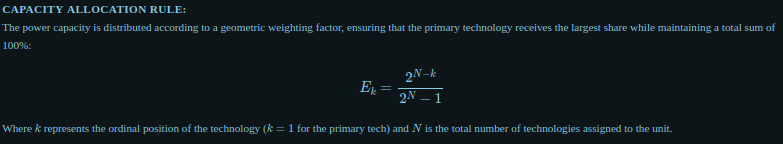h technology within that specific unit.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Capacity Allocation Rule:</span><br>
        The power capacity is distributed according to a geometric weighting factor, ensuring that the primary technology receives the largest share while maintaining a total sum of 100%:
        <div style="text-align: center; font-size: 18px; margin: 15px 0;">
            $$E_k = \frac{2^{N-k}}{2^N - 1}$$
        </div>
        Where <b>$k$</b> represents the ordinal position of the technology ($k=1$ for the primary tech) and <b>$N$</b> is the total number of technologies assigned to the unit.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: This algorithmic approach prevents over-representation of secondary fuels while ensuring that all potential technology matches are represented in the final Power Plant sheet.</i>
    </div>
</div>

In [ ]:
# 1. ************************************************************************* Function to compute proportional weights
def compute_proportions(n):
    weights = [2**(n - k - 1) for k in range(n)]
    total = sum(weights)
    return [w / total for w in weights]

# 2. ************************************************************************* Process each DataFrame in the dictionary
for zone in zone_names:
    key = f"{zone}_{data_target_year}"
    df = power_plants_dfs_dict.get(key)

    if df is not None:
        new_rows = []

        for _, row in df.iterrows():
            techs = str(row['Technology']).split()
            if len(techs) > 1:
                proportions = compute_proportions(len(techs))
                for idx, (tech, prop) in enumerate(zip(techs, proportions), start=1):
                    new_row = row.copy()
                    new_row['Technology'] = tech
                    new_row['Unit'] = f"{row['Unit']}_{idx}"
                    new_row['PowerCapacity'] = row['PowerCapacity'] * prop
                    new_rows.append(new_row)
            else:
                new_rows.append(row)

# 2.1. *********************************************************** Replace the original DataFrame with the expanded one
        power_plants_dfs_dict[key] = pd.DataFrame(new_rows)

# 3. ************************************************************************************************************* Done 
power_plants_dfs_dict

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.3. Fuel Data Classification</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        Similar to the technology mapping, the <b>Fuel</b> column is disaggregated for units capable of utilizing multiple fuel sources. This ensures that multi-fuel plants are accurately represented within the <i>Dispa-SET</i> framework, allowing for realistic cost and emission modeling.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Country-Specific Allocation:</span><br>
        The disaggregation of power capacity in this stage is driven by the <b>Proportional Technology-Fuel Tables</b> specifically developed for each country (e.g., the BE, DE, or UK dictionaries previously defined).
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: By using regional proportions rather than a fixed global average, the model captures local market nuances, such as the specific blend of biomass in coal-fired plants or the varied natural gas compositions across the European grid.</i>
    </div>
</div>

In [ ]:
# 1. ******************* Split multi-fuel power plant units into separate entries based on technology-fuel multipliers 
processed_power_plants_dfs_dict = {}

for zone in zone_names:

# 1.1. ********************************************************************************* Data Retrieval and Validation
    power_key = f"{zone}_{data_target_year}"
    fuel_key = zone
    power_df = power_plants_dfs_dict.get(power_key)
    fuel_df = fuel_technologies_match_dict.get(fuel_key, overal_fuel_technologies_match_df)

    if power_df is None:
        print(f"⚠️ No power plant DataFrame found for {power_key}")
        continue

    df = power_df.copy()
    new_rows = []
    rows_to_drop = []

# 1.2. ************************************************************************* Iterate and Identify Multi-Fuel Units
    for idx, row in df.iterrows():
        tech = str(row["Technology"]).strip()
        fuel_str = str(row["Fuel"]).strip()
        fuels = fuel_str.split()

# 1.2.1. ************************************* Skip units that only have a single fuel or are missing from the mapping
        if len(fuels) <= 1:
            continue

        if tech not in fuel_df.index:
            rows_to_drop.append(idx)
            continue

        original_capacity = row["PowerCapacity"]
        new_capacities = []
        new_rows_for_this_row = []

# 1.2.2. ********************************************************************* Split Unit and Calculate New Capacities 
        for i, fuel in enumerate(fuels, start=1):
            if fuel not in fuel_df.columns:
                continue
            multiplier = fuel_df.loc[tech, fuel]
            if pd.isna(multiplier):
                continue
            new_row = row.copy()
            new_row["Unit"] = f"{row['Unit']}_{i}"
            new_row["Fuel"] = fuel
            new_row["PowerCapacity"] = original_capacity * multiplier
            new_rows_for_this_row.append(new_row)
            new_capacities.append(new_row["PowerCapacity"])

        if not new_rows_for_this_row:
            rows_to_drop.append(idx)
            continue

# 1.2.3. ********************************************************************** Capacity Balancing (Residual Handling)
        sum_new_capacities = sum(new_capacities)
        
# 1.2.4. ************************ If the sum is less than the original, add the difference to the largest new capacity
        if sum_new_capacities < original_capacity:
            
# 1.2.4.1. ************************************************ Assign the remainder to the unit with the largest capacity
            max_capacity_idx = max(range(len(new_capacities)), key=lambda i: new_capacities[i])
            new_rows_for_this_row[max_capacity_idx]["PowerCapacity"] += (original_capacity - sum_new_capacities)

        new_rows.extend(new_rows_for_this_row)
        rows_to_drop.append(idx)

# 1.3. ***************************************************************************** Clean Up and Save Final DataFrame 
    df = df.drop(rows_to_drop, errors="ignore")
    if new_rows:
        df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

    processed_power_plants_dfs_dict[power_key] = df

# 2. ************************************************************************************************************ Done 
print("✅ Processing complete. Updated DataFrames stored in 'processed_power_plants_dfs_dict'.")
processed_power_plants_dfs_dict

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                       {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                       {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                 {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                 {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:            {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:       {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                         {zone_names}\n")
print (f"Target year:                                               {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):           {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the zone_names_equivalences_dictionary):           {[value['Acronym'] for value in selected_zone_names_equivalences_dict.values()]}\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:       overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:              fuel_technologies_match_dict\n")
print (f"Name of the PyPSA Nodal Capacities DataFrames (dictionary):{list(nodal_capacities_dfs_dict.keys())}\n")
print (f"Name of the Processed Power Plant DataFrames (dictionary): {list(processed_power_plants_dfs_dict.keys())}\n")

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.4. Null Capacity Scrubbing</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To finalize the Power Plants data frame, a comprehensive cleaning operation is performed to <b>erase all rows with null or zero Power Capacity</b>. This ensures that the Dispa-SET solver does not process non-existent assets, which could otherwise lead to convergence errors or unnecessary computational load.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Solver Optimization:</span><br>
        Removing these entries guarantees that the <b>$P_{max}$</b> constraints for the dispatchable fleet only include active, physically relevant generation units within the selected zones.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: This step is particularly important after the disaggregation phase, as some fuel-technology combinations may result in zero-weighted capacities that must be purged before the final CSV export.</i>
    </div>
</div>

In [ ]:
# 1. ************************************************************************** Iterate over each key in the dictionary
for key in list(processed_power_plants_dfs_dict.keys()):
    # Filter out rows where 'PowerCapacity' is 0
    processed_power_plants_dfs_dict[key] = processed_power_plants_dfs_dict[key][
        processed_power_plants_dfs_dict[key]['PowerCapacity'] != 0
    ]

# 2. ************************************************************************************************************* Done
print("✅ Processing complete. Updated DataFrames stored in 'processed_power_plants_dfs_dict'.")
processed_power_plants_dfs_dict

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.4. CHP Units Classification</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        In the <i>Dispa-SET</i> environment, Combined Heat and Power (CHP) units are modeled using specific operational parameters that define the coupling between thermal and electrical energy streams. Proper classification is essential for simulating district heating constraints and power-to-heat flexibility.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.05); padding: 15px; margin: 15px 10px; border-radius: 4px; border-left: 4px solid #87CEEB;">
        <div style="margin-bottom: 10px; font-size: 14px; color: #87CEEB;">
            <b style="color: #87CEEB;">CHPType:</b> Defines the operational mode (e.g., Back-pressure or Extraction-condensing), determining the feasible operating region of the unit.
        </div>
        <div style="margin-bottom: 10px; font-size: 14px; color: #87CEEB;">
            <b style="color: #87CEEB;">CHPPowerToHeat ($\sigma$):</b> The ratio of electrical power output to useful heat output.
            <div style="text-align: center; margin: 10px 0;">
                $$\sigma = \frac{\text{Power Output}}{\text{Heat Output}}$$
            </div>
        </div>
        <div style="margin-bottom: 10px; font-size: 14px; color: #87CEEB;">
            <b style="color: #87CEEB;">CHPPowerLossFactor:</b> Represents the trade-off in electrical efficiency ($MW_e$) per unit of increased thermal extraction ($MW_{th}$).
        </div>
        <div style="font-size: 14px; color: #87CEEB;">
            <b style="color: #87CEEB;">CHPMaxHeat:</b> The thermal nameplate capacity ($MW_{th}$) based on exchanger limits and infrastructure.
        </div>
    </div>
    <div style="text-align: left; color: #87CEEB; margin-top: 20px;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.1. CHP Units Nomenclature - Technology List</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The following technologies are eligible for CHP classification within the model. This list is extensible to accommodate emerging power-to-gas and electrolysis technologies:
        <ul style="margin-top: 10px; columns: 2; -webkit-columns: 2; -moz-columns: 2;">
            <li>CCGT (Combined Cycle)</li>
            <li>OCGT (Open Cycle)</li>
            <li>Steam Turbines (Coal/Gas)</li>
            <li>Biomass Engines</li>
            <li>PEME / ALKE*</li>
        </ul>
        <div style="font-style: italic; font-size: 12px; margin-top: 10px; border-top: 1px solid rgba(135, 206, 235, 0.2); padding-top: 5px;">
            *Note: The CHP list may be expanded to include Proton Exchange Membrane (PEME) and Alkaline Electrolyzers (ALKE) when utilized in heat-recovery scenarios.
        </div>
    </div>
</div>

In [ ]:
# 1. **************** Define all the Dispa-SET CHP technology lists from the common.py script of Dispa-SET core scripts
chp_technologies_set = ['COMC', 'COMCX', 'GTUR', 'GTURX', 'ICEN', 'ICENX', 'STUR', 'STURX', 'MCFC', 'PAFC', 'PEFC', 'SOFC' ,
                        'ASHP', 'GSHP' , 'REHE'
                       ]

# 2. **************************************************************************** Convert the set back to a sorted list
chp_technologies_list = sorted(list(chp_technologies_set))

# 3. ************************************************************************ Create a DataFrame with the single column
dispaSET_chp_tech_list = pd.DataFrame(chp_technologies_list, columns=['Dispa-SET CHP Technologies'])

# 4. ************************************************************************************************************* Done
print(dispaSET_chp_tech_list)

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.2. CHP Units Nomenclature - CHPType Dictionary</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To ensure structural integrity within the model, the CHP operational modes must be synchronized with the <i>Dispa-SET</i> core definitions. These identifiers are sourced directly from the toolkit's common definitions:
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 13px; margin: 15px 10px; font-family: monospace;">
        <b>Source Repository:</b> 
        <a href="https://github.com/energy-modelling-toolkit/Dispa-SET/blob/master/dispaset/common.py" style="color: #87CEEB; text-decoration: underline;">
            dispaset/common.py
        </a>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        The mapping logic utilizes a homogenization dictionary to translate raw technology inputs into recognized <b>CHPType</b> categories (e.g., <i>'Extraction'</i>, <i>'Back-pressure'</i>).
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <div style="font-size: 12px; color: #87CEEB; line-height: 1.4;">
            <span style="font-weight: bold; color: #87CEEB; text-transform: uppercase; font-size: 11px;">Critical Maintenance Notes:</span>
            <ul style="margin-top: 5px; list-style-type: square; padding-left: 20px;">
                <li>The first column values must remain <b>identical</b> to the "List of CHP types" defined in the Dispa-SET core code to prevent import failures.</li>
                <li>If the <code>common.py</code> script in the official repository is updated, the <code>chp_type_dictionary</code> in this pre-processor must be manually synchronized.</li>
                <li>This equivalence mapping is currently in a <b>limited beta state</b> and requires expansion as new hybrid-generation technologies are added.</li>
            </ul>
        </div>
    </div>
</div>

In [ ]:
# 1. ***************************************** Dictionary mapping CHP types to descriptions and equivalent technologies
chp_type_dict = {
    
"extraction"    :   {"Description": "Extraction Condensing Turbine; Can vary power/heat output flexibly",     "Equivalent_CHPType":  ["-"                                                      ]}  ,
    
"back-pressure" :   {"Description": "Back-Pressure Turbine; Produces power and heat in a fixed ratio"   ,     "Equivalent_CHPType":  ["links urban central gas CHP"                          ,
                                                                                                                                      "links urban central gas CHP CC"                       , 
                                                                                                                                      "links urban central solid biomass CHP"                ,
                                                                                                                                      "links urban central solid biomass CHP CC"               ]}  ,
    
"p2h"           :   {"Description": "Power-to-Heat Unit; Converts electrical energy into heat"          ,     "Equivalent_CHPType":  ["links residential rural air heat pump"                ,          
                                                                                                                                      "links services rural air heat pump"                   ,          
                                                                                                                                      "links residential urban decentral air heat pump"      ,
                                                                                                                                      "links services urban decentral air heat pump"         ,
                                                                                                                                      "links urban central air heat pump"                    , 
                                                                                                                                      "links residential rural ground heat pump"             ,
                                                                                                                                      "links services rural ground heat pump"                ,
                                                                                                                                      "links residential rural resistive heater"            
                                                                                                                                      "links services rural resistive heater"               
                                                                                                                                      "links residential urban decentral resistive heater"   ,
                                                                                                                                      "links services urban decentral resistive heater"      ,  
                                                                                                                                      "links urban central resistive heater"                   ]}

}

# 2. ************************************************************************************************************* Done
print(json.dumps(chp_type_dict, indent=4))

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.3. CHP Operational Mode Classification</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        This processing step executes the logic required to assign a specific <b>CHPType</b> to each eligible unit. By cross-referencing the unit's technology and fuel metadata with the previously defined dictionary, the system classifies plants into operational categories that dictate their flexibility in the heat-power plane.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Classification Logic:</span><br>
        Units are typically categorized as <b>'Back-pressure'</b> (fixed power-to-heat ratio) or <b>'Extraction-condensing'</b> (variable ratio with a power loss factor), allowing Dispa-SET to accurately simulate the dispatch of "must-run" heat vs. flexible electricity generation.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: If a technology is not found in the CHP dictionary, it is assigned a 'Null' or 'None' value, treating it as a standard power-only generator for the remainder of the simulation.</i>
    </div>
</div>

In [ ]:
# 1. **************************** Assign CHP types to units identified as CHP technologies based on name prefix matches
for key, df in processed_power_plants_dfs_dict.items():
    for index, row in df.iterrows():
        if row['Technology'] in dispaSET_chp_tech_list['Dispa-SET CHP Technologies'].values:
            unit = row['Unit']
            for chp_key, chp_value in chp_type_dict.items():
                
# 1.1. ****************************************** Check if the unit starts with any of the values in Equivalent_CHPType
                if any(unit.startswith(equivalent) for equivalent in chp_value['Equivalent_CHPType']):
                    df.at[index, 'CHPType'] = chp_key
                    break

# 2. ********************************************************************** Print the updated column from the DataFrame
for key, df in processed_power_plants_dfs_dict.items():
    print(f"CHPType column for {key}:")

# 3. ************************************************************************************************************* Done
    print("✅ Processing complete. Updated DataFrames stored in 'processed_power_plants_dfs_dict'.")
    print(df[['CHPType']])

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.4. CHP Units Nomenclature - CHP Features Dictionary</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        To ensure high-fidelity modeling of thermal-electrical coupling, the technical parameters for CHP units—specifically <b>CHPPowerToHeat</b> ($\sigma$), <b>CHPPowerLossFactor</b> ($\beta$), <b>CHPMaxHeat</b>, and <b>COP</b>—are derived from a curated selection of peer-reviewed literature and international technical standards.
    </div>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 13px; margin: 15px 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Data Source References:</span>
        <ul style="list-style-type: decimal; padding-left: 20px; margin-top: 8px;">
            <li style="margin-bottom: 5px;">
                <b>Urosevic et al. (2013):</b> Methodologies for operational efficiency and thermodynamic constraints in industrial CHP systems.
                <br><a href="https://www.sciencedirect.com/science/article/pii/S0360544213005975" style="color:#87CEEB; font-size: 11px; text-decoration: underline;">ScienceDirect Resource</a>
            </li>
            <li style="margin-bottom: 5px;">
                <b>Lecomte et al. (JRC, 2017):</b> Best Available Techniques (BAT) Reference Document for Large Combustion Plants.
                <br><a href="https://publications.jrc.ec.europa.eu/repository/handle/JRC107769" style="color:#87CEEB; font-size: 11px; text-decoration: underline;">JRC Publications Repository</a>
            </li>
            <li>
                <b>EPA Catalog (2017):</b> Comprehensive technical specifications for OCGT, CCGT, and reciprocating engine CHP configurations.
                <br><a href="https://www.epa.gov/sites/default/files/2015-07/documents/catalog_of_chp_technologies.pdf" style="color:#87CEEB; font-size: 11px; text-decoration: underline;">EPA Technical PDF</a>
            </li>
        </ul>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <i>Note: These values are integrated into the feature dictionary to allow for automated parameter assignment based on technology type, ensuring that the Dispa-SET unit-commitment logic respects the physical energy-balance limits of each plant.</i>
    </div>
</div>

In [ ]:
# 1. ******************************************************************** Dictionary mapping CHP technologies features 
chp_parameters_dict = pd.DataFrame({
    
    'Technology'         :   [  'COMC'                          , 'GTUR'                          , 'STUR'                          , 'ICEN'                          ,
                                'SOXE'                          , 'SOFC'                          , 'MCFC'                          , 'HBBS'                          ,
                                'COMC'                          , 'GTUR'                          , 'STUR'                          , 'ICEN'                          , 
                                'PEME'                          , 'ALKE'                          , 'PEFC'                          , 'PAFC'                          ,
                                'DMFC'                          , 'REFC'                          ,
                                'ASHP'                          , 'GSHP'                          , 'WSHP'                          , 'REHE'                             ],
    
    'CHPType'            :   [  'extraction'                    , 'extraction'                    , 'extraction'                    , 'extraction'                    ,
                                'extraction'                    , 'extraction'                    , 'extraction'                    , 'extraction'                    ,
                                'back-pressure'                 , 'back-pressure'                 , 'back-pressure'                 , 'back-pressure'                 , 
                                'back-pressure'                 , 'back-pressure'                 , 'back-pressure'                 , 'back-pressure'                 ,
                                'back-pressure'                 , 'back-pressure'                 ,
                                'p2h'                           , 'p2h'                           , 'p2h'                           , 'p2h'                              ],
    
    'CHPPowerToHeat'     :   [  1.50                            , 1.09                            , 2.00                            , 2.00                            ,
                                2.00                            , 0.25                            , 0.20                            , 0.20                            ,
                                1.00                            , 1.50                            , 1.50                            , 2.00                            , 
                                2.00                            , 2.00                            , 2.00                            , 2.00                            ,
                                2.00                            , 2.00                            ,
                                1.00                            , 1.00                            , 1.00                            , 1.00                               ],
    
    'CHPPowerLossFactor' :   [  0.25                            , 0.35                            , 0.3                             , 0.2                             ,
                                0.15                            , 0.12                            , 0.08                            , 0.15                            ,
                                0.00                            , 0.00                            , 0.00                            , 0.00                            , 
                                0.00                            , 0.00                            , 0.00                            , 0.00                            ,
                                0.00                            , 0.00                            ,
                                0.00                            , 0.00                            , 0.00                            , 0.00                              ],
    
    'CHPMaxHeat'         :   [  'PowerCapacity * 1.2'           , 'PowerCapacity * 1.2'           , 'PowerCapacity * 1.2'           , 'PowerCapacity * 1.2'           ,
                                'PowerCapacity * 1.5'           , 'PowerCapacity * 1.5'           , 'PowerCapacity * 1.8'           , 'PowerCapacity * 1.8'           ,
                                'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat', 
                                'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat',
                                'PowerCapacity / CHPPowerToHeat', 'PowerCapacity / CHPPowerToHeat',
                                'PowerCapacity * COP'           , 'PowerCapacity * COP'           , 'PowerCapacity * COP'           , 'PowerCapacity * COP'             ],
                                                                  
    'COP'                :   [  None                            , None                            , None                            , None                            ,
                                None                            , None                            , None                            , None                            ,
                                None                            , None                            , None                            , None                            , 
                                None                            , None                            , None                            , None                            ,
                                None                            , None                            ,
                                2.8                             , 3.5                             , 4.0                             , 1.00                             ]
})

# 2. ************************************************************************************************************ Done
chp_parameters_dict

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.5. Automated Parameter Population</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        In this final CHP refinement step, the theoretical values stored in the <b>CHP parameters dictionary</b> are mapped onto the active data frame. This process populates the technical columns—<b>CHPPowerToHeat</b>, <b>CHPPowerLossFactor</b>, and <b>COP</b>—based on the specific technology and fuel combination identified for each unit.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Mapping Execution:</span><br>
        Using a vectorized lookup operation, the system ensures that every plant designated as a CHP unit receives its corresponding stoichiometric and efficiency coefficients. 
        <ul style="margin-top: 8px; list-style-type: circle; padding-left: 20px;">
            <li><b>$\sigma$ (Power-to-Heat):</b> Critical for defining the heat-led or power-led priority.</li>
            <li><b>$\beta$ (Loss Factor):</b> Essential for calculating the reduction in net power during steam extraction.</li>
            <li><b>COP (Coefficient of Performance):</b> Applied specifically to heat pump units or hybrid thermal systems.</li>
        </ul>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
        <i>Note: Units not identified as CHP are assigned a default value of 0 or NaN for these fields, maintaining a consistent matrix structure for the final Dispa-SET Power Plant sheet export.</i>
    </div>
</div>

In [ ]:
# 1. ****************************************************************** Columns to bring from chp_parameters_dictionary
merge_cols = ['Technology'     , 'CHPType']
param_cols = ['CHPPowerToHeat' , 'CHPPowerLossFactor' , 'CHPMaxHeat' , 'COP']

for zone in zone_names:
    key = f"{zone}_{data_target_year}"
    df = processed_power_plants_dfs_dict[key]

# 1.1. ************************************************************************ Keep only rows with a non-empty CHPType
    mask = df['CHPType'].notna() & (df['CHPType'] != "")

# 1.2. ********************************************************************** Merge only the rows where merge is needed
    df_merge = df.loc[mask, merge_cols].merge(
        chp_parameters_dict,
        on=merge_cols,
        how='left'
    )

# 1.3. **************************************************** Assign merged parameter values back into the main dataframe
    df.loc[mask, param_cols] = df_merge[param_cols].values

# 1.4. ********************************************************************************** Save back into the dictionary
    processed_power_plants_dfs_dict[key] = df

# 2. ********************************************************************* Print the updated columns from the DataFrame
for key, df in processed_power_plants_dfs_dict.items():
    print(f"CHPPowerToHeat,	CHPPowerLossFactor, CHPMaxHeat and COP columns for {key}:")

# 3. ************************************************************************************************************ Done
    print("✅ Processing complete. Updated DataFrames stored in 'processed_power_plants_dfs_dict'.")
    print(df[['CHPPowerToHeat' , 'CHPPowerLossFactor' , 'CHPMaxHeat' , 'COP']])

<div style="background-color: #000; padding: 20px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: left; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.4.6. Thermal Capacity (CHPMaxHeat) Derivation</span>
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        The <b>CHPMaxHeat</b> parameter represents the maximum useful thermal power ($MW_{th}$) that a unit can supply to the heat grid. Unlike fixed efficiency parameters, this value is dynamically calculated for each unit by applying the <b>Power-to-Heat ratio</b> ($\sigma$) to the previously established electrical capacity.
    </div>
    <br>
    <div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin: 10px;">
        <span style="font-weight: bold; text-transform: uppercase; letter-spacing: 0.5px;">Mathematical Formulation:</span><br>
        The calculation follows the inverse relationship defined by the unit's stoichiometry:
        <div style="text-align: center; margin: 15px 0; font-size: 18px;">
            $$CHPMaxHeat = \frac{PowerCapacity}{\sigma}$$
        </div>
        Where <b>$PowerCapacity$</b> is the nominal electrical output ($MW_e$) and <b>$\sigma$</b> is the dimensionless Power-to-Heat ratio specific to the technology type.
    </div>
    <div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-left: 10px; opacity: 0.9;">
    <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <i>Note: This step is vital for Dispa-SET to enforce the heat-demand satisfaction constraints. By deriving heat capacity from electrical capacity, the model maintains thermodynamic consistency across the entire generation fleet.</i>
    </div>
</div>

In [ ]:
# 1. *************************************************************** Pattern to detect words (potential variable names)
formula_pattern = re.compile(r"[A-Za-z_][A-Za-z0-9_]*")

for zone in zone_names:
    key = f"{zone}_{data_target_year}"
    df = processed_power_plants_dfs_dict[key]

    for idx, row in df.iterrows():

        cell = row["CHPMaxHeat"]

# 1.1. ********************************************************************************* Skip empty or non-string cells
        if pd.isna(cell) or not isinstance(cell, str) or cell.strip() == "":
            continue

        expression = cell.strip()

# 1.2. ******************************************************************************** Extract possible variable names
        tokens = set(formula_pattern.findall(expression))
        columns_used = [t for t in tokens if t in df.columns]

        if not columns_used:
            
# 1.2.1. ************************************************************************ No valid column names → not a formula
            continue

# 1.3. *************************************************************************** Build evaluation dictionary from row
        local_vars = {}
        valid = True

        for col in columns_used:
            val = row[col]
            if pd.isna(val):
                valid = False
                break
            local_vars[col] = float(val)

        if not valid:
            continue

# 1.4. ************************************************************************************************ Safe evaluation
        try:
            
# 1.4.1. ************************************************************* Evaluate with NO builtins and ONLY our variables
            result = eval(
                expression,
                {"__builtins__": None},   # Disable all built-ins
                local_vars                # Only allow numeric column values
            )

            df.at[idx, "CHPMaxHeat"] = float(result)

        except Exception as e:
            print(f"⚠️ Error evaluating formula in {key}, row {idx}: '{expression}' → {e}")
            continue

    processed_power_plants_dfs_dict[key] = df

# 2. ********************************************************************** Print the updated column from the DataFrame
for key, df in processed_power_plants_dfs_dict.items():
    print(f"CHPMaxHeat column for {key}:")

# 3. ********************************************************************************************************* Done
    print("✅ Processing complete. Updated DataFrames stored in 'processed_power_plants_dfs_dict'.")
    print(df[['CHPMaxHeat']])

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                        {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                        {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                  {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                  {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                 {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:             {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                          {zone_names}\n")
print (f"Target year:                                                {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):            {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the zone_names_equivalences_dictionary):            {[value['Acronym'] for value in selected_zone_names_equivalences_dict.values()]}\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:        overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:               fuel_technologies_match_dict\n")
print (f"Name of the PyPSA Nodal Capacities DataFrames (dictionary): {list(nodal_capacities_dfs_dict.keys())}\n")
print (f"Name of the Processed Power Plant DataFrames (dictionary):  {list(processed_power_plants_dfs_dict.keys())}\n")
print (f"name of the dispaSET CHP technologies list:                 dispaSET_chp_tech_list\n")
print (f"Keys of the CHP type dictionary:                            {list(chp_type_dict.keys())}\n")
print (f"Keys of the CHP parameters dictionady:                      {list(chp_parameters_dict.keys())}\n")

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.5. Techno-Economic Features Classification</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To ensure a high-fidelity unit commitment and dispatch simulation, each power unit is assigned a comprehensive set of <b>techno-economic parameters</b>. These features define the operational flexibility, efficiency curves, and cost structures that govern how the solver utilizes each asset within the energy system. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 13px; margin-bottom: 20px;"> <b>Feature Set:</b> <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 10px; font-family: 'Times New Roman';"> <div>• <b>Efficiency:</b> Ratio of output/input.</div> <div>• <b>Ramp Rates:</b> Max output change speed.</div> <div>• <b>MinUp/DownTime:</b> ON/OFF constraints.</div> <div>• <b>StartUpCost:</b> Economic penalty for activation.</div> <div>• <b>PartLoadMin:</b> Minimum output level.</div> <div>• <b>CO2Intensity:</b> tCO₂ per MWh generated.</div> </div> </div>

<div style="text-align: left; color: #87CEEB;">
    <span style="font-weight: bold; font-size: 16px;">Primary Bibliographic Sources</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <div style="max-height: 400px; overflow-y: auto; padding-right: 15px; font-size: 13px; color: #87CEEB; line-height: 1.6;">
        <p style="font-weight: bold; color: #87CEEB; text-decoration: underline;">I. Specialized Techno-Economic Reports</p>
        <ol>
            <li>DIW (2013). Costs of Electricity Generation until 2030: <a href="[https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf](https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf)" style="color: skyblue;">Link</a></li>
            <li>DIW (2014). Electricity Sector Data for Policy Modeling: <a href="[https://www.diw.de/documents/publikationen/73/diw_01.c.440963.de/diw_datadoc_2014-072.pdf](https://www.diw.de/documents/publikationen/73/diw_01.c.440963.de/diw_datadoc_2014-072.pdf)" style="color: skyblue;">Link</a></li>
            <li>DIW (2016). Start-up Costs of Thermal Power Plants: <a href="[https://d-nb.info/115301274X/34](https://d-nb.info/115301274X/34)" style="color: skyblue;">Link</a></li>
            <li>Hentschel (2016). Fraunhofer report on plant flexibility: <a href="[https://doi.org/10.1016/j.egyr.2016.03.002](https://doi.org/10.1016/j.egyr.2016.03.002)" style="color: skyblue;">Link</a></li>
            <li>Bertsch (2016). Relevance of Grid Expansion: <a href="[https://www.ewi.uni-koeln.de/cms/wp-content/uploads/2016/12/WP_15_07-Relevance-of-Grid-Expansion.pdf](https://www.ewi.uni-koeln.de/cms/wp-content/uploads/2016/12/WP_15_07-Relevance-of-Grid-Expansion.pdf)" style="color: skyblue;">Link</a></li>
            <li>IEA (2011). Technology Roadmap: <a href="[https://www.iea.org/reports/world-energy-outlook-2011](https://www.iea.org/reports/world-energy-outlook-2011)" style="color: skyblue;">Link</a></li>
            <li>Klobasa et al. (2009). Dynamic simulation of load management: <a href="[https://publica-rest.fraunhofer.de/server/api/core/bitstreams/8dd2c2f3-d4ab-439b-811e-35c1c99d77d0/content](https://publica-rest.fraunhofer.de/server/api/core/bitstreams/8dd2c2f3-d4ab-439b-811e-35c1c99d77d0/content)" style="color: skyblue;">Link</a></li>
            <li>Traber, Kemfert (2011). Gone with the wind? Thermal incentives: <a href="[https://doi.org/10.1016/j.eneco.2010.07.002](https://doi.org/10.1016/j.eneco.2010.07.002)" style="color: skyblue;">Link</a></li>
            <li>Van der Bergh (2015). Cycling of conventional power plants: <a href="[https://doi.org/10.1016/j.enconman.2015.03.026](https://doi.org/10.1016/j.enconman.2015.03.026)" style="color: skyblue;">Link</a></li>
            <li>Parsons Brinckerhoff - DECC (2014). UK Power plant costs: <a href="[https://webarchive.nationalarchives.gov.uk](https://webarchive.nationalarchives.gov.uk)" style="color: skyblue;">Link</a></li>
            <li>Ecofys (2014). Technical Assessment of Coal and Gas Plant: <a href="[https://assets.publishing.service.gov.uk/media/5a7dfc11ed915d74e33ef4be/Technical_Assessment_of_the_Operation_of_Coal_and_Gas_Plant_PB_Power_FIN....pdf](https://assets.publishing.service.gov.uk/media/5a7dfc11ed915d74e33ef4be/Technical_Assessment_of_the_Operation_of_Coal_and_Gas_Plant_PB_Power_FIN....pdf)" style="color: skyblue;">Link</a></li>
            <li>dena (2005). Deutsche Energie-Agentur Efficiency Report: <a href="[https://www.dena.de/fileadmin/dena/Dokumente/Pdf/9113_dena-Netzstudie_I.pdf](https://www.dena.de/fileadmin/dena/Dokumente/Pdf/9113_dena-Netzstudie_I.pdf)" style="color: skyblue;">Link</a></li>
            <li>dena (2008). Grid integration of wind energy in Germany: <a href="[https://www.boell.de/sites/default/files/assets/boell.de/images/download_de/oekologie/Kurzanalyse_KuN_Planung_D_2020_2030_Kurzfassung.pdf](https://www.boell.de/sites/default/files/assets/boell.de/images/download_de/oekologie/Kurzanalyse_KuN_Planung_D_2020_2030_Kurzfassung.pdf)" style="color: skyblue;">Link</a></li>
            <li>RWI (1997). German Economic Situation: <a href="[https://www.iwh-halle.de/en/publications/detail/the-international-and-german-economic-situation-in-fall-1997](https://www.iwh-halle.de/en/publications/detail/the-international-and-german-economic-situation-in-fall-1997)" style="color: skyblue;">Link</a></li>
            <li>Grimm (2007). Electricity Market Design & EEX Rules: <a href="[https://link.springer.com/content/pdf/10.1007/s12398-008-0020-7.pdf](https://link.springer.com/content/pdf/10.1007/s12398-008-0020-7.pdf)" style="color: skyblue;">Link</a></li>
            <li>Kumar et al. (2012). Median cost studies (NREL): <a href="[https://docs.nrel.gov/docs/fy12osti/55433.pdf](https://docs.nrel.gov/docs/fy12osti/55433.pdf)" style="color: skyblue;">Link</a></li>
        </ol>
    </div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        <span style="font-size: 11px; color: skyblue; opacity: 0.7;">This bibliography forms the evidentiary basis for the parameter calibration within the Dispa-SET pre-processor.</span>
    </div>
</div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.5.1. Techno-Economic Features Dictionary 1</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The full data for the different units is loaded based on the technology, subtechnology (CHP), fuel type, and power capacity range.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This dictionary is undergoing continuous revision. Emerging technologies and recent updates require verification against the LookUp_Table file.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ****** Get the path to the "TechnoEconomic_Features_Dictionary_1" and "TechnoEconomic_Features_Dictionary_2" files
additional_path_4 = "/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coefficients_Sources/TechnoEconomic_Features_Dictionary_1.csv"

technoeconomic_features_dictionary_1_file_path = dispaSET_unleash_folder_path + additional_path_4

print("technoeconomic_features_dictionary_1_file_path:", technoeconomic_features_dictionary_1_file_path)

# 2. ******** Upload the "TechnoEconomic_Features_Dictionary_1" and "TechnoEconomic_Features_Dictionary_2" dictionaries
technoeconomic_features_dictionary_1 = pd.read_csv(technoeconomic_features_dictionary_1_file_path)

# 3. ************************************************************************************************************* Done 
print(list(technoeconomic_features_dictionary_1.columns))
technoeconomic_features_dictionary_1

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.5.2. Parameter Integration Logic (Dictionary 1)</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> This processing stage executes the <b>filtering and assignment</b> of techno-economic values to the unit database. By cross-referencing the unit's physical characteristics with <b>Dictionary 1</b>, the system automates the population of technical constraints required for the dispatch optimization. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Filtering Criteria:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The assignment is performed through a multi-key lookup based on: <ul style="margin-top: 5px;"> <li><b>Technology & Fuel:</b> Distinguishing between thermal, renewable, and storage assets.</li> <li><b>CHP Status:</b> Applying specialized efficiency and ramping profiles for co-generation.</li> <li><b>Capacity Thresholds:</b> Ensuring that scale-dependent parameters (e.g., higher efficiency for larger turbines) are accurately reflected.</li> </ul> </div> </div>

<div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-top: 20px;">
    <b>Operational Impact:</b> This automated filtering ensures that every unit in the <i>PowerPlants</i> sheet is equipped with a consistent and scientifically-backed set of operational limits, such as <code>MinUpTime</code> and <code>RampUpRate</code>, which are fundamental for the Dispa-SET unit commitment algorithm.
</div>

<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <span style="font-size: 11px; color: skyblue; opacity: 0.7;">The system verifies that no null values remain in the critical technical columns after this mapping is complete.</span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_1, zone_names, data_target_year):
    unmatched_rows = []
    numeric_cols = [
        'Efficiency'  , 'MinUpTime'   , 'MinDownTime' , 'RampUpRate'    , 'RampDownRate'  , 'StartUpCost'  , 
        'RampingCost' , 'PartLoadMin' , 'StartUpTime' , 'NoLoadCost_pu' , 'MinEfficiency' ,	'CO2Intensity'
    ]

# 1.2. ******************************************************************************** Iterate Through Zones and Units
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue

        df = processed_power_plants_dfs_dict[key]

        for idx, row in df.iterrows():
            tech = row['Technology']
            chp = row.get('CHPType', np.nan)
            fuel = row['Fuel']
            power_capacity = row['PowerCapacity']

# 1.3. ************************************************************ Find matching rows in the technoeconomic dictionary
            matches = technoeconomic_features_dictionary_1[
                (technoeconomic_features_dictionary_1['Technology'] == tech) &
                (technoeconomic_features_dictionary_1['CHPType'].isna() if pd.isna(chp)
                 else (technoeconomic_features_dictionary_1['CHPType'] == chp)) &
                (technoeconomic_features_dictionary_1['Fuel'] == fuel)
            ]

            if matches.empty:
                unmatched_rows.append((key, idx))
                continue

# 1.4. ********************************************************************************* Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]

# 1.5. ************************************************************************** Calculate average for numeric columns
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. *********************************************************************** Return just the number of unmatched rows
    return len(unmatched_rows)

# 2. *************************************************************************************************** Example usage:
num_unmatched = update_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_1,
    zone_names,
    data_target_year
)

# 3. ************************************************************************************************************** Done
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.5.3. Techno-Economic Features Dictionary 2</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To ensure 100% data coverage across the modeled regions, a <b>secondary filtering process</b> is implemented. This stage utilizes the extensive <b>Dispa-SET 30-country database</b> as a fallback repository. It is specifically triggered for units or technologies that do not yield a match in the primary reference dictionary. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Fallback Mechanism:</b> The full data for the different units from 30 EU countries in the Dispa-SET database are uploaded for use in a secondary filtering process for all those rows where data cannot be found in the first dictionary. </div>

<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5;">
    <b>Operational Logic:</b> The script dynamically constructs the file path, loads the EU-30 technical data into a pandas DataFrame, and verifies the available column headers to prepare for the secondary matching phase.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This secondary dataset provides the necessary redundancy to handle legacy plants or regional technology variations not explicitly covered in recent primary literature.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ************************************************** Get the path to the "TechnoEconomic_Features_Dictionary_12 file
additional_path_5 = "/scripts/Unleash_PyPSA_DispaSET_Raw_Data_Processing/Coefficients_Sources/TechnoEconomic_Features_Dictionary_2.csv"
technoeconomic_features_dictionary_2_file_path = dispaSET_unleash_folder_path + additional_path_5

print("technoeconomic_features_dictionary_2_file_path:", technoeconomic_features_dictionary_2_file_path)

# 2. ****************************************************** Upload the "TechnoEconomic_Features_Dictionary_1" dictionay
technoeconomic_features_dictionary_2 = pd.read_csv(technoeconomic_features_dictionary_2_file_path)

# 3. ************************************************************************************************************* Done
print(list(technoeconomic_features_dictionary_2.columns))
technoeconomic_features_dictionary_2

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 17px; margin-left: 10px;">8.5.4. Parameter Integration Logic (Dictionary 2)</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To ensure 100% data coverage across the modeled regions, a <b>secondary filtering process</b> is implemented. This stage utilizes the extensive <b>Dispa-SET 30-country database</b> as a fallback repository. It is specifically triggered for units or technologies that do not yield a match in the primary reference dictionary. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Fallback Mechanism:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> If <i>Dictionary 1</i> returns a null result, the system queries this secondary dataset to find the most representative technical parameters for: <ul style="margin-top: 5px;"> <li><b>Regional Variations:</b> Specific plant configurations common in diverse EU-30 energy markets.</li> <li><b>Legacy Technologies:</b> Older generation units that may not be covered by recent 2024-2025 literature but exist in the Dispa-SET core database.</li> <li><b>Parameter Continuity:</b> Maintaining alignment with standard Dispa-SET unit-commitment assumptions for Pan-European studies.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 16px;">Operational Impact</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 14px; margin-top: 10px;">
    <b>Reliability:</b> This two-tier approach prevents simulation failures caused by missing technical coefficients. By leveraging the standardized EU-30 database, the pre-processor ensures that every row in the final <i>PowerPlants.csv</i> is robust and ready for the Dispa-SET solver.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: Parameters retrieved from Dictionary 2 are marked in the metadata to distinguish between literature-updated values and standard database defaults.</i>
    </span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <span style="font-size: 11px; color: skyblue; opacity: 0.7;">The integration of these 30 EU datasets provides the necessary redundancy for cross-border interconnection modeling.</span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_empty_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_2, zone_names, data_target_year):
    unmatched_rows = []
    numeric_cols = [
        'Efficiency'  , 'MinUpTime'   , 'MinDownTime' , 'RampUpRate'    , 'RampDownRate'  , 'StartUpCost'  ,
        'RampingCost' , 'PartLoadMin' , 'StartUpTime' , 'NoLoadCost_pu' , 'MinEfficiency' , 'CO2Intensity'
    ]

# 1.2. ******************************************************************************** Iterate Through Zones and Units    
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue

        df = processed_power_plants_dfs_dict[key]

        for idx, row in df.iterrows():
            
# 1.2.1. **************************************************************** Check if all numeric columns are empty or NaN
            if not all(pd.isna(row[col]) or row[col] == '' for col in numeric_cols):
                continue  # Skip if any numeric column has a value

            tech = row['Technology']
            chp = row.get('CHPType', np.nan)
            fuel = row['Fuel']
            power_capacity = row['PowerCapacity']

# 1.2.2. ********************************************************** Find matching rows in the technoeconomic dictionary
            matches = technoeconomic_features_dictionary_2[
                (technoeconomic_features_dictionary_2['Technology'] == tech) &
                (technoeconomic_features_dictionary_2['CHPType'].isna()
                 if pd.isna(chp)
                 else (technoeconomic_features_dictionary_2['CHPType'] == chp)) &
                (technoeconomic_features_dictionary_2['Fuel'] == fuel)
            ]

            if matches.empty:
                unmatched_rows.append((key, idx))
                continue

# 1.2.3. ******************************************************************************* Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]

# 1.2.4. ************************************************************************ Calculate average for numeric columns
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. *********************************************************************** Return just the number of unmatched rows
    return len(unmatched_rows)
    
# 2. *************************************************************************************************** Example usage:
num_unmatched = update_empty_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_2,
    zone_names,
    data_target_year
)

# 3. ************************************************************************************************************* Done 
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.5.5. Stochastic Averaging & Residual Mapping</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To resolve complex data gaps where specific <b>(Fuel, Technology, Capacity, CHPType)</b> tuples are unavailable, a third-tier heuristic is applied. This stage ensures that no unit remains unparameterized by generating a <b>technology-class benchmark</b>. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Averaging Methodology:</b> For units without an exact match, the system identifies all entries in Dictionary 1 belonging to the same broad technology category. It then calculates the <b>arithmetic mean</b> of their techno-economic features to provide a representative proxy value. </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.5.5.1. Technology-Based Average Classification</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The script falls back to a category-level assignment. Parameters are derived as the average of all valid matches within the primary dictionary, ensuring that even unique or outlier units possess physically plausible operational constraints.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This method prioritizes simulation stability by ensuring that "unknown" units do not default to zero, which would otherwise lead to infeasible optimization results in Dispa-SET.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_1, zone_names, data_target_year):
    unmatched_rows = []
    numeric_cols = [
        'Efficiency'  , 'MinUpTime'   , 'MinDownTime' , 'RampUpRate'    , 'RampDownRate'  , 'StartUpCost'  , 
        'RampingCost' , 'PartLoadMin' , 'StartUpTime' , 'NoLoadCost_pu' , 'MinEfficiency' ,	'CO2Intensity'
    ]
    
# 1.2. ******************************************************************************** Iterate Through Zones and Units    
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue

        df = processed_power_plants_dfs_dict[key]

        for idx, row in df.iterrows():
            tech = row['Technology']
            power_capacity = row['PowerCapacity']

# 1.2.1. ********************************************************************************** MATCH USING ONLY TECHNOLOGY
            matches = technoeconomic_features_dictionary_1[
                technoeconomic_features_dictionary_1['Technology'] == tech
            ]

            if matches.empty:
                unmatched_rows.append((key, idx))
                continue

# 1.2.2. ******************************************************************************* Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]

# 1.2.3. **************************************************************************** Fill numeric values with averages
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. *********************************************************************** Return just the number of unmatched rows    
    return len(unmatched_rows)

# 2. *************************************************************************************************** Example usage:
num_unmatched = update_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_1,
    zone_names,
    data_target_year
)

# 3. ************************************************************************************************************* Done
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.5.5.2. Secondary Stochastic Averaging (Dictionary 2)</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> In cases where gaps persist after the initial primary dictionary pass, the heuristic logic is extended to the <b>secondary dataset</b>. This ensures that even for units not found in the refined literature, a robust technical profile is generated based on broader regional benchmarks. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Redundant Mapping Logic:</b> This step replicates the stochastic averaging methodology but utilizes <b>Dictionary 2 (EU-30 Database)</b> as the data source. It targets remaining unassigned units by aggregating values across technology categories found in the standardized Dispa-SET fleet. </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.5.5.2. Secondary Technology-Based Classification</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The script identifies any residual units that failed the primary category-level assignment. By calculating the mean parameters from Dictionary 2, the pre-processor guarantees that every asset—regardless of its specificity—is assigned a functional set of techno-economic constraints.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This double-tier averaging approach eliminates "orphan" rows in the final Dispa-SET input files, ensuring global convergence of the mathematical model.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_2, zone_names, data_target_year):
    unmatched_rows = []
    numeric_cols = [
        'Efficiency'  , 'MinUpTime'   , 'MinDownTime' , 'RampUpRate'    , 'RampDownRate'  , 'StartUpCost'  , 
        'RampingCost' , 'PartLoadMin' , 'StartUpTime' , 'NoLoadCost_pu' , 'MinEfficiency' ,	'CO2Intensity'
    ]

# 1.2. ******************************************************************************** Iterate Through Zones and Units    
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue

        df = processed_power_plants_dfs_dict[key]

        for idx, row in df.iterrows():
            tech = row['Technology']
            power_capacity = row['PowerCapacity']

# 1.2.1. ********************************************************************************** MATCH USING ONLY TECHNOLOGY
            matches = technoeconomic_features_dictionary_2[
                technoeconomic_features_dictionary_2['Technology'] == tech
            ]

            if matches.empty:
                unmatched_rows.append((key, idx))
                continue

# 1.2.2. ******************************************************************************** Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]

# 1.2.3. ***************************************************************************** Fill numeric values with averages
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. ************************************************************************ Return just the number of unmatched rows    
    return len(unmatched_rows)

# 2. **************************************************************************************************** Example usage:
num_unmatched = update_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_2,
    zone_names,
    data_target_year
)

# **************************************************************************************************************** Done
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.5.6. Final Dataset Completion & Null Handling</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> The final phase of the techno-economic parameterization involves a <b>comprehensive scan</b> of the power plant dataframe to identify and fill any remaining empty fields. This ensures that the dataset is structurally complete and fulfills the strict input requirements of the Dispa-SET solver. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Last-Mile Data Population:</b> After applying primary and secondary dictionaries, as well as stochastic averaging, any residual <i>NaN</i> values—typically in non-critical or highly specific technical columns—are addressed using global technology defaults or zero-value padding where appropriate. </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.5.6.1. Residual Parameter Population</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> This step executes a global <code>fillna()</code> or targeted replacement strategy. It guarantees that every operational feature—from ramping costs to emission intensities—contains a valid numerical entry, preventing the optimization algorithm from encountering undefined mathematical constraints.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: Once this process is complete, the "PowerPlants" sheet is finalized and ready for the final technical validation before being exported to the Dispa-SET simulation environment.</i>
    </span>
</div>

</div>

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                        {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                        {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                  {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                  {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                 {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:             {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                          {zone_names}\n")
print (f"Target year:                                                {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):            {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the zone_names_equivalences_dictionary):            {[value['Acronym'] for value in selected_zone_names_equivalences_dict.values()]}\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:        overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:               fuel_technologies_match_dict\n")
print (f"Name of the PyPSA Nodal Capacities DataFrames (dictionary): {list(nodal_capacities_dfs_dict.keys())}\n")
print (f"Name of the Processed Power Plant DataFrames (dictionary):  {list(processed_power_plants_dfs_dict.keys())}\n")
print (f"name of the dispaSET CHP technologies list:                 dispaSET_chp_tech_list\n")
print (f"Keys of the CHP type dictionary:                            {list(chp_type_dict.keys())}\n")
print (f"Keys of the CHP parameters dictionady:                      {list(chp_parameters_dict.keys())}\n")
print (f"Path to the Technoeconomic Features Dictionary 1 file:      {technoeconomic_features_dictionary_1_file_path}\n")
print (f"Path to the Technoeconomic Features Dictionary 2 file:      {technoeconomic_features_dictionary_2_file_path}\n")

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6. Storage Features Classification</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To accurately model energy flexibility, storage units are characterized by parameters that define their capacity limits, charging dynamics, and inherent losses. Unlike standard generation units, these assets are constrained by the state of charge (SoC) across temporal steps. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 13px; margin-bottom: 20px;"> <b>Technical Specifications:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> <ul style="list-style-type: none; padding-left: 0;"> <li><b style="display: inline-block; width: 10em;">STOCapacity:</b> Maximum energy volume (MWh or GJ).</li> <li><b style="display: inline-block; width: 10em;">STOSelfDischarge:</b> Rate of passive energy loss (p.u.).</li> <li><b style="display: inline-block; width: 10em;">STOMaxCharging:</b> Peak absorption power (MW).</li> <li><b style="display: inline-block; width: 10em;">STOEfficiency:</b> Ratio of energy stored per unit of input (0.0 to 1.0).</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.1. Storage Features Power Units List</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> This section identifies the specific assets within the fleet that support storage functionality (e.g., PHES, Li-ion batteries, Thermal Storage). At this stage, the logic isolates these units to prepare for the assignment of technical coefficients, excluding the individual energy capacity ($STOCapacity$) which is handled separately during the scale-up phase.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This list remains under active revision. It is critical to synchronize these identifiers with the latest technology mappings in the <code>commons.py</code> script to ensure compatibility with Dispa-SET's storage formulations.</i>
    </span>
</div>

</div>

In [ ]:
# 1. Define all the Dispa-SET power units whit storage features lists from the common.py script of Dispa-SET core scripts
dispaSET_storage_features_power_unit_list = [ 'HDAM' , 'HPHS' , 'BATS' , 'BEVS' , 'CAES' , 'SCSP' ]

# 2. ************************************************************************** Create a DataFrame with the single column 
dispaSET_storage_features_power_unit_list = pd.DataFrame(dispaSET_storage_features_power_unit_list, columns=['Dispa-SET Storage Features Power Units'])

# 3. *************************************************************************************************************** Done
print(list(dispaSET_storage_features_power_unit_list.columns))
dispaSET_storage_features_power_unit_list

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.2. Storage Parameter Assignment: Dictionary 1</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> In this stage, the identified storage units are cross-referenced with <b>Dictionary 1</b> to extract specialized coefficients. Unlike standard thermal plants, storage assets require high-precision data regarding <b>round-trip efficiency</b> and <b>degradation rates</b> to ensure realistic state-of-charge modeling. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Operational Logic:</b> The script queries Dictionary 1 for storage-specific parameters. It specifically maps <code>STOSelfDischarge</code>, <code>STOMaxChargingPower</code>, and <code>STOChargingEfficiency</code> based on the technology sub-type (e.g., Pumped Hydro, Li-ion, or Molten Salt). </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.2.1. Primary Storage Feature Mapping</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Data Synthesis:</b> This step ensures that the storage fleet is not treated as a generic sink, but as a dynamic asset with unique thermodynamic constraints. By leveraging the primary literature sources, we capture the latest efficiency benchmarks for emerging battery chemistries and traditional hydro reservoirs alike.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: For technologies where Dictionary 1 contains multiple entries, the filtering logic prioritizes the latest publication date to reflect modern technological advancements.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_1, zone_names, data_target_year, storage_tech_list):
    unmatched_rows = []
    numeric_cols = [
        'STOSelfDischarge' , 'STOMaxChargingPower' , 'STOChargingEfficiency'
    ]

# 1.2. ******************************************************************************** Iterate Through Zones and Units    
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue
        df = processed_power_plants_dfs_dict[key]
        for idx, row in df.iterrows():
            tech = row['Technology']
            
# 1.2.1. *********************************************** Only process rows where Technology is in the storage_tech_list
            if tech not in storage_tech_list.values:
                continue
            power_capacity = row['PowerCapacity']
            
# 1.2.2. ********************************************************************************** Match using only Technology
            matches = technoeconomic_features_dictionary_1[
                technoeconomic_features_dictionary_1['Technology'] == tech
            ]
            if matches.empty:
                unmatched_rows.append((key, idx))
                continue
                
# 1.2.3. ******************************************************************************* Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]
            
# 1.2.4. **************************************************************************** Fill numeric values with averages
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. *********************************************************************** Return just the number of unmatched rows    
    return len(unmatched_rows)

# 2. *************************************************************************************************** Example usage:
num_unmatched = update_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_1,
    zone_names,
    data_target_year,
    dispaSET_storage_features_power_unit_list
)

# 3. ************************************************************************************************************* Done
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.3. Storage Parameter Assignment: Dictionary 2</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> As a redundant data layer, <b>Dictionary 2</b> is queried to resolve any storage-related data gaps. This ensures that assets within the EU-30 scope that lack specific literature-based benchmarks in Dictionary 1 are still assigned verified, standardized operational limits. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Fallback Application:</b> This step executes a conditional fill for storage features. The script maps missing technical specifications—such as charge/discharge ratios—from the Dispa-SET European database to ensure full model compatibility across all cross-border storage nodes. </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.3.1. Secondary Storage Feature Mapping</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The script applies a secondary filter to any storage units still exhibiting <i>NaN</i> values. By utilizing the 30-country consolidated data, the process ensures that even legacy pumped-hydro or specialized regional thermal storage units possess the necessary coefficients for state-of-charge (SoC) tracking.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This fallback is essential for maintaining a balanced energy ledger in the simulation, as missing storage parameters can lead to unintended "energy creation" or "loss" in the system nodes.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ********** Enrich power plant DataFrames with technoeconomic parameters by matching technology, fuel, and capacity
def update_dataframes(processed_power_plants_dfs_dict, technoeconomic_features_dictionary_2, zone_names, data_target_year, storage_tech_list):
    unmatched_rows = []
    numeric_cols = [
        'STOSelfDischarge' , 'STOMaxChargingPower' , 'STOChargingEfficiency'
    ]

# 1.2. ******************************************************************************** Iterate Through Zones and Units    
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        if key not in processed_power_plants_dfs_dict:
            continue
        df = processed_power_plants_dfs_dict[key]
        for idx, row in df.iterrows():
            tech = row['Technology']
            
# 1.2.1. *********************************************** Only process rows where Technology is in the storage_tech_list
            if tech not in storage_tech_list.values:
                continue
            power_capacity = row['PowerCapacity']
            
# 1.2.2. ********************************************************************************** Match using only Technology
            matches = technoeconomic_features_dictionary_2[
                technoeconomic_features_dictionary_2['Technology'] == tech
            ]
            if matches.empty:
                unmatched_rows.append((key, idx))
                continue
                
# 1.2.3. ******************************************************************************* Find the closest PowerCapacity
            matches = matches.copy()
            matches['CapacityDiff'] = abs(matches['PowerCapacity'] - power_capacity)
            closest_matches = matches[matches['CapacityDiff'] == matches['CapacityDiff'].min()]
            
# 1.2.4. **************************************************************************** Fill numeric values with averages
            for col in numeric_cols:
                if col in closest_matches.columns:
                    df.at[idx, col] = closest_matches[col].mean()

# 1.3. *********************************************************************** Return just the number of unmatched rows    
    return len(unmatched_rows)

# 2. **************************************************************************************************** Example usage
num_unmatched = update_dataframes(
    processed_power_plants_dfs_dict,
    technoeconomic_features_dictionary_2,
    zone_names,
    data_target_year,
    dispaSET_storage_features_power_unit_list
)

# 3. ************************************************************************************************************* Done
print("Number of unmatched rows:", num_unmatched)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.4. Storage Consistency & Physical Validation</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> Since the primary and secondary dictionaries do not account for every possible power capacity variation, the system employs an <b>interpolation and averaging heuristic</b>. To maintain the physical integrity of the model, the resulting values must undergo a verification process to ensure they respect the fundamental constraints of the unit's rated capacity and energy conservation laws. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Validation Constraints:</b> <ul style="margin-top: 5px; list-style-type: square;"> <li><b>Power Cap Constraint:</b> STOMaxChargingPower≤PowerCapacity. The charging rate cannot exceed the physical rating of the plant's connection or converter.</li> <li><b>Efficiency Bound:</b> STOChargingEfficiency must be consistent with the unit's overall thermodynamic Efficiency profile to avoid overestimating round-trip recovery.</li> </ul> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.4.1. Technical Consistency Cross-Check</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The script evaluates the averaged parameters against the unit’s nominal power capacity. If a derived charging power exceeds the rated capacity due to the stochastic averaging process, the value is capped at the 1:1 ratio. Simultaneously, charging efficiencies are normalized against total efficiency benchmarks to prevent non-physical energy gains within the simulation.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This step is vital for the Dispa-SET solver, as inconsistent power-to-energy ratios or efficiencies > 100% would lead to optimization infeasibilities or "perpetual motion" errors in the state-of-charge calculation.</i>
    </span>
</div>

</div>

In [ ]:
# 1. **************************************************************************************** Iterate through the zones
for zone in zone_names:
    
# 1.1. ************************************************************************************************* Data Retrieval
    key = f"{zone}_{data_target_year}"
    if key in processed_power_plants_dfs_dict:
        df = processed_power_plants_dfs_dict[key]
        mismatch_count = 0

# 1.1.2. ***************************************************************************** Consistency Check and Correction 
        for index, row in df.iterrows():
            if row['PowerCapacity'] < row['STOMaxChargingPower'] or row['Efficiency'] < row['STOChargingEfficiency']:
                mismatch_count += 1

# 1.1.2.1. *********************************************************** Cap charging power at the maximum power capacity
                if row['PowerCapacity'] < row['STOMaxChargingPower']:
                    df.at[index, 'STOMaxChargingPower'] = row['PowerCapacity']

# 1.1.2.2. ************************************************** Cap charging efficiency at the discharge efficiency level
                if row['Efficiency'] < row['STOChargingEfficiency']:
                    df.at[index, 'STOChargingEfficiency'] = row['Efficiency']

# 2. ************************************************************************************************************* Done
        print(f"Found {mismatch_count} rows with mismatched values for {key}")

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.5. Power Units Storage Capacity & Tech Mapping</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To calculate the <b>STOCapacity</b>, the system must first establish a rigorous equivalence between the disparate naming conventions used in various databases. This step ensures that every asset is correctly categorized by its technology type, primary fuel, and storage medium. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Structural Equivalencies:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The mapping dictionary <code>tech_storage_equivalences_dict</code> acts as the semantic bridge for: <ul style="margin-top: 5px;"> <li><b>Renewable Assets:</b> Linking wind and solar generators to specific weather-dependent fuels.</li> <li><b>Sector Coupling:</b> Mapping Hydrogen (P2X) units like Electrolysers and Fuel Cells to their respective storage reservoirs.</li> <li><b>Conventional Storage:</b> Ensuring Hydro Dams (HDAM) and Pumped Hydro (HPHS) are isolated for capacity-specific correlations.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.5.1. Operational Data Transformation</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The code initializes a nested dictionary structure that defines <code>tech</code>, <code>fuel</code>, and <code>storage</code> tags for every unit type. By executing this mapping, the script enables the automation of the <i>STOCapacity</i> selection, ensuring that the energy-to-power correlations are applied to the correct technological clusters (e.g., distinguishing between a battery discharger and a hydrogen turbine).
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: The inclusion of storage tags like "stores H2" or "stores gas" allows the pre-processor to link power units with their physical fuel constraints in the final optimization matrix.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ******************************************************** Dictionary mapping Dispa-SET acronyms to PyPSA tech names
tech_storage_equivalences_dict = {
    
# -----------------------
# Renewable Power Units
# -----------------------
"generators offwind"                       :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ] ,   "storage": [" "                     ]}  ,
"generators offwind-ac"                    :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ] ,   "storage": [" "                     ]}  ,
"generators offwind-dc"                    :  {"tech": ["WTOF"                                                    ] ,   "fuel": ["WIN"                                                     ] ,   "storage": [" "                     ]}  ,
    
"generators onwind"                        :  {"tech": ["WTON"                                                    ] ,   "fuel": ["WIN"                                                     ] ,   "storage": [" "                     ]}  ,

"generators solar"                         :  {"tech": ["PHOT"                                                    ] ,   "fuel": ["SUN"                                                     ] ,   "storage": [" "                     ]}  ,
"generators solar rooftop"                 :  {"tech": ["PHOT"                                                    ] ,   "fuel": ["SUN"                                                     ] ,   "storage": [" "                     ]}  ,

"generators ror"                           :  {"tech": ["HROR"                                                    ] ,   "fuel": ["WAT"                                                     ] ,   "storage": [" "                     ]}  ,
# -----------------------
# Conventional Power Units
# -----------------------
"links Lignite"                            :  {"tech": ["STUR"                                                    ] ,   "fuel": ["LIG"                                                     ] ,   "storage": ["stores lignite"        ]}  ,
    
"links nuclear"                            :  {"tech": ["STUR"                                                    ] ,   "fuel": ["NUC"                                                     ] ,   "storage": ["stores uranium"        ]}  ,

"links CCGT"                               :  {"tech": ["COMC"                                                    ] ,   "fuel": ["GAS"  , "HYD"  , "BIO"                                   ] ,   "storage": ["stores gas"            ]}  ,
    
"links OCGT"                               :  {"tech": ["GTUR"                                                    ] ,   "fuel": ["GAS"  , "HYD"  , "OIL"  , "AMO" , "BIO" , "WST" , "OTH"  ] ,   "storage": ["stores gas"            ]}  ,

"links oil"                                :  {"tech": ["GTUR"  , "ICEN"  , "STUR"                                ] ,   "fuel": ["OIL"                                                     ] ,   "storage": ["stores oil"            ]}  ,

"links coal"                               :  {"tech": ["STUR"  , "COMC"  , "GTUR"                                ] ,   "fuel": ["HRD"  , "PEA"                                            ] ,   "storage": ["store coal"            ]}  ,
# -----------------------
# Storage Units
# -----------------------
"links V2G"                                :  {"tech": ["BEVS"                                                    ] ,   "fuel": ["ELE"                                                     ] ,   "storage": [" "                     ]}  ,
    
"links battery discharger"                 :  {"tech": ["BATS"                                                    ] ,   "fuel": ["ELE"                                                     ] ,   "storage": ["stores battery"        ]}  ,
    
"storage_units hydro"                      :  {"tech": ["HDAM"                                                    ] ,   "fuel": ["WAT"                                                     ] ,   "storage": [" "                     ]}  ,
    
"storage_units PHS"                        :  {"tech": ["HPHS"                                                    ] ,   "fuel": ["WAT"                                                     ] ,   "storage": [" "                     ]}  ,
# -----------------------
# Combined Heat and Power Units
# -----------------------
"links urban central gas CHP"              :  {"tech": ["COMC"  , "GTUR"  , "STUR"  , "ICEN"                      ] ,   "fuel": ["GAS"                                                     ] ,   "storage": ["stores gas"            ]}  ,
"links urban central gas CHP CC"           :  {"tech": ["COMC"                                                    ] ,   "fuel": ["GAS"                                                     ] ,   "storage": ["stores gas"            ]}  ,

"links urban central solid biomass CHP"    :  {"tech": ["STUR"  , "ICEN"                                          ] ,   "fuel": ["BIO"                                                     ] ,   "storage": ["stores solid biomass"  ]}  ,
"links urban central solid biomass CHP CC" :  {"tech": ["STUR"  , "ICEN"                                          ] ,   "fuel": ["BIO"                                                     ] ,   "storage": ["stores solid biomass"  ]}  ,
# -----------------------
# Sector X Units
# -----------------------
"links H2 Electrolysis"                    :  {"tech": ["PEME"  , "ALKE"  , "SOXE"                                ] ,   "fuel": ["HYD"                                                     ] ,   "storage": ["stores H2"             ]}  ,
    
"links H2 Fuel Cell"                       :  {"tech": ["PEFC"  , "SOFC"  , "MCFC"  , "PAFC"  , "ALFC"  , "REFC"  ] ,   "fuel": ["HYD"                                                     ] ,   "storage": ["stores H2"             ]}  ,
"links H2 turbine"                         :  {"tech": ["GTUR"  , "COMC"  , "ICEN"                                ] ,   "fuel": ["HYD"                                                     ] ,   "storage": ["stores H2"             ]}  ,

"links Haber-Bosch"                        :  {"tech": ["HBBS"                                                    ] ,   "fuel": ["AMO"                                                     ] ,   "storage": ["stores NH3"            ]}  ,
    
"links DAC"                                :  {"tech": ["P2GS"                                                    ] ,   "fuel": ["OTH"                                                     ] ,   "storage": ["stores co2 stored"     ]}  ,

"links methanolisation"                    :  {"tech": ["P2BS"                                                    ] ,   "fuel": ["OTH"                                                     ] ,   "storage": ["stores methanol"       ]}  ,
    
}

# 2. ************************************************************************************************************* Done
print(json.dumps(tech_equivalences_dict, indent=4))

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.6. Automated STOCapacity Mapping Logic</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> The assignment of <b>Storage Capacity</b> values is performed through an iterative cross-referencing process between the processed power plant fleets and the regional nodal capacity datasets. This ensures that each unit's storage reservoir is sized according to localized energy benchmarks. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Processing Pipeline:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The script executes a three-stage validation to map <code>STOCapacity</code>: <ul style="margin-top: 5px;"> <li><b>Zone & Key Verification:</b> Synchronizes temporal data (target year) with regional zone names to retrieve correct DataFrames.</li> <li><b>Heuristic Unit Matching:</b> Employs string-matching and <i>close-match</i> algorithms to bridge naming differences between Dispa-SET units and PyPSA storage tags.</li> <li><b>Nodal Data Extraction:</b> Retrieves the final energy capacity values (MWh) from the nodal capacity matrix and populates the power plant database.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.6.2. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The code iterates through every zone, identifying storage-eligible units. It handles naming discrepancies (e.g., numeric suffixes or underscores) by splitting unit strings and searching for the nearest tech-equivalence match. Once a match is confirmed, it extracts the target year's capacity and updates the <code>STOCapacity</code> column, effectively transforming static generator lists into fully-defined storage assets.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: The script includes robust error handling to skip units with invalid storage entries or missing technology matches, preventing the propagation of null values into the simulation stage.</i>
    </span>
</div>

</div>

In [ ]:
# 1. **************************************************************************** Map storage capacities to power units
for zone in zone_names:

# 1.1 ******************************************************************************* Data Retrieval and Key Validation
    key_pp = f"{zone}_{data_target_year}"
    key_nodal = f"{zone}_nodal_capacities_df"

    if key_pp not in processed_power_plants_dfs_dict or key_nodal not in nodal_capacities_dfs_dict:
        print(f"Skipping {key_pp} or {key_nodal} not found.")
        continue

    df_pp = processed_power_plants_dfs_dict[key_pp]
    df_nodal = nodal_capacities_dfs_dict[key_nodal]

    for index, row in df_pp.iterrows():
        tech = row['Technology']
        unit = row['Unit']

# 1.1.2. ***************************************************************** Check if Technology is in the Dispa-SET list
        if tech not in dispaSET_storage_features_power_unit_list['Dispa-SET Storage Features Power Units'].values:
            print(f"Row {index} in {key_pp}: Technology '{tech}' not in Dispa-SET Storage Features Power Units list.")
            continue

# 1.1.3. ************************************************ Check if Unit matches a key in tech_storage_equivalences_dict
        if unit in tech_storage_equivalences_dict:
            storage = tech_storage_equivalences_dict[unit]['storage']
            if isinstance(storage, list) and len(storage) != 1:
                print(f"Row {index} in {key_pp}: Unit '{unit}' has invalid storage entries.")
                continue
            storage = storage if isinstance(storage, list) else [storage]
        else:
# 1.1.3.1. **************************************************************** Find the closest match with numeric suffix
            base_unit = unit.split('_')[0]
            matches = get_close_matches(base_unit, tech_storage_equivalences_dict.keys(), n=1, cutoff=0.8)
            if not matches:
                print(f"Row {index} in {key_pp}: No close match for Unit '{unit}'.")
                continue
            closest_unit = matches[0]
            storage = tech_storage_equivalences_dict[closest_unit]['storage']
            if isinstance(storage, list) and len(storage) != 1:
                print(f"Row {index} in {key_pp}: Closest Unit '{closest_unit}' has invalid storage entries.")
                continue
            storage = storage if isinstance(storage, list) else [storage]

# 1.1.4. ************************************************************* Get the capacity from nodal_capacities_dfs_dict
        tech_match = df_nodal[df_nodal['tech'] == storage[0]]
        if tech_match.empty:
            print(f"Row {index} in {key_pp}: No matching tech '{storage[0]}' in nodal capacities.")
            continue

        capacity = tech_match[str(data_target_year)].values[0]
        df_pp.at[index, 'STOCapacity'] = capacity

# 2. *********************************************************************************** Output the updated DataFrames
for key, df in processed_power_plants_dfs_dict.items():
    print(f"\nUpdated DataFrame for {key}:")

# 3. ************************************************************************************************************ Done
    print(df)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.7. Hydro Reservoir Data Sourcing</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> For the specific case of <b>hydro units (Hydro dams and Hydro pumped)</b>, the modeling accuracy depends on precise energy storage time-series. This step defines the directory structure required to ingest raw reservoir levels from the PyPSA environment into the Dispa-SET pre-processor. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Data Path Logic:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The script dynamically selects the source folder based on the active simulation scenario: <ul style="margin-top: 5px;"> <li><b>Scenario Selection:</b> Differentiates between standard PyPSA runs and Virtual Power Plant (VPP) configurations.</li> <li><b>Storage Target:</b> Points specifically to the <code>energy_stored</code> sub-directory within the HydroData architecture.</li> <li><b>Variable Construction:</b> Standardizes the folder path and name for subsequent time-series extraction.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.7.1. Reservoir Levels Folder Configuration</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The code utilizes the <code>os.path.join</code> method to build a robust path to the PyPSA raw data. By isolating the <code>energy_stored</code> folder, the pre-processor prepares to map historical or simulated reservoir state-of-charge data to the Dispa-SET hydro units, ensuring that seasonal water availability is accurately reflected in the dispatch optimization.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: Proper folder naming is essential for the automated ingestion loop that follows, as it ensures the script looks in the correct scenario-specific directory for hourly energy levels.</i>
    </span>
</div>

</div>

In [ ]:
# 1. **************************** Get the path to the "Dispa-SET_Unleash_Reservoir_Levels" folder of the PyPSA raw data
if vpp == "Y":
    additional_path_6 = os.path.join("RawData_PyPSA", pypsa_scenario_1, "HydroData/energy_stored")

else:
    additional_path_6 = os.path.join("RawData_PyPSA", pypsa_scenario, "HydroData/energy_stored")

reservoir_level_pypsa_raw_data_folder_path = dispaSET_unleash_folder_path + '/' + additional_path_6

# 2. ********************** Construct the Dispa-SET_Unleash_Reservoir_Levels_folder_name variable of the PyPSA raw data
reservoir_level_pypsa_raw_data_folder_name = os.path.basename(reservoir_level_pypsa_raw_data_folder_path)

# 3. ************************************************************************************************************* Done
print("reservoir_level_pypsa_raw_data_folder_name:", reservoir_level_pypsa_raw_data_folder_name)
print("reservoir_level_pypsa_raw_data_folder_path:", reservoir_level_pypsa_raw_data_folder_path)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.8. Hydro-Specific Technology Mapping</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To ensure the accurate ingestion of reservoir energy levels, a specialized mapping dictionary is required for conventional hydro technologies. This ensures that Dispa-SET's internal acronyms are correctly aligned with the nomenclature used in the PyPSA raw data sources. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Acronym Synchronization:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The <code>hydro_tech_equivalences_dict</code> acts as a lookup table for hydro-specific assets: <ul style="margin-top: 5px;"> <li><b>HPHS (Hydro Pumped):</b> Mapped to the PyPSA "PHS" technology category for pumped storage operations.</li> <li><b>HDAM (Hydro Dam):</b> Mapped to the "hydro" technology category to represent conventional reservoir-based generation.</li> <li><b>Fuel Type:</b> Explicitly assigns "WAT" (Water) as the primary energy carrier for both sub-types.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.8.1. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The dictionary structure defines the relationship between the target technology and its corresponding fuel. This mapping allows the pre-processor to navigate the <code>energy_stored</code> directory and extract only the relevant time-series files for units classified as hydro storage or dam-based generation, streamlining the subsequent state-of-charge synchronization.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: By isolating these technologies in a dedicated dictionary, the script prevents naming collisions with other renewable or storage assets during the reservoir data population phase.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ******************************************************** Dictionary mapping Dispa-SET acronyms to PyPSA tech names
hydro_tech_equivalences_dict = {
    
                            # -----------------------
                            # Renewable Power Units
                            # -----------------------
                            "HPHS"  :  {"tech": ["PHS"    , ] ,   "fuel": ["WAT"    ]} ,
    
                            "HDAM"  :  {"tech": ["hydro"  , ] ,   "fuel": ["WAT"    ]} ,
       
                         }

# 2. ************************************************************************************************************* Done
hydro_tech_equivalences_dict

<div style="background-color: #000; padding: 15px; border-radius: 8px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;">
    <div style="text-align: right; color: #87CEEB;">
        <span style="font-weight: bold; font-size: 16px; letter-spacing: 1px; text-transform: uppercase;">Tracking & Validation Variables</span>
    </div>
        <div style="text-align: right; color: #87CEEB; font-size: 14px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
        These cells serve to <b>verify and audit</b> the current configuration,
        confirming file names, directory paths, and scenario-specific metadata.
        <br><br>
        <span style="font-style: italic; opacity: 0.8;">
            By maintaining these variables, the notebook ensures consistent data flow
            to subsequent modules without the need for redundant manual entries.
        </span>
    </div>
</div>

In [ ]:
print (f"Name of the DispaSET Unleash folder:                        {dispaSET_unleash_folder_name}\n")
print (f"Path to the DispaSET Unleash folder:                        {dispaSET_unleash_folder_path}\n")
print (f"Name of the Power Plants Base data folder:                  {power_plants_base_data_folder_name}\n")
print (f"Path to the Power Plants Base data folder:                  {power_plants_base_data_folder_path}\n")
print (f"Name of Power Plants_Pypsa Raw data folder:                 {power_plants_pypsa_raw_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Raw data folder:             {power_plants_pypsa_raw_data_folder_path}\n")
print (f"Name of the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_name}\n")
print (f"Path to the Power Plants_Pypsa Formated data folder:        {power_plants_pypsa_formated_data_folder_path}\n")
print (f"Name of the zones:                                          {zone_names}\n")
print (f"Target year:                                                {data_target_year}\n")
print (f"Name of the Power Plant DataFrames (dictionary):            {list(power_plants_dfs_dict.keys())}\n")
print (f"Name of the Technologies Equivalences Dictionary:           tech_equivalences_dict\n")
print (f"Name of the Overall Fuel Technology Match DataFrame:        overal_fuel_technologies_match_df\n")
print (f"Name of the Fuel Technology Match Dictionary:               fuel_technologies_match_dict\n")
print (f"Name of the PyPSA Nodal Capacities DataFrames (dictionary): {list(nodal_capacities_dfs_dict.keys())}\n")
print (f"Name of the Processed Power Plant DataFrames (dictionary):  {list(processed_power_plants_dfs_dict.keys())}\n")
print (f"name of the dispaSET CHP technologies list:                 dispaSET_chp_tech_list\n")
print (f"Keys of the CHP type dictionary:                            {list(chp_type_dict.keys())}\n")
print (f"Keys of the CHP parameters dictionady:                      {list(chp_parameters_dict.keys())}\n")
print (f"Path to the Technoeconomic Features Dictionary 1 file:      {technoeconomic_features_dictionary_1_file_path}\n")
print (f"Path to the Technoeconomic Features Dictionary 2 file:      {technoeconomic_features_dictionary_2_file_path}\n")
print (f"Name of the Storage Features Power Units list:              dispaSET_storage_features_power_unit_list\n")
print (f"Name of the Reservoir Levels_Pypsa Raw data folder:         {reservoir_level_pypsa_raw_data_folder_name}\n")
print (f"Path to the Reservoir Levels_Pypsa Raw data folder:         {reservoir_level_pypsa_raw_data_folder_path}\n")
print (f"Name of the Hydro Storage Technologies dictionary:          {list(hydro_tech_equivalences_dict.keys())}\n")

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.9. Hydro Storage Capacity Synchronization</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To ensure the <b>STOCapacity</b> reflects realistic energy limits, this process extracts the maximum stored energy values from historical or simulated reservoir time-series. By identifying the peak level within the target year, the script defines the upper boundary of the hydro storage reservoir for the Dispa-SET unit commitment. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Dynamic File Processing Logic:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The script executes a multi-step verification to update capacity values: <ul style="margin-top: 5px;"> <li><b>Temporal Identification:</b> Scans the directory to locate the specific <code>.csv</code> file corresponding to the <code>data_target_year</code>.</li> <li><b>Zone Mapping:</b> Deconstructs column headers (e.g., "GB0 0 PHS") to extract zone identifiers and translates them into Dispa-SET regional names.</li> <li><b>Peak Energy Extraction:</b> Calculates the <code>max()</code> value of the energy time-series for each technology-zone pair.</li> <li><b>Targeted Update:</b> Matches the technology (PHS/Hydro) and overwrites the <code>STOCapacity</code> for the relevant power plant rows.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.9.1. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The code performs a sophisticated string-splitting operation on reservoir column names to isolate both the geographic zone and the technology type. It utilizes a <code>mask</code> to filter the power plants DataFrame, ensuring that <i>max reservoir energy</i> values from the PyPSA data are only applied to units with matching technology keys (e.g., <b>HPHS</b> or <b>HDAM</b>). This ensures the Dispa-SET model respects the physical energy limits of large-scale European hydro assets.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: The use of <code>max()</code> as the storage capacity assumes that the reservoir is capable of reaching its peak historically observed level during the simulation year.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ************************************ Find the CSV file in the directory that contains data_target_year in its name
reservoir_level_file = None
for file in os.listdir(reservoir_level_pypsa_raw_data_folder_path):
    if file.endswith(".csv") and str(data_target_year) in file:
        reservoir_level_file = file
        break

if reservoir_level_file is None:
    raise FileNotFoundError(f"No CSV file found containing {data_target_year} in the directory.")

# 2. ************************************************************************************************ Load the CSV file
csv_file_path = os.path.join(reservoir_level_pypsa_raw_data_folder_path, reservoir_level_file)
reservoir_level_df = pd.read_csv(csv_file_path)

# 3. *********************************************************************************** Process each column in the CSV
for col in reservoir_level_df.columns:
    
# 3.1. ************************************** Extract the zone part from the column name (e.g., "GB0" from "GB0 0 PHS")
    col_zone_part = col.split()[0]  # e.g., "GB0" or "BE1"

# 3.2. ************************ Map the extracted zone part to the correct zone name using zone_names_equivalences_dict
    mapped_zone = None
    for zone_key, zone_info in zone_names_equivalences_dict.items():
        
# 3.2.1. ******************************** Check if the column zone part starts with the zone key or any of its acronyms
        if col_zone_part.startswith(zone_key) or any(col_zone_part.startswith(acronym) for acronym in zone_info["Acronym"]):
            mapped_zone = zone_key
            break

    if mapped_zone is None:
        continue  # Skip if no mapping is found

# 3.3. *********************************************************************** Check if the mapped zone is in zone_names
    if mapped_zone not in zone_names:
        continue  # Skip if the mapped zone is not in zone_names

# 3.4. *************************************************************************** Get the DataFrame for the mapped zone
    df_key = f"{mapped_zone}_{data_target_year}"
    if df_key not in processed_power_plants_dfs_dict:
        continue  # Skip if the DataFrame does not exist

    df = processed_power_plants_dfs_dict[df_key]

# 3.5. ************************************** Process the column: get max value, match tech part, and update STOCapacity
    max_value = reservoir_level_df[col].max()
    tech_part = col.split()[-1]  # e.g., "PHS" or "hydro"

    matching_key = None
    for key, value in hydro_tech_equivalences_dict.items():
        if tech_part in value.get("tech", []):
            matching_key = key
            break

    if matching_key is None:
        continue  # Skip if no matching key is found

# 3.6. ********************************************** Update STOCapacity for rows where Technology matches the tech part
    mask = df["Technology"] == matching_key
    if mask.any():
        df.loc[mask, "STOCapacity"] = max_value

# 3.7. ************************************************************************** Update the DataFrame in the dictionary
    processed_power_plants_dfs_dict[df_key] = df

# 4. ************************************************************************************************************** Done
processed_power_plants_dfs_dict

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.6.10. Electric Vehicle (EV) Storage Capacity Estimation</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> Due to the absence of explicit aggregated storage volumes for <b>Electric Vehicles (EVs)</b> in the raw PyPSA datasets, a heuristic estimation is required. This calculation determines the usable storage capacity based on the installed charging/discharging power of the fleet using an industry-standard Energy-to-Power (E/P) ratio. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Heuristic Correlation:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The capacity is derived using a 7-hour discharge duration benchmark: <p style="text-align: center; margin: 15px 0;">
STOCapacity=PEV​×7

</p> Where: <ul style="margin-top: 5px;"> <li><b>PEV​:</b> Aggregated power capacity of the BEV fleet (MW).</li> <li><b>7h:</b> The assumed effective energy-to-power ratio based on 2024 Fraunhofer ISE research.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.6.10.1. Operational Logic for BEVS Technology</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The script iterates through each regional zone and identifies units specifically tagged with the <code>BEVS</code> (Battery Electric Vehicle Storage) technology code. It applies a localized <code>mask</code> to the DataFrame to isolate these rows and performs a scalar multiplication on the <code>PowerCapacity</code> column. This ensures that the Dispa-SET model accounts for the significant flexible storage potential provided by EV-power-system integration.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This 7-hour ratio reflects the usable portion of the battery fleet available for grid services, accounting for user driving requirements and state-of-charge buffers.</i>
    </span>
</div>

</div>

In [ ]:
# 1. **************************************************************************************** Iterate through the zones
for zone in zone_names:
# 1.1 **************************************************************************** Construct the key for the dictionary
    key = f"{zone}_{data_target_year}"

# 1.2. ********************************************************************** Check if the key exists in the dictionary
    if key in processed_power_plants_dfs_dict:
        df = processed_power_plants_dfs_dict[key]

# 1.2.1. ******************************************************************* Identify rows where 'Technology' is 'BEVS'
        bevs_mask = df['Technology'] == 'BEVS'

# 1.2.2. ******************************************************* Multiply 'PowerCapacity' by 7 and update 'STOCapacity'
        df.loc[bevs_mask, 'STOCapacity'] = df.loc[bevs_mask, 'PowerCapacity'] * 7

# 1.2.3. ********************************************************** Optionally, update the DataFrame in the dictionary
        processed_power_plants_dfs_dict[key] = df
        
# 2. ************************************************************************************************************ Done
processed_power_plants_dfs_dict

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7. Virtual Power Plant (VPP) Aggregation</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To simplify the modeling of highly distributed demand-side assets, all heating units (Heat Pumps, Boilers, and Resistive Heaters) are consolidated into <b>Virtual Power Plant (VPP)</b> units within "Sector X". This aggregation reduces computational complexity while preserving the flexibility potential of the residential and service heating sectors. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>VPP Integration Strategy:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The aggregation logic is conditionally triggered (<code>vpp == "Y"</code>) and targets three main clusters: <ul style="margin-top: 5px;"> <li><b>Heat Pumps:</b> Air-source and ground-source units across rural and urban settings.</li> <li><b>Thermal Boilers:</b> Gas, Biomass, and Oil-fired units.</li> <li><b>Resistive & Solar:</b> Direct electric heaters and solar thermal collectors.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.1. VPP Technologies Definition</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Operational Logic:</b> The script defines the <code>vpp_technologies</code> set as a comprehensive filter. By listing every possible combination of heat technology (e.g., <i>residential rural air heat pump</i>), the pre-processor can identify individual "Links" and "Generators" in the raw data that should be merged into the VPP structure. This ensures that the Dispa-SET "Sector X" represents the totalized capacity and demand of the decentralized heating fleet.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: Using a dictionary for nomenclature ensures that variations in rural/urban or service/residential tags are all captured under the same VPP umbrella, preventing the accidental omission of decentralized flexibility assets.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ******************************************************* Dictionary mapping Dispa-SET acronyms to PyPSA tech names 
if vpp == "Y":
    vpp_technologies = {
                            "links residential rural air heat pump"                   ,               
                            "links services rural air heat pump"                      ,                  
                            "links residential urban decentral air heat pump"         ,    
                            "links services urban decentral air heat pump"            ,       
                            "links urban central air heat pump"                       ,                  
    
                            "links residential rural ground heat pump"                ,            
                            "links services rural ground heat pump"                   ,              
        
                            "links residential rural resistive heater"                ,            
                            "links services rural resistive heater"                   ,              
                            "links residential urban decentral resistive heater"      , 
                            "links services urban decentral resistive heater"         ,    
                            "links urban central resistive heater"                    ,                
    
                            "links residential rural biomass boiler"                  ,            
                            "links services rural biomass boiler"                     ,               
                            "links residential urban decentral biomass boiler"        ,  
                            "links services urban decentral biomass boiler"           ,     
                            
                            "links residential rural gas boiler"                      ,               
                            "links residential urban decentral gas boiler"            ,     
                            "links services urban decentral gas boiler"               ,    
                            "links urban central gas boiler"                          ,                 
                            
                            "links residential rural oil boiler"                      ,            
                            "links services rural oil boiler"                         ,                  
                            "links residential urban decentral oil boiler"            ,   
                            "links services urban decentral oil boiler"               ,     
                            
                            "generators residential rural solar thermal"              ,           
                            "generators services rural solar thermal"                 ,            
                            "generators residential urban decentral solar thermal"    ,    
                            "generators services urban decentral solar thermal"       ,     
                            "generators urban central solar thermal"                  ,
                       }
        

# 2. ************************************************************************************************************* Done
    print(vpp_technologies)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7.2. Implementation of VPP Unit Aggregation</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> Once the target heating technologies are identified, the script executes a formal <b>data consolidation</b>. This process transforms multiple individual heat-link entries into a single, unified <b>Virtual Power Plant (VPP)</b> entry per zone, facilitating a more efficient dispatch simulation for Sector X. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Consolidation Workflow:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The aggregation follows a strict verification sequence: <ul style="margin-top: 5px;"> <li><b>Target Identification:</b> Generating specific unit names by combining technology tags with the zone identifier (e.g., <code>links_gas_boiler_BE0</code>).</li> <li><b>Consistency Validation:</b> Ensuring that all units targeted for merging share the same <code>Zone</code>, <code>Fuel</code>, and <code>Technology</code> metadata.</li> <li><b>Capacity Summation:</b> Aggregating the <code>PowerCapacity</code> of all individual heaters into the new VPP total.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.2.1. Operational Logic & Masking</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The script applies a boolean <code>mask</code> to filter the power plant DataFrame for each zone. If valid rows are found and they pass the metadata consistency check, the individual rows are dropped and replaced by a single row titled <code>VPP_{zone}</code>. This summarized unit inherits the primary technical attributes of the group but represents the cumulative power potential of the decentralized fleet.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: A warning is triggered if metadata is inconsistent, preventing the erroneous merging of units with different operational constraints or fuel types.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ************************************************************************************************ Locating the Data
if vpp == "Y":
    for zone in zone_names:
        key = f"{zone}_{data_target_year}"
        
        if key not in processed_power_plants_dfs_dict:
            continue
            
        df = processed_power_plants_dfs_dict[key]

# 1.1. *************************************************************************************** Identifying Target Units
        target_unit_names = [f"{tech}_{zone}" for tech in vpp_technologies]
        
# 1.2. ************************************************************* Mask to find rows where 'Unit' matches target list
        mask = df['Unit'].isin(target_unit_names)
        vpp_rows = df[mask]
        
        if not vpp_rows.empty:
            
# 1.2.1. **************************************************************************** Columns to verify for consistency
            check_cols = ['Nunits', 'Zone', 'Technology', 'Fuel']
            
# 1.2.2. ************************** Check for metadata consistency; proceed only if all rows share identical attributes
            if vpp_rows[check_cols].drop_duplicates().shape[0] == 1:
                
# 1.2.2.1. ************************************************************************************** Sum the PowerCapacity
                total_capacity = vpp_rows['PowerCapacity'].sum()
                
# 1.2.2.2. ***************************************** Create the new VPP row using the metadata from the first found row
                new_row = vpp_rows.iloc[0].copy()
                new_row['Unit'] = f"VPP_{zone}"
                new_row['PowerCapacity'] = total_capacity
                
# 1.2.2.3. ****************************************************** Remove the old rows and append the new summarized row
                df = df[~mask].copy()
                # Use loc to append or pd.concat
                df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
                
# 1.2.2.4. ********************************************************** Update the dictionary with the modified DataFrame
                processed_power_plants_dfs_dict[key] = df
            else:
                print(f"Warning: Consistency check failed for {key}. Rows have different metadata.")

# 1.2. *********************************************************************************************************** Done
    print(processed_power_plants_dfs_dict)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7.3. VPP Techno-Economic Feature Population</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> After aggregating the physical power capacities into a unified <b>Virtual Power Plant (VPP)</b>, it is necessary to assign the corresponding techno-economic parameters (e.g., ramping rates, minimum up/down times, and costs). This step synchronizes the new VPP unit with a standardized set of attributes derived from the base data repository. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Selective Parameter Update:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> To maintain the integrity of the previously calculated values, the update logic employs a selective filter: <ul style="margin-top: 5px;"> <li><b>Protected Attributes:</b> <code>STOCapacity</code>, <code>PowerCapacity</code>, <code>Technology</code>, and <code>Fuel</code> are preserved to keep the results of previous aggregation steps intact.</li> <li><b>Source Matching:</b> The system looks for a specific identifier (e.g., <code>VPP_BE0</code>) in a specialized base CSV file.</li> <li><b>Vectorized Injection:</b> All relevant techno-economic columns are updated simultaneously for the matching VPP row.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.3.1. Data Ingestion Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The code iterates through each zone, locating the <code>VPP_zone</code> entry within the internal dictionary. It cross-references this with the <code>vpp_base_df</code> to pull verified operational parameters. By excluding the <i>Technology</i> and <i>Capacity</i> columns during this transfer, the script ensures that the VPP remains correctly categorized and sized while acquiring the necessary economic behavior (like marginal costs) required for the unit commitment algorithm.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: If a VPP ID is missing from the source CSV, the script logs a note and moves on, ensuring that regional variations in VPP availability do not crash the pre-processing pipeline.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ******************************************************************** Define the columns to exclude from the update
if vpp == "Y":

    excluded_cols = {'STOCapacity', 'STOMaxChargingPower', 'PowerCapacity', 'Technology', 'Fuel'}
    
# 1.2. ***************************************************************************************** Load the base CSV data
    vpp_base_df = pd.read_csv(vpp_power_plants_base_data_folder_path)
    
# 1.3. **************************************************************** Iterate through each zone to perform the update
    for zone in zone_names:
        
# 1.3.1. ********************************************************************************* Construct the dictionary key
        dict_key = f"{zone}_{data_target_year}"
        
# 1.3.2. ******************************************************** Check if this specific zone exists in your dictionary
        if dict_key in processed_power_plants_dfs_dict:
            target_df = processed_power_plants_dfs_dict[dict_key]
            
# 1.3.2.1. **************************************************************************** Define the VPP ID is looked for
            vpp_id = f"VPP_{zone}"
            
# 1.3.2.2. ************************************************************************ Find the source row in the CSV file
            source_row = vpp_base_df[vpp_base_df['Unit'] == vpp_id]
            
            if not source_row.empty:
                
# 1.3.2.2.1. ************************************************************************* Determine which columns to copy:
                cols_to_update = [
                    col for col in source_row.columns 
                    if col in target_df.columns and col not in excluded_cols and col != 'Unit'
                ]
                
# 1.3.2.2.2. ******************************************** Find the index in the target DataFrame where the Unit matches
                target_mask = target_df['Unit'] == vpp_id
                
                if target_mask.any():
                    
# 1.3.2.2.2.1. ****************************************************** Extract the values from the CSV row (first match)
                    update_values = source_row[cols_to_update].iloc[0].values
                    
# 1.3.2.2.2.2. *********************************************************** Apply the update to the dictionary DataFrame
                    target_df.loc[target_mask, cols_to_update] = update_values
                    
                    print(f"Successfully updated {vpp_id} in {dict_key}")
                else:
                    print(f"Warning: Unit '{vpp_id}' not found in DataFrame '{dict_key}'")
            else:
                print(f"Note: Unit '{vpp_id}' not found in the source CSV.")

# 1.2. *********************************************************************************************************** Done
    print(processed_power_plants_dfs_dict)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7.4. VPP Symmetry & Charging Power Definition</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To accurately model the bidirectional potential of aggregated heating assets—such as heat pumps and electric boilers acting as demand-side response—the VPP unit is configured as a <b>symmetrical asset</b>. This means its technical capacity to absorb energy from the grid (charging) is assumed to be equivalent to its rated nominal power. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Symmetry Configuration Logic:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The script enforces a 1:1 ratio between production and consumption capacity: <ul style="margin-top: 5px;"> <li><b>Parameter Mapping:</b> The <code>STOMaxChargingPower</code> is explicitly set to match the <code>PowerCapacity</code> value.</li> <li><b>Grid Flexibility:</b> This allows the optimization solver to utilize the VPP as a full-scale storage-like asset, capable of shifting load during periods of renewable surplus.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.4.1. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The script iterates through the <code>zone_names</code> and applies a boolean mask to locate the <code>VPP_{zone}</code> unit within the processed DataFrames. Upon detection, it performs a direct value transfer from the capacity column to the maximum charging power column. This step is crucial for "Sector X" units, as it defines their participation in the balancing market and their ability to mitigate curtailment.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: By setting these values as equal, we define the VPP's operational window as fully flexible within its power rating, subject to its energy (STOCapacity) constraints.</i>
    </span>
</div>

</div>

In [ ]:
# 1. **************************************************************************************** Iterate through each zone
if vpp == "Y":
    for zone in zone_names:
        
# 1.2. *********************************************************************************** Construct the dictionary key
        dict_key = f"{zone}_{data_target_year}"
        
# 1.3. *************************************************** Check if the key exists in the dictionary to avoid KeyErrors
        if dict_key in processed_power_plants_dfs_dict:
            df = processed_power_plants_dfs_dict[dict_key]
            
# 1.3.1. ********************************************************************* Define the specific unit ID to look for
            vpp_unit_id = f"VPP_{zone}"
            
# 1.3.2. ******************************************* Create a boolean mask for the row where 'Unit' matches the VPP ID
            mask = df['Unit'] == vpp_unit_id
            
# 1.3.3. ***************************************************** Check if the VPP unit actually exists in this DataFrame
            if mask.any():
                
# 1.3.3.1. ********************************************************************** Copy values from for the matched row
                df.loc[mask, 'STOMaxChargingPower'] = df.loc[mask, 'PowerCapacity']
                
                print(f"Updated {vpp_unit_id} in {dict_key}: STOMaxChargingPower set to PowerCapacity.")
            else:
                print(f"Skipped: {vpp_unit_id} not found in {dict_key}.")

# 1.2. *********************************************************************************************************** Done
    print(processed_power_plants_dfs_dict)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7.5. VPP Storage Element Mapping</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> To complete the Virtual Power Plant (VPP) definition for Sector X, the system must identify the specific <b>storage elements</b> associated with the aggregated heating units. In the context of thermal flexibility, these elements represent the thermal inertia provided by decentralized <b>water tanks</b> (thermal energy storage). </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Thermal Storage Classification:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The <code>vpp_storage_list</code> dictionary maps the Dispa-SET storage logic to the PyPSA nomenclature for thermal reservoirs: <ul style="margin-top: 5px;"> <li><b>Residential & Services:</b> Captures decentralized hot water tanks in both rural and urban decentral environments.</li> <li><b>District Heating:</b> Includes large-scale "urban central" water tanks.</li> <li><b>Operational Link:</b> These tags allow the pre-processor to calculate the total energy volume (MWh) available for the VPP to shift heat production.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.5.1. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> By defining this list, the script isolates the relevant "Storage" components from the PyPSA raw data that correspond to the previously aggregated "Links" (Heat Pumps/Boilers). This ensures that the <code>STOCapacity</code> of the VPP is not just an estimate, but a reflection of the actual thermal storage capacity installed across the residential and service sectors.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This mapping is essential for modeling "Power-to-Heat" flexibility, as it defines the "battery" size of the thermal VPP.</i>
    </span>
</div>

</div>

In [ ]:
# 1. ***************************************************** Dictionary mapping Dispa-SET acronyms to PyPSA storage names
if vpp == "Y":

    vpp_storage_list = {
                            "stores residential rural water tanks"               ,
                            "stores residential urban decentral water tanks"     ,
                            "stores services rural water tanks"                  ,
                            "stores services urban decentral water tanks"        ,
                            "stores urban central water tanks"               
                       }
    
    # 2. ********************************************************************************************************* Done
    print(vpp_storage_list)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">8.7.6. VPP Energy Storage Capacity Calculation</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> The final stage of the VPP characterization involves quantifying the <b>total energy volume</b> (MWh) available to the aggregated heater units. This calculation essentially defines the size of the "thermal battery" by summing the capacities of all regional water tanks associated with the sector. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Energy Volume Aggregation Logic:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> The script performs a cross-dictionary lookup to extract nodal energy values: <ul style="margin-top: 5px;"> <li><b>Temporal Filtering:</b> Converts the target year into a string to match the specific nodal capacity column headers.</li> <li><b>Nodal Summation:</b> Filters the <code>nodal_capacities_df</code> for all technologies listed in the <code>vpp_storage_list</code> (e.g., residential and services water tanks) and sums their energy limits.</li> <li><b>Targeted Assignment:</b> Injects this cumulative sum directly into the <code>STOCapacity</code> attribute of the <code>VPP_{zone}</code> unit.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">8.7.6.1. Operational Logic</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>Technical Execution:</b> The script iterates through each zone, ensuring both the power plant and nodal capacity DataFrames are loaded. By using <code>df_nodal.loc</code> with the <code>.isin()</code> operator, it efficiently isolates the relevant thermal storage assets. The resulting <code>total_capacity</code> represents the maximum amount of energy the VPP can "charge" or "discharge" thermally, providing the optimization model with the physical constraints of the aggregated demand-side flexibility.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This step is what distinguishes a "Power-to-Heat" VPP from a simple load; it allows the model to shift electricity consumption in time by storing heat for later use.</i>
    </span>
</div>

</div>

In [ ]:
# 1. *************************** Converts the numeric target year into a string to match the DataFrame's column headers
if vpp == "Y":
    year_col = str(data_target_year)
    for zone in zone_names:
        
# 1.1. *********************************************************************** Construct the keys for both dictionaries
        pp_key = f"{zone}_{data_target_year}"
        nodal_key = f"{zone}_nodal_capacities_df"
        
# 1.2. ***************************************************************** Verify both DataFrames exist before proceeding
        if pp_key in processed_power_plants_dfs_dict and nodal_key in nodal_capacities_dfs_dict:
            df_pp = processed_power_plants_dfs_dict[pp_key]
            df_nodal = nodal_capacities_dfs_dict[nodal_key]
            
# 1.3. ****************** Sums values in the year column for all rows where the technology matches the VPP storage list
            total_capacity = df_nodal.loc[df_nodal['tech'].isin(vpp_storage_list), year_col].sum()
            
# 1.4. ***************************************************************** Identify the target row in the Power Plants DF
            vpp_unit_id = f"VPP_{zone}"
            mask = df_pp['Unit'] == vpp_unit_id
            
# 1.5. ******************************************************** Update the 'STOCapacity' column with the calculated sum
            if mask.any():
                df_pp.loc[mask, 'STOCapacity'] = total_capacity
                print(f"Updated {pp_key}: STOCapacity set to {total_capacity} for {vpp_unit_id}")
            else:
                print(f"Warning: {vpp_unit_id} not found in {pp_key}")
        else:
            print(f"Skipping {zone}: Missing data in one or both dictionaries.")
    
    print(processed_power_plants_dfs_dict)

<div style="background-color: #000; padding: 25px; border-radius: 12px; border: 1px solid #87CEEB; font-family: 'Times New Roman', Times, serif;"> <div style="text-align: left; color: #87CEEB;"> <span style="font-weight: bold; font-size: 18px; margin-left: 10px;">9. Final Formatted Data Storage</span> </div> <div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;"> The culmination of the pre-processing pipeline is the systematic archival of the cleaned datasets. To ensure compatibility with the <b>Dispa-SET</b> simulation environment, the data is organized into a rigid hierarchical file structure designed specifically for the NEGAWAT project requirements. </div>

<div style="background-color: rgba(135, 206, 235, 0.1); padding: 12px; border-left: 4px solid #87CEEB; border-radius: 4px; color: #87CEEB; font-size: 14px; margin-bottom: 20px;"> <b>Database Architecture:</b> <div style="margin-top: 10px; font-family: 'Times New Roman';"> All outputs are centralized in the <code>Database_PyPSA</code> directory, branching into two logical streams: <ul style="margin-top: 5px;"> <li><b>Reference Scenario:</b> Baseline energy projections and standard technological assumptions.</li> <li><b>Sufficiency Scenario:</b> Alternative projections focusing on demand-side reduction and high-efficiency pathways.</li> </ul> </div> </div>

<div style="text-align: left; color: #87CEEB; margin-top: 20px;">
    <span style="font-weight: bold; font-size: 17px;">9.1. Regional and Temporal Organization</span>
</div>
<div style="text-align: justify; color: #87CEEB; font-size: 15px; line-height: 1.5; border-top: 1px solid rgba(135, 206, 235, 0.3); padding-top: 15px;">
    <b>File Serialization:</b> Each regional zone (identified by its EU country acronym) maintains a dedicated sub-folder. Within these folders, the final DataFrames are serialized into <code>.csv</code> format, with filenames strictly corresponding to the simulation year (e.g., <code>2030.csv</code>). This standardized naming convention allows the Dispa-SET model to programmatically load the correct power plant fleet for any given scenario/year combination.
    <br><br>
    <span style="font-size: 11px; border-left: 2px solid #87CEEB; padding-left: 10px; display: block;">
        <i>* Note: This storage format preserves all the modifications made in previous steps, including VPP aggregations, hydro storage updates, and EV capacity correlations.</i>
    </span>
</div>

</div>

In [ ]:
# 1. *********************************************************** Define the export locations; Path 1 is always included
target_paths = [power_plants_pypsa_formated_data_folder_path]

# 2. ************************************************************* Add Path 2 to the list only if VPP is disabled ("N")
if vpp == "N":
    target_paths.append(power_plants_pypsa_formated_data_folder_path_7)

# 3. ************************************************************************************** Process each base directory
for base_path in target_paths:
    os.makedirs(base_path, exist_ok=True)

    for key, df in processed_power_plants_dfs_dict.items():
        
# 3.1. ******************************************************* Get the zone prefix (e.g., 'BE') from the dictionary key
        zone = key.split('_')[0]

# 3.1.1. ********************************************************************** Ensure we only process authorized zones
        if zone in zone_names:
            
# 3.1.1.1. ****************************************************************************** Build the directory structure
            subfolder_path = os.path.join(base_path, zone)
            os.makedirs(subfolder_path, exist_ok=True)
            
# 3.1.1.2. *********************************************************************************** Construct the final path
            filepath = os.path.join(subfolder_path, f"{data_target_year}.csv")
            
# 3.1.1.3. ********************************************************************** Export the data without the row index
            df.to_csv(filepath, index=False)

# 3.1.1.4. ******************************************************************************************************* Done
            print(f"Saved {key} to {filepath}")
        else:
            print(f"Zone '{zone}' not in zone_names list. Skipping.")

In [ ]:
import os
import pandas as pd

root_dir = "/home/ray/Dispa-SET_Unleash/Database_PyPSA"
column_name = "CHPType"

def erase_column_content(root_dir, column_name, save_backup=False):
    """
    Recursively finds CSV files in root_dir and clears the content
    of the specified column.
    """

    # Walk through all subfolders
    for foldername, subfolders, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(".csv"):
                file_path = os.path.join(foldername, filename)

                try:
                    df = pd.read_csv(file_path)

                    if column_name in df.columns:
                        if save_backup:
                            backup_path = file_path.replace(".csv", "_backup.csv")
                            df.to_csv(backup_path, index=False)

                        # Erase column content
                        df[column_name] = ""

                        # Save file
                        df.to_csv(file_path, index=False)

                        print(f"Cleared '{column_name}' in: {file_path}")
                    else:
                        print(f"Column not found in: {file_path}")

                except Exception as e:
                    print(f"Error processing {file_path}: {e}")


# ---- CALL FUNCTION ----
erase_column_content(root_dir, column_name)

<div style="background-color: black;">
<hr style="border: 4px solid skyblue;">
</div>